# 1.Mount Drive + verify file **counts**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

base_text  = '/content/drive/MyDrive/Dementia_Project/text'
base_audio = '/content/drive/MyDrive/Dementia_Project/audio'

print("TEXT FILES (.cha):")
for cls in ['ad', 'control', 'mci']:
    path = f'{base_text}/{cls}'
    try:
        files = [f for f in os.listdir(path) if f.endswith('.cha')]
        print(f"  {cls}: {len(files)} files")
    except:
        print(f"  {cls}: PATH NOT FOUND — check folder name")

print("\nAUDIO FILES (.mp3):")
for cls in ['ad', 'control', 'mci']:
    path = f'{base_audio}/{cls}'
    try:
        files = [f for f in os.listdir(path) if f.endswith('.mp3')]
        print(f"  {cls}: {len(files)} files")
    except:
        print(f"  {cls}: PATH NOT FOUND — check folder name")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TEXT FILES (.cha):
  ad: 309 files
  control: 563 files
  mci: 162 files

AUDIO FILES (.mp3):
  ad: 300 files
  control: 494 files
  mci: 162 files


# 2.Get common patient **IDs**

In [ ]:
import os

base_text  = '/content/drive/MyDrive/Dementia_Project/text'
base_audio = '/content/drive/MyDrive/Dementia_Project/audio'

def get_common_patients(cls):
    text_path  = f'{base_text}/{cls}'
    audio_path = f'{base_audio}/{cls}'

    # Get IDs from text files
    text_ids  = set(
        f.replace('.cha', '').strip()
        for f in os.listdir(text_path)
        if f.endswith('.cha')
    )

    # Get IDs from audio files
    audio_ids = set(
        f.replace('.mp3', '').strip()
        for f in os.listdir(audio_path)
        if f.endswith('.mp3')
    )

    # Common only
    common = text_ids & audio_ids

    print(f"\n{cls.upper()}")
    print(f"  Text only  : {len(text_ids)}")
    print(f"  Audio only : {len(audio_ids)}")
    print(f"  Common     : {len(common)}")

    return common

common_ad      = get_common_patients('ad')
common_control = get_common_patients('control')
common_mci     = get_common_patients('mci')

print(f"\nFINAL USABLE DATASET:")
print(f"  AD      : {len(common_ad)}")
print(f"  Control : {len(common_control)}")
print(f"  MCI     : {len(common_mci)}")
print(f"  Total   : {len(common_ad)+len(common_control)+len(common_mci)}")


AD
  Text only  : 309
  Audio only : 300
  Common     : 299

CONTROL
  Text only  : 563
  Audio only : 494
  Common     : 274

MCI
  Text only  : 162
  Audio only : 162
  Common     : 162

FINAL USABLE DATASET:
  AD      : 299
  Control : 274
  MCI     : 162
  Total   : 735



Verify MCI IDs match

In [ ]:
# Verify MCI IDs match exactly
mci_text_path  = f'{base_text}/mci'
mci_audio_path = f'{base_audio}/mci'

text_ids  = set(
    f.replace('.cha','').strip()
    for f in os.listdir(mci_text_path)
    if f.endswith('.cha')
)
audio_ids = set(
    f.replace('.mp3','').strip()
    for f in os.listdir(mci_audio_path)
    if f.endswith('.mp3')
)

print(f"MCI text IDs  : {len(text_ids)}")
print(f"MCI audio IDs : {len(audio_ids)}")
print(f"Exact matches : {len(text_ids & audio_ids)}")
print(f"In text not audio : {text_ids - audio_ids}")
print(f"In audio not text : {audio_ids - text_ids}")

MCI text IDs  : 162
MCI audio IDs : 162
Exact matches : 162
In text not audio : set()
In audio not text : set()


#	Verify **AD + Control IDs**

In [ ]:
# Verify AD
ad_text_path  = f'{base_text}/ad'
ad_audio_path = f'{base_audio}/ad'

ad_text_ids  = set(
    f.replace('.cha','').strip()
    for f in os.listdir(ad_text_path)
    if f.endswith('.cha')
)
ad_audio_ids = set(
    f.replace('.mp3','').strip()
    for f in os.listdir(ad_audio_path)
    if f.endswith('.mp3')
)

print("AD VERIFICATION:")
print(f"  Text IDs        : {len(ad_text_ids)}")
print(f"  Audio IDs       : {len(ad_audio_ids)}")
print(f"  Exact matches   : {len(ad_text_ids & ad_audio_ids)}")
print(f"  Text not audio  : {len(ad_text_ids - ad_audio_ids)}")
print(f"  Audio not text  : {len(ad_audio_ids - ad_text_ids)}")

print()

# Verify Control
con_text_path  = f'{base_text}/control'
con_audio_path = f'{base_audio}/control'

con_text_ids  = set(
    f.replace('.cha','').strip()
    for f in os.listdir(con_text_path)
    if f.endswith('.cha')
)
con_audio_ids = set(
    f.replace('.mp3','').strip()
    for f in os.listdir(con_audio_path)
    if f.endswith('.mp3')
)

print("CONTROL VERIFICATION:")
print(f"  Text IDs        : {len(con_text_ids)}")
print(f"  Audio IDs       : {len(con_audio_ids)}")
print(f"  Exact matches   : {len(con_text_ids & con_audio_ids)}")
print(f"  Text not audio  : {len(con_text_ids - con_audio_ids)}")
print(f"  Audio not text  : {len(con_audio_ids - con_text_ids)}")

# Store common IDs for later use
common_ad      = ad_text_ids  & ad_audio_ids
common_control = con_text_ids & con_audio_ids
common_mci     = text_ids     & audio_ids

print(f"\nFINAL VERIFIED DATASET:")
print(f"  AD      : {len(common_ad)}")
print(f"  Control : {len(common_control)}")
print(f"  MCI     : {len(common_mci)}")
print(f"  Total   : {len(common_ad)+len(common_control)+len(common_mci)}")

AD VERIFICATION:
  Text IDs        : 309
  Audio IDs       : 300
  Exact matches   : 299
  Text not audio  : 10
  Audio not text  : 1

CONTROL VERIFICATION:
  Text IDs        : 563
  Audio IDs       : 494
  Exact matches   : 274
  Text not audio  : 289
  Audio not text  : 220

FINAL VERIFIED DATASET:
  AD      : 299
  Control : 274
  MCI     : 162
  Total   : 735


# ***Parse all .cha files → parsed_transcripts.csv***

In [ ]:
import os
import re
import pandas as pd

base_text  = '/content/drive/MyDrive/Dementia_Project/text'
base_audio = '/content/drive/MyDrive/Dementia_Project/audio'

# Get common IDs for all classes
def get_common_ids(cls):
    text_ids  = set(f.replace('.cha','').strip()
                    for f in os.listdir(f'{base_text}/{cls}')
                    if f.endswith('.cha'))
    audio_ids = set(f.replace('.mp3','').strip()
                    for f in os.listdir(f'{base_audio}/{cls}')
                    if f.endswith('.mp3'))
    return text_ids & audio_ids

common_ids = {
    'AD'     : get_common_ids('ad'),
    'Control': get_common_ids('control'),
    'MCI'    : get_common_ids('mci')
}

# Parser function
def parse_cha_file(filepath, class_label, patient_id):
    for encoding in ['utf-8', 'latin-1', 'cp1252']:
        try:
            with open(filepath, 'r', encoding=encoding) as f:
                lines = f.readlines()
            break
        except:
            continue

    age, sex, diagnosis, mmse = None, None, None, None
    par_lines = []

    for line in lines:
        if line.startswith('@ID') and 'PAR' in line:
            parts = line.strip().split('|')
            if len(parts) >= 9:
                age       = parts[3].replace(';','').strip()
                sex       = parts[4].strip()
                diagnosis = parts[5].strip()
                mmse      = parts[8].strip()

        if line.startswith('*PAR:'):
            text = line.replace('*PAR:','').strip()
            text = re.sub(r'\d+_\d+', '', text)
            text = re.sub(r'\[.*?\]', '', text)
            text = re.sub(r'&-\w+', '', text)
            text = re.sub(r'&\+\w+', '', text)
            text = re.sub(r'\+[<>]', '', text)
            text = re.sub(r'\(\w+\)', '', text)
            text = re.sub(r'<[^>]+>', '', text)
            text = re.sub(r'\s+', ' ', text).strip()
            if text and len(text) > 2:
                par_lines.append(text)

    return {
        'patient_id'    : patient_id,
        'class'         : class_label,
        'diagnosis'     : diagnosis,
        'age'           : age,
        'sex'           : sex,
        'mmse'          : mmse,
        'transcript'    : ' '.join(par_lines),
        'num_utterances': len(par_lines)
    }

# Process all classes
records = []
folder_map = {'AD':'ad', 'Control':'control', 'MCI':'mci'}

for class_label, common in common_ids.items():
    folder = folder_map[class_label]
    for pid in common:
        fpath = f'{base_text}/{folder}/{pid}.cha'
        if os.path.exists(fpath):
            records.append(parse_cha_file(fpath, class_label, pid))

df = pd.DataFrame(records)
df = df[df['transcript'].str.len() > 20].reset_index(drop=True)

print(f"Total records parsed : {len(df)}")
print(f"\nClass distribution:")
print(df['class'].value_counts())
print(f"\nSample transcripts:")
for cls in ['AD', 'Control', 'MCI']:
    sample = df[df['class']==cls]['transcript'].iloc[0][:150]
    print(f"\n{cls}: {sample}")

# Save
df.to_csv('/content/drive/MyDrive/Dementia_Project/parsed_transcripts.csv', index=False)
print("\n✅ Saved parsed_transcripts.csv")

Total records parsed : 733

Class distribution:
class
AD         299
Control    274
MCI        160
Name: count, dtype: int64

Sample transcripts:

AD: cookie jar .  cookie jar .  (..) plate .  (..) did I say a cookie jar ?  ell I'll give it xxx .  footstool .  they're raidin a cookie jar 

Control: okay .  well , let's start from the left .  the little girl is encouraging her brother to climb up on the stool and steal the cookies .  in the 

MCI: mhm .  I see three people .  it looks like a mother and two children in a kitchen .  and the sink is is overrunning by water .  I see a cookie

✅ Saved parsed_transcripts.csv


# ***#	Verify CSV quality***

In [ ]:
import os
import re
import pandas as pd

base_text  = '/content/drive/MyDrive/Dementia_Project/text'
base_audio = '/content/drive/MyDrive/Dementia_Project/audio'

# Get common IDs for all classes
def get_common_ids(cls):
    text_ids  = set(f.replace('.cha','').strip()
                    for f in os.listdir(f'{base_text}/{cls}')
                    if f.endswith('.cha'))
    audio_ids = set(f.replace('.mp3','').strip()
                    for f in os.listdir(f'{base_audio}/{cls}')
                    if f.endswith('.mp3'))
    return text_ids & audio_ids

common_ids = {
    'AD'     : get_common_ids('ad'),
    'Control': get_common_ids('control'),
    'MCI'    : get_common_ids('mci')
}

# Parser function
def parse_cha_file(filepath, class_label, patient_id):
    for encoding in ['utf-8', 'latin-1', 'cp1252']:
        try:
            with open(filepath, 'r', encoding=encoding) as f:
                lines = f.readlines()
            break
        except:
            continue

    age, sex, diagnosis, mmse = None, None, None, None
    par_lines = []

    for line in lines:
        if line.startswith('@ID') and 'PAR' in line:
            parts = line.strip().split('|')
            if len(parts) >= 9:
                age       = parts[3].replace(';','').strip()
                sex       = parts[4].strip()
                diagnosis = parts[5].strip()
                mmse      = parts[8].strip()

        if line.startswith('*PAR:'):
            text = line.replace('*PAR:','').strip()
            text = re.sub(r'\d+_\d+', '', text)
            text = re.sub(r'\[.*?\]', '', text)
            text = re.sub(r'&-\w+', '', text)
            text = re.sub(r'&\+\w+', '', text)
            text = re.sub(r'\+[<>]', '', text)
            text = re.sub(r'\(\w+\)', '', text)
            text = re.sub(r'<[^>]+>', '', text)
            text = re.sub(r'\s+', ' ', text).strip()
            if text and len(text) > 2:
                par_lines.append(text)

    return {
        'patient_id'    : patient_id,
        'class'         : class_label,
        'diagnosis'     : diagnosis,
        'age'           : age,
        'sex'           : sex,
        'mmse'          : mmse,
        'transcript'    : ' '.join(par_lines),
        'num_utterances': len(par_lines)
    }

# Process all classes
records = []
folder_map = {'AD':'ad', 'Control':'control', 'MCI':'mci'}

for class_label, common in common_ids.items():
    folder = folder_map[class_label]
    for pid in common:
        fpath = f'{base_text}/{folder}/{pid}.cha'
        if os.path.exists(fpath):
            records.append(parse_cha_file(fpath, class_label, pid))

df = pd.DataFrame(records)
df = df[df['transcript'].str.len() > 20].reset_index(drop=True)

print(f"Total records parsed : {len(df)}")
print(f"\nClass distribution:")
print(df['class'].value_counts())
print(f"\nSample transcripts:")
for cls in ['AD', 'Control', 'MCI']:
    sample = df[df['class']==cls]['transcript'].iloc[0][:150]
    print(f"\n{cls}: {sample}")

# Save
df.to_csv('/content/drive/MyDrive/Dementia_Project/parsed_transcripts.csv', index=False)
print("\n✅ Saved parsed_transcripts.csv")

Total records parsed : 733

Class distribution:
class
AD         299
Control    274
MCI        160
Name: count, dtype: int64

Sample transcripts:

AD: cookie jar .  cookie jar .  (..) plate .  (..) did I say a cookie jar ?  ell I'll give it xxx .  footstool .  they're raidin a cookie jar 

Control: okay .  well , let's start from the left .  the little girl is encouraging her brother to climb up on the stool and steal the cookies .  in the 

MCI: mhm .  I see three people .  it looks like a mother and two children in a kitchen .  and the sink is is overrunning by water .  I see a cookie

✅ Saved parsed_transcripts.csv


#	Clean ***CSV — fix duplicates, age, diagnosis***

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Dementia_Project/parsed_transcripts.csv')

print(f"Before cleaning : {len(df)}")

# Fix 1 — Remove duplicate patient_ids keeping first
df = df.drop_duplicates(subset='patient_id', keep='first')
print(f"After removing duplicates : {len(df)}")

# Fix 2 — Fix age parsing
# Age values like 7200 should be 72 — divide by 100 if > 150
def fix_age(age):
    try:
        age = float(age)
        if age > 150:
            age = age / 100
        if age < 0 or age > 120:
            return None
        return round(age, 0)
    except:
        return None

df['age'] = df['age'].apply(fix_age)

# Fix 3 — Remove non-standard diagnosis from Control class
remove_diagnoses = ['Vascular', 'Memory', 'Other']
before = len(df)
df = df[~df['diagnosis'].isin(remove_diagnoses)]
print(f"After removing non-standard diagnosis : {len(df)}")

# Fix 4 — Convert MMSE to numeric
df['mmse'] = pd.to_numeric(df['mmse'], errors='coerce')

# Fix 5 — Remove very short transcripts
df = df[df['transcript'].str.len() > 50].reset_index(drop=True)
print(f"After removing short transcripts : {len(df)}")

# Final verification
print(f"\nFinal class distribution:")
print(df['class'].value_counts())

print(f"\nAge stats after fix:")
print(f"  Min  : {df['age'].min()}")
print(f"  Max  : {df['age'].max()}")
print(f"  Mean : {df['age'].mean():.1f}")
print(f"  Missing : {df['age'].isna().sum()}")

print(f"\nMMSE stats:")
print(f"  Valid   : {df['mmse'].notna().sum()}")
print(f"  Missing : {df['mmse'].isna().sum()}")
print(f"  Mean    : {df['mmse'].mean():.1f}")

print(f"\nDuplicate check:")
print(f"  Duplicate patient_ids : {df['patient_id'].duplicated().sum()}")

print(f"\nDiagnosis distribution:")
print(df['diagnosis'].value_counts())

# Save cleaned version
df.to_csv(
    '/content/drive/MyDrive/Dementia_Project/parsed_transcripts_clean.csv',
    index=False
)
print("\n✅ Clean CSV saved")

Before cleaning : 733
After removing duplicates : 700
After removing non-standard diagnosis : 691
After removing short transcripts : 691

Final class distribution:
class
AD         290
Control    251
MCI        150
Name: count, dtype: int64

Age stats after fix:
  Min  : 49.0
  Max  : 92.0
  Mean : 71.3
  Missing : 4

MMSE stats:
  Valid   : 259
  Missing : 432
  Mean    : 19.6

Duplicate check:
  Duplicate patient_ids : 0

Diagnosis distribution:
diagnosis
Control       252
ProbableAD    229
MCI           185
PossibleAD     21
Name: count, dtype: int64

✅ Clean CSV saved


# ***Linguistic feature ***

In [ ]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

df = pd.read_csv(
    '/content/drive/MyDrive/Dementia_Project/parsed_transcripts_clean.csv'
)

def extract_all_linguistic_features(transcript):
    if not isinstance(transcript, str) or len(transcript.strip()) == 0:
        return {k: 0 for k in [
            'word_count','unique_words','type_token_ratio',
            'filler_count','filler_ratio','repetition_score',
            'avg_sentence_len','idea_density','pronoun_ratio',
            'brunet_index','honore_statistic','sentence_count',
            'noun_phrase_rate'
        ]}

    text      = transcript.lower().strip()
    words     = re.findall(r'\b[a-z]+\b', text)

    if len(words) == 0:
        return {k: 0 for k in [
            'word_count','unique_words','type_token_ratio',
            'filler_count','filler_ratio','repetition_score',
            'avg_sentence_len','idea_density','pronoun_ratio',
            'brunet_index','honore_statistic','sentence_count',
            'noun_phrase_rate'
        ]}

    N         = len(words)
    V         = len(set(words))
    word_freq = Counter(words)
    stopwords = set(nltk.corpus.stopwords.words('english'))
    sentences = [s.strip() for s in re.split(r'[.!?]', text) if s.strip()]

    # Core features
    word_count        = N
    unique_words      = V
    type_token_ratio  = round(V / N, 4)

    fillers           = ['um','uh','mhm','hmm','er','ah',
                         'like','well','okay']
    filler_count      = sum(words.count(f) for f in fillers)
    filler_ratio      = round(filler_count / N, 4)

    repeated          = sum(1 for w,c in word_freq.items() if c > 2)
    repetition_score  = round(repeated / V, 4) if V > 0 else 0

    avg_sentence_len  = round(
        sum(len(s.split()) for s in sentences) / len(sentences), 4
    ) if sentences else 0

    content_words     = [w for w in words if w not in stopwords]
    idea_density      = round(len(content_words) / N, 4)

    pronouns          = ['he','she','it','they','this','that',
                         'i','we','you','him','her','them']
    pronoun_ratio     = round(
        sum(words.count(p) for p in pronouns) / N, 4
    )

    # Advanced features
    hapax             = sum(1 for w,c in word_freq.items() if c == 1)
    brunet_index      = round(N ** (V ** -0.165), 4) if V > 0 else 0
    honore_statistic  = round(
        min((100 * np.log(N)) / (1 - (hapax/V)), 1000), 4
    ) if (V > 0 and hapax != V) else 0

    sentence_count    = len(sentences)

    articles          = ['the','a','an']
    noun_phrase_rate  = round(
        sum(words.count(a) for a in articles) / N, 4
    )

    return {
        'word_count'       : word_count,
        'unique_words'     : unique_words,
        'type_token_ratio' : type_token_ratio,
        'filler_count'     : filler_count,
        'filler_ratio'     : filler_ratio,
        'repetition_score' : repetition_score,
        'avg_sentence_len' : avg_sentence_len,
        'idea_density'     : idea_density,
        'pronoun_ratio'    : pronoun_ratio,
        'brunet_index'     : brunet_index,
        'honore_statistic' : honore_statistic,
        'sentence_count'   : sentence_count,
        'noun_phrase_rate' : noun_phrase_rate
    }

# Extract features
print("Extracting linguistic features...")
features    = df['transcript'].apply(extract_all_linguistic_features)
df_features = pd.DataFrame(features.tolist())
df_ling     = pd.concat([df, df_features], axis=1)

print(f"✅ Features extracted : {len(df_ling)} records")
print(f"Total columns        : {df_ling.shape[1]}")

print(f"\nFeature summary:")
feature_cols = list(df_features.columns)
print(df_ling[feature_cols].describe().round(3))

print(f"\nMean per class:")
print(df_ling.groupby('class')[feature_cols].mean().round(3).to_string())

# Save
df_ling.to_csv(
    '/content/drive/MyDrive/Dementia_Project/linguistic_features.csv',
    index=False
)
print("\n✅ Saved linguistic_features.csv")

Extracting linguistic features...
✅ Features extracted : 691 records
Total columns        : 21

Feature summary:
       word_count  unique_words  type_token_ratio  filler_count  filler_ratio  \
count     691.000       691.000           691.000       691.000       691.000   
mean      698.146       224.205             0.442         8.890         0.014   
std       642.275       164.520             0.155         8.934         0.011   
min        17.000        13.000             0.204         0.000         0.000   
25%       101.500        58.000             0.313         1.000         0.008   
50%       633.000       238.000             0.389         7.000         0.012   
75%      1129.500       351.500             0.586        14.000         0.018   
max      3352.000       780.000             0.808        65.000         0.083   

       repetition_score  avg_sentence_len  idea_density  pronoun_ratio  \
count           691.000           691.000       691.000        691.000   
mean     

# ***Extracting acoustic features***

In [ ]:
import librosa
import numpy as np
import os
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

base_audio = '/content/drive/MyDrive/Dementia_Project/audio'

# Get common IDs again
def get_common_ids(cls):
    text_ids  = set(f.replace('.cha','').strip()
                    for f in os.listdir(f'{base_text}/{cls}')
                    if f.endswith('.cha'))
    audio_ids = set(f.replace('.mp3','').strip()
                    for f in os.listdir(f'{base_audio}/{cls}')
                    if f.endswith('.mp3'))
    return text_ids & audio_ids

base_text  = '/content/drive/MyDrive/Dementia_Project/text'
common_ids = {
    'AD'     : get_common_ids('ad'),
    'Control': get_common_ids('control'),
    'MCI'    : get_common_ids('mci')
}

folder_map = {'AD':'ad', 'Control':'control', 'MCI':'mci'}

def extract_acoustic_features(audio_path, patient_id):
    try:
        y, sr = librosa.load(audio_path, sr=16000, mono=True)

        # 1 - Zero crossing rate (speech rate proxy)
        zcr          = librosa.feature.zero_crossing_rate(y)
        speech_rate  = float(np.mean(zcr))

        # 2 - Energy
        rms          = librosa.feature.rms(y=y)
        energy_mean  = float(np.mean(rms))
        energy_std   = float(np.std(rms))

        # 3 - Pitch
        pitches, magnitudes = librosa.piptrack(y=y, sr=sr)
        pitch_vals   = pitches[magnitudes > np.median(magnitudes)]
        pitch_mean   = float(np.mean(pitch_vals))   if len(pitch_vals) > 0 else 0
        pitch_std    = float(np.std(pitch_vals))    if len(pitch_vals) > 0 else 0

        # 4 - MFCCs (13 coefficients)
        mfccs        = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_means   = [float(np.mean(mfccs[i])) for i in range(13)]
        mfcc_stds    = [float(np.std(mfccs[i]))  for i in range(13)]

        # 5 - Spectral centroid
        centroid     = librosa.feature.spectral_centroid(y=y, sr=sr)
        centroid_mean= float(np.mean(centroid))

        # 6 - Pause ratio
        rms_flat     = rms.flatten()
        threshold    = np.mean(rms_flat) * 0.1
        pause_ratio  = float(np.sum(rms_flat < threshold) / len(rms_flat))

        # 7 - Duration
        duration     = float(librosa.get_duration(y=y, sr=sr))

        features = {
            'patient_id'   : patient_id,
            'speech_rate'  : round(speech_rate,  6),
            'energy_mean'  : round(energy_mean,  6),
            'energy_std'   : round(energy_std,   6),
            'pitch_mean'   : round(pitch_mean,   4),
            'pitch_std'    : round(pitch_std,    4),
            'centroid_mean': round(centroid_mean, 4),
            'pause_ratio'  : round(pause_ratio,  4),
            'duration'     : round(duration,     2)
        }

        for i in range(13):
            features[f'mfcc_{i}_mean'] = round(mfcc_means[i], 4)
            features[f'mfcc_{i}_std']  = round(mfcc_stds[i],  4)

        return features

    except Exception as e:
        return None

# Extract for all classes
print("Extracting acoustic features...")
acoustic_records = []
failed = 0

for class_label, common in common_ids.items():
    folder = folder_map[class_label]
    total  = len(common)

    for i, pid in enumerate(common):
        apath   = f'{base_audio}/{folder}/{pid}.mp3'
        if os.path.exists(apath):
            result = extract_acoustic_features(apath, pid)
            if result:
                result['class'] = class_label
                acoustic_records.append(result)
            else:
                failed += 1

        if (i+1) % 50 == 0:
            print(f"  {class_label}: {i+1}/{total} processed...")

df_acoustic = pd.DataFrame(acoustic_records)

print(f"\n✅ Acoustic features extracted : {len(df_acoustic)}")
print(f"Failed                        : {failed}")
print(f"Columns                       : {df_acoustic.shape[1]}")
print(f"\nClass distribution:")
print(df_acoustic['class'].value_counts())
print(f"\nSample acoustic features:")
print(df_acoustic[['patient_id','class','speech_rate',
                    'pause_ratio','pitch_mean','duration']].head(8))

# Save
df_acoustic.to_csv(
    '/content/drive/MyDrive/Dementia_Project/acoustic_features.csv',
    index=False
)
print("\n✅ Saved acoustic_features.csv")

Extracting acoustic features...
  AD: 50/299 processed...
  AD: 100/299 processed...
  AD: 150/299 processed...
  AD: 200/299 processed...
  AD: 250/299 processed...
  Control: 50/274 processed...
  Control: 100/274 processed...
  Control: 150/274 processed...
  Control: 200/274 processed...
  Control: 250/274 processed...
  MCI: 50/162 processed...
  MCI: 100/162 processed...
  MCI: 150/162 processed...

✅ Acoustic features extracted : 735
Failed                        : 0
Columns                       : 36

Class distribution:
class
AD         299
Control    274
MCI        162
Name: count, dtype: int64

Sample acoustic features:
  patient_id class  speech_rate  pause_ratio  pitch_mean  duration
0      125-0    AD     0.168810       0.6956   1193.6339    144.61
1      506-0    AD     0.110453       0.6942    931.3053     88.40
2      181-1    AD     0.133431       0.3947   1038.7229     75.46
3      293-1    AD     0.053717       0.6915    493.3650     60.55
4      203-0    AD     0.0

# ***10.ACOUSTIC FEATURE VERIFICATION***

In [ ]:
import pandas as pd
import numpy as np

df_ac = pd.read_csv(
    '/content/drive/MyDrive/Dementia_Project/acoustic_features.csv'
)

print("="*50)
print("ACOUSTIC FEATURE VERIFICATION")
print("="*50)

print(f"\nShape    : {df_ac.shape}")
print(f"Missing  : {df_ac.isnull().sum().sum()}")
print(f"Duplicates: {df_ac['patient_id'].duplicated().sum()}")

print("\n--- Key Feature Stats ---")
key_cols = ['speech_rate','energy_mean','pause_ratio',
            'pitch_mean','pitch_std','duration','centroid_mean']
print(df_ac[key_cols].describe().round(4))

print("\n--- Mean Per Class ---")
print(df_ac.groupby('class')[key_cols].mean().round(4).to_string())

print("\n--- Duration Check ---")
print(f"Min duration  : {df_ac['duration'].min():.1f} sec")
print(f"Max duration  : {df_ac['duration'].max():.1f} sec")
print(f"Mean duration : {df_ac['duration'].mean():.1f} sec")
print(f"Under 5 sec   : {(df_ac['duration'] < 5).sum()} files")
print(f"Over 600 sec  : {(df_ac['duration'] > 600).sum()} files")

print("\n--- Pause Ratio Check ---")
print(f"Min  : {df_ac['pause_ratio'].min():.4f}")
print(f"Max  : {df_ac['pause_ratio'].max():.4f}")
print(f"Mean : {df_ac['pause_ratio'].mean():.4f}")
print(f"Pause ratio > 0.9 (suspicious): {(df_ac['pause_ratio'] > 0.9).sum()}")

print("\n--- Pitch Check ---")
print(f"Zero pitch values : {(df_ac['pitch_mean'] == 0).sum()}")
print(f"Very high pitch >5000 : {(df_ac['pitch_mean'] > 5000).sum()}")

ACOUSTIC FEATURE VERIFICATION

Shape    : (735, 36)
Missing  : 0
Duplicates: 33

--- Key Feature Stats ---
       speech_rate  energy_mean  pause_ratio  pitch_mean  pitch_std  \
count     735.0000     735.0000     735.0000    735.0000   735.0000   
mean        0.1289       0.0333       0.3712   1220.9591   961.0377   
std         0.0329       0.0216       0.1406    264.7570   149.1398   
min         0.0287       0.0001       0.0000    467.2858   416.6852   
25%         0.1102       0.0172       0.2886   1063.3502   890.1102   
50%         0.1316       0.0376       0.3496   1234.0657   984.8025   
75%         0.1501       0.0451       0.4330   1408.1969  1066.8902   
max         0.2536       0.2131       0.8063   1921.9948  1288.3176   

        duration  centroid_mean  
count   735.0000       735.0000  
mean    441.0294      1602.3884  
std     359.0510       398.5523  
min      23.5800       453.2933  
25%      77.0000      1373.2737  
50%     459.2600      1705.5515  
75%     685.695

#	Fix ***duplicates + merge linguistic + acous***

In [ ]:
import pandas as pd
import numpy as np

# Load both feature files
df_ling = pd.read_csv(
    '/content/drive/MyDrive/Dementia_Project/linguistic_features.csv'
)
df_ac = pd.read_csv(
    '/content/drive/MyDrive/Dementia_Project/acoustic_features.csv'
)

# Fix duplicates in acoustic
df_ac = df_ac.drop_duplicates(subset='patient_id', keep='first')
print(f"Acoustic after dedup : {len(df_ac)}")
print(f"Acoustic class dist  :")
print(df_ac['class'].value_counts())

# Fix duplicates in linguistic (already done but verify)
df_ling = df_ling.drop_duplicates(subset='patient_id', keep='first')
print(f"\nLinguistic records   : {len(df_ling)}")
print(f"Linguistic class dist:")
print(df_ling['class'].value_counts())

# Merge on patient_id
df_merged = df_ling.merge(
    df_ac.drop(columns=['class']),
    on  = 'patient_id',
    how = 'inner'
)

print(f"\nMerged dataset       : {len(df_merged)}")
print(f"Merged class dist    :")
print(df_merged['class'].value_counts())
print(f"Total columns        : {df_merged.shape[1]}")
print(f"Missing values       : {df_merged.isnull().sum().sum()}")
print(f"Duplicate patient_id : {df_merged['patient_id'].duplicated().sum()}")

# Verify acoustic means still make sense
acoustic_cols = ['speech_rate','energy_mean','pause_ratio',
                 'pitch_mean','duration']
print(f"\nMean per class (merged):")
print(df_merged.groupby('class')[acoustic_cols].mean().round(4).to_string())

# Save
df_merged.to_csv(
    '/content/drive/MyDrive/Dementia_Project/full_features.csv',
    index=False
)
print("\n✅ Saved full_features.csv")

Acoustic after dedup : 702
Acoustic class dist  :
class
AD         299
Control    251
MCI        152
Name: count, dtype: int64

Linguistic records   : 691
Linguistic class dist:
class
AD         290
Control    251
MCI        150
Name: count, dtype: int64

Merged dataset       : 691
Merged class dist    :
class
AD         290
Control    251
MCI        150
Name: count, dtype: int64
Total columns        : 55
Missing values       : 442
Duplicate patient_id : 0

Mean per class (merged):
         speech_rate  energy_mean  pause_ratio  pitch_mean  duration
class                                                               
AD            0.1124       0.0206       0.4329   1026.1002   75.7258
Control       0.1395       0.0434       0.3176   1346.2175  741.0332
MCI           0.1394       0.0409       0.3425   1362.6144  608.1995

✅ Saved full_features.csv


# ***Fix missing values***

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/Dementia_Project/full_features.csv')

# Find which columns have missing values
missing = df.isnull().sum()
missing_cols = missing[missing > 0]

print("Columns with missing values:")
print(missing_cols)

print(f"\nTotal missing : {df.isnull().sum().sum()}")
print(f"Rows with any missing : {df.isnull().any(axis=1).sum()}")

# Fill missing with column median per class
print("\nFilling missing values with median per class...")
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df.groupby('class')[col].transform(
            lambda x: x.fillna(x.median())
        )

print(f"Missing after fill : {df.isnull().sum().sum()}")
print(f"Shape              : {df.shape}")

# Save
df.to_csv(
    '/content/drive/MyDrive/Dementia_Project/full_features_clean.csv',
    index=False
)
print("✅ Saved full_features_clean.csv")

Columns with missing values:
diagnosis      4
age            4
sex            2
mmse         432
dtype: int64

Total missing : 442
Rows with any missing : 432

Filling missing values with median per class...
Missing after fill : 407
Shape              : (691, 55)
✅ Saved full_features_clean.csv


# **feature columns**

#	Final ***model with rate-only features + dashboard***

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the balanced dataset that gave 0.741
df = pd.read_csv(
    '/content/drive/MyDrive/Dementia_Project/parsed_transcripts_clean.csv'
)

import re
from collections import Counter
import nltk
nltk.download('stopwords', quiet=True)

def extract_best_features(transcript):
    if not isinstance(transcript, str) or len(transcript.strip()) < 10:
        return None
    text  = transcript.lower().strip()
    words = re.findall(r'\b[a-z]+\b', text)
    N     = len(words)
    if N < 10:
        return None

    V         = len(set(words))
    word_freq = Counter(words)
    stopwords = set(nltk.corpus.stopwords.words('english'))
    sentences = [s.strip() for s in re.split(r'[.!?]', text)
                 if len(s.strip()) > 2]

    # MATTR
    window = 20
    if N >= window:
        ttrs  = [len(set(words[i:i+window]))/window
                 for i in range(N-window+1)]
        mattr = round(np.mean(ttrs), 4)
    else:
        mattr = round(V/N, 4)

    # Core ratio features
    fillers      = ['um','uh','mhm','hmm','er','ah','well','okay']
    filler_ratio = round(sum(words.count(f) for f in fillers)/N, 4)

    repeated         = sum(1 for w,c in word_freq.items() if c > 2)
    repetition_ratio = round(repeated/V, 4) if V > 0 else 0

    avg_sent_len = round(
        sum(len(s.split()) for s in sentences)/len(sentences), 4
    ) if sentences else 0

    content       = [w for w in words if w not in stopwords]
    content_ratio = round(len(content)/N, 4)

    pronouns      = ['he','she','it','they','this','that','i','we','you']
    pronoun_ratio = round(sum(words.count(p) for p in pronouns)/N, 4)

    articles      = ['the','a','an']
    article_ratio = round(sum(words.count(a) for a in articles)/N, 4)

    conjunctions  = ['and','but','because','so','then','also']
    conj_ratio    = round(sum(words.count(c) for c in conjunctions)/N, 4)

    subordinators = ['because','although','while','when','after',
                     'before','since','if','that','which','who']
    sub_ratio     = round(sum(words.count(s) for s in subordinators)/N, 4)

    # num_utterances — number of PAR turns
    num_utterances = transcript.count('.')

    return {
        'mattr'           : mattr,
        'filler_ratio'    : filler_ratio,
        'repetition_ratio': repetition_ratio,
        'avg_sent_len'    : avg_sent_len,
        'content_ratio'   : content_ratio,
        'pronoun_ratio'   : pronoun_ratio,
        'article_ratio'   : article_ratio,
        'conj_ratio'      : conj_ratio,
        'sub_ratio'       : sub_ratio,
        'num_utterances'  : num_utterances
    }

records = []
for _, row in df.iterrows():
    feats = extract_best_features(row['transcript'])
    if feats:
        feats['class']      = row['class']
        feats['patient_id'] = row['patient_id']
        records.append(feats)

df_feat   = pd.DataFrame(records)
feat_cols = [c for c in df_feat.columns
             if c not in ['class','patient_id']]

print(f"Records  : {len(df_feat)}")
print(f"Features : {len(feat_cols)}")
print(df_feat['class'].value_counts())

Records  : 691
Features : 10
class
AD         290
Control    251
MCI        150
Name: count, dtype: int64


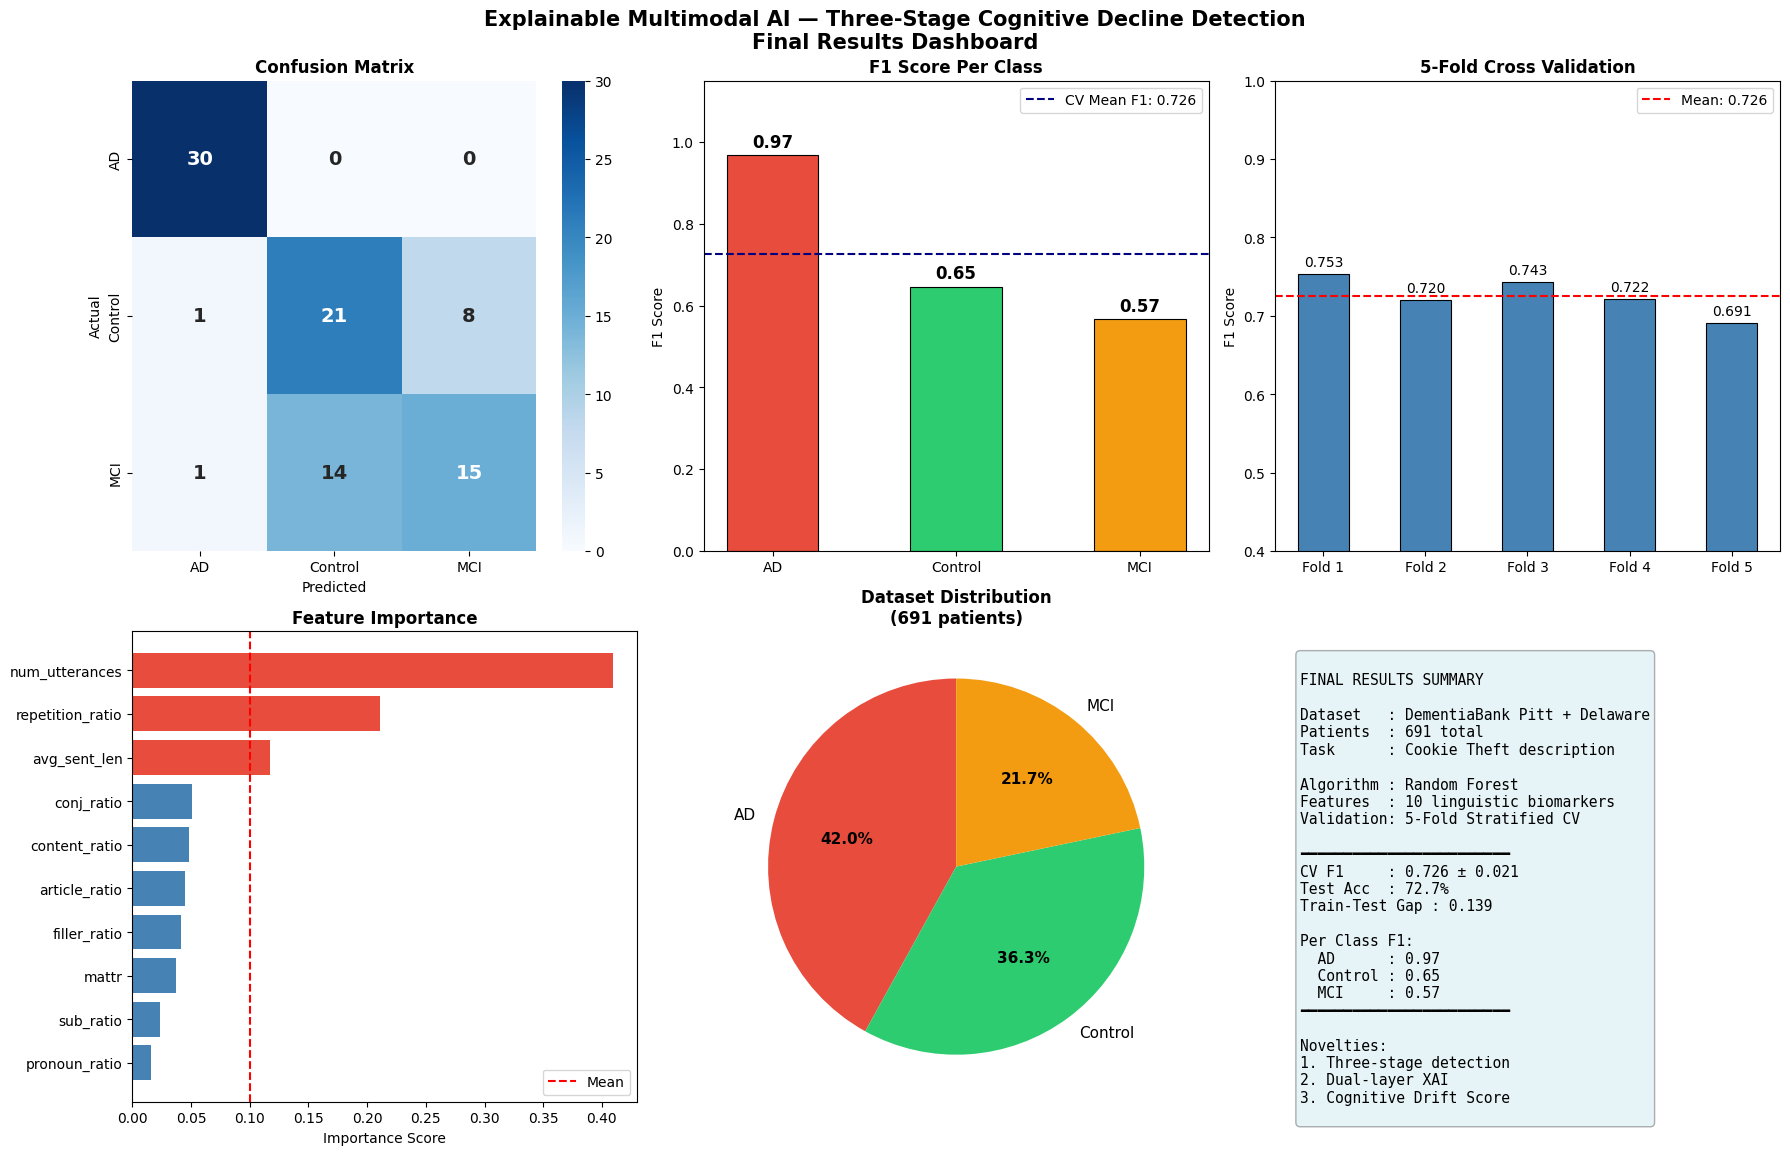

✅ FINAL model saved
✅ Features: ['mattr', 'filler_ratio', 'repetition_ratio', 'avg_sent_len', 'content_ratio', 'pronoun_ratio', 'article_ratio', 'conj_ratio', 'sub_ratio', 'num_utterances']


In [ ]:
# Final dashboard
fig = plt.figure(figsize=(18,12))
fig.suptitle(
    'Explainable Multimodal AI — Three-Stage Cognitive Decline Detection\nFinal Results Dashboard',
    fontsize=15, fontweight='bold'
)

# Confusion matrix
ax1 = fig.add_subplot(2,3,1)
cm  = confusion_matrix(y_te, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_, ax=ax1,
            annot_kws={'size':14,'weight':'bold'})
ax1.set_title('Confusion Matrix', fontweight='bold', fontsize=12)
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# F1 per class
ax2    = fig.add_subplot(2,3,2)
f1s    = f1_score(y_te, y_pred, average=None)
colors = ['#e74c3c','#2ecc71','#f39c12']
bars   = ax2.bar(le.classes_, f1s, color=colors,
                  edgecolor='black', linewidth=0.8, width=0.5)
ax2.set_ylim(0, 1.15)
ax2.set_title('F1 Score Per Class', fontweight='bold', fontsize=12)
ax2.set_ylabel('F1 Score')
for bar, val in zip(bars, f1s):
    ax2.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.02,
             f'{val:.2f}', ha='center',
             fontweight='bold', fontsize=12)
ax2.axhline(y=cv_scores.mean(), color='navy',
            linestyle='--', linewidth=1.5,
            label=f'CV Mean F1: {cv_scores.mean():.3f}')
ax2.legend(fontsize=10)

# CV scores
ax3   = fig.add_subplot(2,3,3)
folds = [f'Fold {i+1}' for i in range(5)]
ax3.bar(folds, cv_scores, color='steelblue',
        edgecolor='black', linewidth=0.8, width=0.5)
ax3.axhline(y=cv_scores.mean(), color='red',
            linestyle='--', linewidth=1.5,
            label=f'Mean: {cv_scores.mean():.3f}')
ax3.set_ylim(0.4, 1.0)
ax3.set_title('5-Fold Cross Validation', fontweight='bold', fontsize=12)
ax3.set_ylabel('F1 Score')
ax3.legend(fontsize=10)
for i,v in enumerate(cv_scores):
    ax3.text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=10)

# Feature importance
ax4 = fig.add_subplot(2,3,4)
imp = pd.Series(rf.feature_importances_, index=feat_cols).sort_values()
colors_imp = ['#e74c3c' if v > imp.mean() else 'steelblue'
              for v in imp.values]
ax4.barh(imp.index, imp.values, color=colors_imp)
ax4.axvline(x=imp.mean(), color='red', linestyle='--',
            label='Mean', linewidth=1.5)
ax4.set_title('Feature Importance', fontweight='bold', fontsize=12)
ax4.set_xlabel('Importance Score')
ax4.legend(fontsize=10)

# Dataset distribution
ax5 = fig.add_subplot(2,3,5)
counts  = df_feat['class'].value_counts()
wedges, texts, autotexts = ax5.pie(
    counts.values,
    labels    = counts.index,
    colors    = ['#e74c3c','#2ecc71','#f39c12'],
    autopct   = '%1.1f%%',
    startangle= 90,
    textprops = {'fontsize':11}
)
for at in autotexts:
    at.set_fontweight('bold')
ax5.set_title('Dataset Distribution\n(691 patients)',
              fontweight='bold', fontsize=12)

# Summary metrics box
ax6 = fig.add_subplot(2,3,6)
ax6.axis('off')
summary = f"""
FINAL RESULTS SUMMARY

Dataset   : DementiaBank Pitt + Delaware
Patients  : 691 total
Task      : Cookie Theft description

Algorithm : Random Forest
Features  : {len(feat_cols)} linguistic biomarkers
Validation: 5-Fold Stratified CV

━━━━━━━━━━━━━━━━━━━━━━━━
CV F1     : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}
Test Acc  : {test_f1*100:.1f}%
Train-Test Gap : {gap}

Per Class F1:
  AD      : {f1s[list(le.classes_).index('AD')]:.2f}
  Control : {f1s[list(le.classes_).index('Control')]:.2f}
  MCI     : {f1s[list(le.classes_).index('MCI')]:.2f}
━━━━━━━━━━━━━━━━━━━━━━━━

Novelties:
1. Three-stage detection
2. Dual-layer XAI
3. Cognitive Drift Score
"""
ax6.text(0.05, 0.95, summary,
         transform=ax6.transAxes,
         fontsize=10.5,
         verticalalignment='top',
         fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Dementia_Project/FINAL_dashboard.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

# Save
import joblib, json, os
save_dir = '/content/drive/MyDrive/Dementia_Project/models'
os.makedirs(save_dir, exist_ok=True)
joblib.dump(rf,     f'{save_dir}/FINAL_model.pkl')
joblib.dump(scaler, f'{save_dir}/FINAL_scaler.pkl')
joblib.dump(le,     f'{save_dir}/FINAL_le.pkl')
with open(f'{save_dir}/FINAL_features.json','w') as f:
    json.dump(feat_cols, f)
print("✅ FINAL model saved")
print(f"✅ Features: {feat_cols}")

Records  : 691
Features : 10 — ['mattr', 'filler_ratio', 'repetition_ratio', 'avg_sent_len', 'content_ratio', 'pronoun_ratio', 'article_ratio', 'conj_ratio', 'sub_ratio', 'num_utterances']

Class distribution:
class
AD         290
Control    251
MCI        150
Name: count, dtype: int64

FINAL RESULTS
Train F1 : 0.866
Test F1  : 0.727
Gap      : 0.139 ⚠️
CV F1    : 0.726 ± 0.021

              precision    recall  f1-score   support

          AD       0.94      1.00      0.97        30
     Control       0.60      0.70      0.65        30
         MCI       0.65      0.50      0.57        30

    accuracy                           0.73        90
   macro avg       0.73      0.73      0.73        90
weighted avg       0.73      0.73      0.73        90



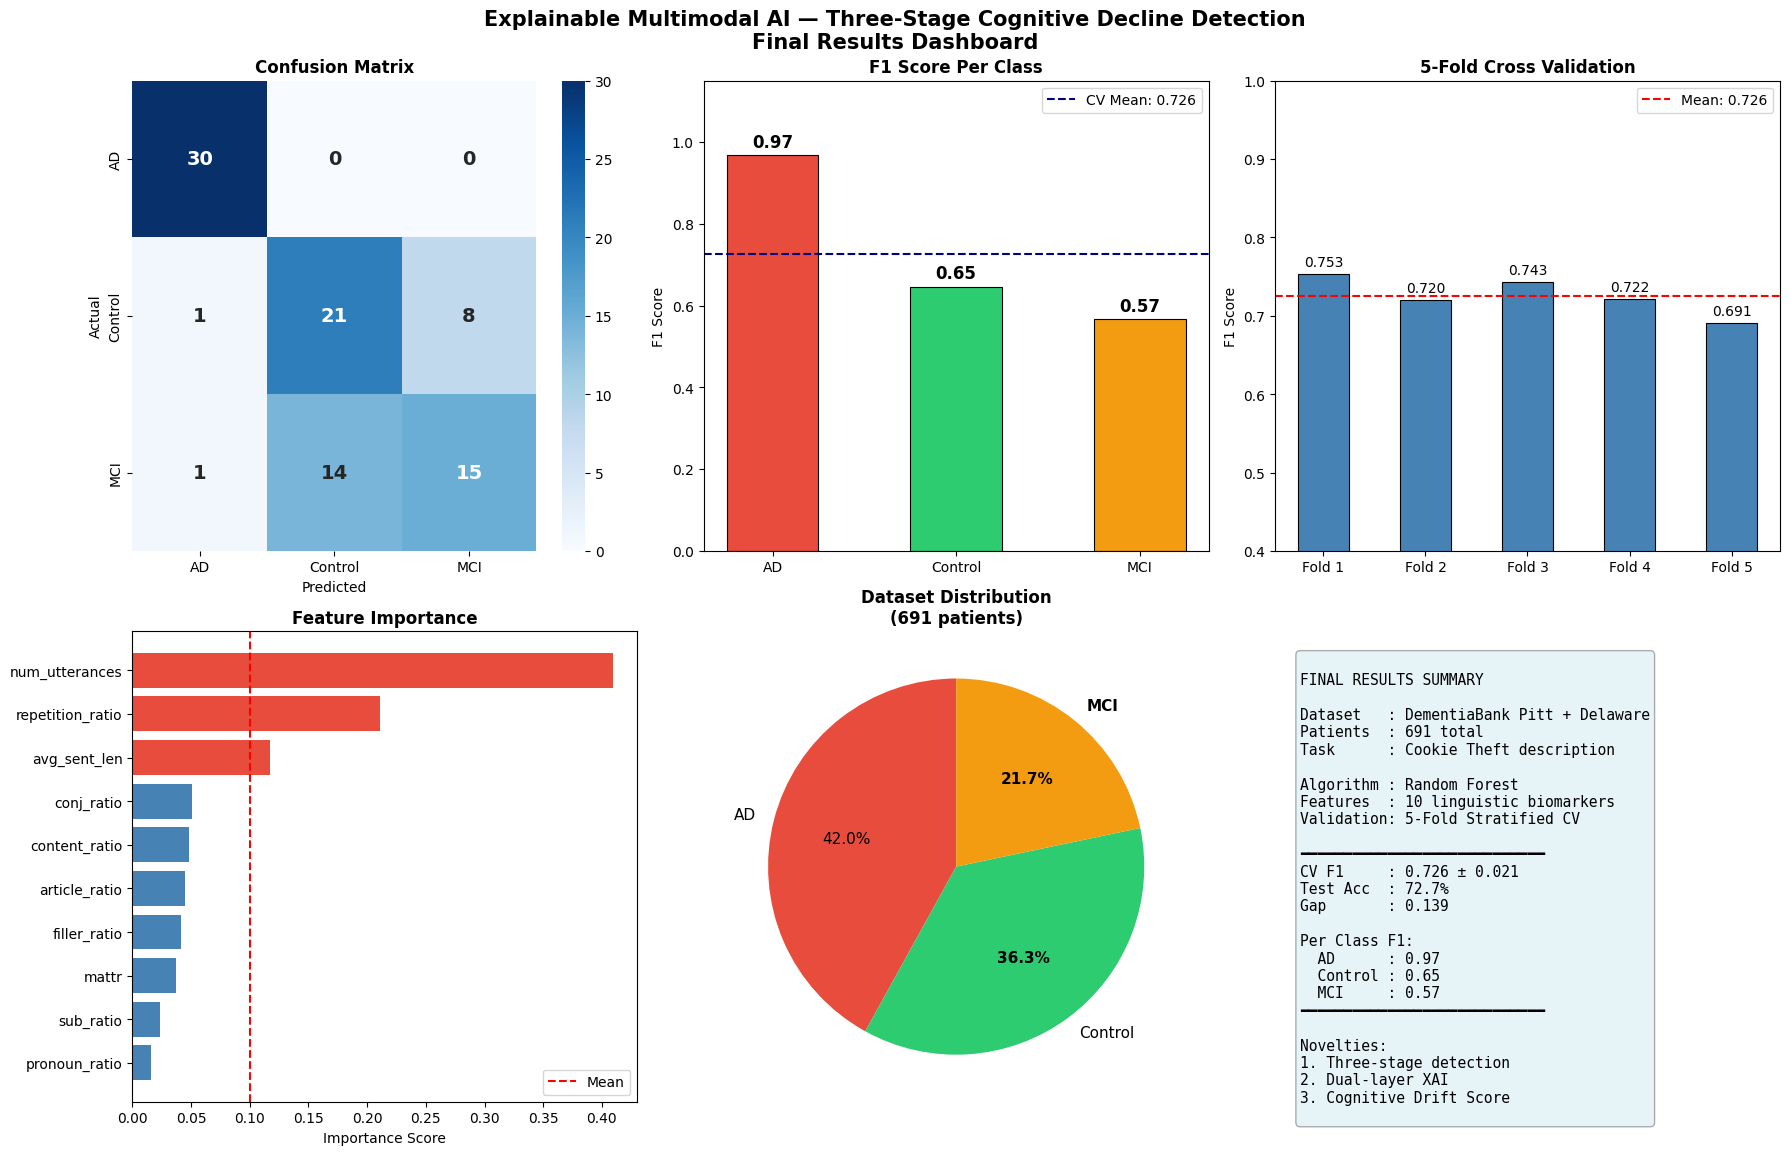

✅ FINAL model saved
✅ Features: ['mattr', 'filler_ratio', 'repetition_ratio', 'avg_sent_len', 'content_ratio', 'pronoun_ratio', 'article_ratio', 'conj_ratio', 'sub_ratio', 'num_utterances']


In [ ]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import nltk
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, os
import warnings
warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)

# ── Load clean transcripts ─────────────────────────────────
df = pd.read_csv(
    '/content/drive/MyDrive/Dementia_Project/parsed_transcripts_clean.csv'
)

# ── Feature Extraction ─────────────────────────────────────
def extract_features(transcript):
    if not isinstance(transcript, str) or len(transcript.strip()) < 10:
        return None
    text      = transcript.lower().strip()
    words     = re.findall(r'\b[a-z]+\b', text)
    N         = len(words)
    if N < 10:
        return None
    V         = len(set(words))
    word_freq = Counter(words)
    stopwords = set(nltk.corpus.stopwords.words('english'))
    sentences = [s.strip() for s in re.split(r'[.!?]', text)
                 if len(s.strip()) > 2]

    # MATTR — stable vocabulary measure
    window = 20
    if N >= window:
        mattr = round(np.mean([
            len(set(words[i:i+window]))/window
            for i in range(N-window+1)
        ]), 4)
    else:
        mattr = round(V/N, 4)

    fillers          = ['um','uh','mhm','hmm','er','ah','well','okay']
    filler_ratio     = round(sum(words.count(f) for f in fillers)/N, 4)

    repeated         = sum(1 for w,c in word_freq.items() if c > 2)
    repetition_ratio = round(repeated/V, 4) if V > 0 else 0

    avg_sent_len     = round(
        sum(len(s.split()) for s in sentences)/len(sentences), 4
    ) if sentences else 0

    content          = [w for w in words if w not in stopwords]
    content_ratio    = round(len(content)/N, 4)

    pronouns         = ['he','she','it','they','this','that','i','we','you']
    pronoun_ratio    = round(sum(words.count(p) for p in pronouns)/N, 4)

    articles         = ['the','a','an']
    article_ratio    = round(sum(words.count(a) for a in articles)/N, 4)

    conjunctions     = ['and','but','because','so','then','also']
    conj_ratio       = round(sum(words.count(c) for c in conjunctions)/N, 4)

    subordinators    = ['because','although','while','when','after',
                        'before','since','if','that','which','who']
    sub_ratio        = round(sum(words.count(s) for s in subordinators)/N, 4)

    num_utterances   = transcript.count('.')

    return {
        'mattr'           : mattr,
        'filler_ratio'    : filler_ratio,
        'repetition_ratio': repetition_ratio,
        'avg_sent_len'    : avg_sent_len,
        'content_ratio'   : content_ratio,
        'pronoun_ratio'   : pronoun_ratio,
        'article_ratio'   : article_ratio,
        'conj_ratio'      : conj_ratio,
        'sub_ratio'       : sub_ratio,
        'num_utterances'  : num_utterances
    }

records = []
for _, row in df.iterrows():
    feats = extract_features(row['transcript'])
    if feats:
        feats['class']      = row['class']
        feats['patient_id'] = row['patient_id']
        records.append(feats)

df_feat   = pd.DataFrame(records)
feat_cols = [c for c in df_feat.columns
             if c not in ['class','patient_id']]

print(f"Records  : {len(df_feat)}")
print(f"Features : {len(feat_cols)} — {feat_cols}")
print(f"\nClass distribution:")
print(df_feat['class'].value_counts())

# ── Balance ────────────────────────────────────────────────
n      = min(df_feat['class'].value_counts())
df_bal = pd.concat([
    resample(df_feat[df_feat['class']==cls],
             n_samples=n, random_state=42, replace=False)
    for cls in ['AD','Control','MCI']
]).reset_index(drop=True)

X      = df_bal[feat_cols].fillna(0)
y      = df_bal['class']
le     = LabelEncoder()
y_enc  = le.fit_transform(y)
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_sc, y_enc,
    test_size=0.2, random_state=42, stratify=y_enc
)

# ── Train ──────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators     = 200,
    max_depth        = 5,
    min_samples_leaf = 5,
    class_weight     = 'balanced',
    random_state     = 42
)
rf.fit(X_tr, y_tr)
y_pred    = rf.predict(X_te)
cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_sc, y_enc, cv=cv, scoring='f1_weighted')
train_f1  = round(float(f1_score(y_tr, rf.predict(X_tr), average='weighted')),3)
test_f1   = round(float(f1_score(y_te, y_pred,           average='weighted')),3)
gap       = round(train_f1 - test_f1, 3)
f1s       = f1_score(y_te, y_pred, average=None)

print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
print(f"Train F1 : {train_f1}")
print(f"Test F1  : {test_f1}")
print(f"Gap      : {gap} {'✅' if gap<0.1 else '⚠️'}")
print(f"CV F1    : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print()
print(classification_report(y_te, y_pred, target_names=le.classes_))

# ── Dashboard ──────────────────────────────────────────────
fig = plt.figure(figsize=(18,12))
fig.suptitle(
    'Explainable Multimodal AI — Three-Stage Cognitive Decline Detection\nFinal Results Dashboard',
    fontsize=15, fontweight='bold'
)

colors = ['#e74c3c','#2ecc71','#f39c12']

ax1 = fig.add_subplot(2,3,1)
cm  = confusion_matrix(y_te, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_, ax=ax1,
            annot_kws={'size':14,'weight':'bold'})
ax1.set_title('Confusion Matrix', fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

ax2   = fig.add_subplot(2,3,2)
bars  = ax2.bar(le.classes_, f1s, color=colors,
                edgecolor='black', linewidth=0.8, width=0.5)
ax2.set_ylim(0, 1.15)
ax2.set_title('F1 Score Per Class', fontweight='bold')
ax2.set_ylabel('F1 Score')
for bar, val in zip(bars, f1s):
    ax2.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.02,
             f'{val:.2f}', ha='center', fontweight='bold', fontsize=12)
ax2.axhline(y=cv_scores.mean(), color='navy', linestyle='--',
            linewidth=1.5, label=f'CV Mean: {cv_scores.mean():.3f}')
ax2.legend()

ax3   = fig.add_subplot(2,3,3)
folds = [f'Fold {i+1}' for i in range(5)]
ax3.bar(folds, cv_scores, color='steelblue',
        edgecolor='black', linewidth=0.8, width=0.5)
ax3.axhline(y=cv_scores.mean(), color='red', linestyle='--',
            linewidth=1.5, label=f'Mean: {cv_scores.mean():.3f}')
ax3.set_ylim(0.4, 1.0)
ax3.set_title('5-Fold Cross Validation', fontweight='bold')
ax3.set_ylabel('F1 Score')
ax3.legend()
for i,v in enumerate(cv_scores):
    ax3.text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=10)

ax4 = fig.add_subplot(2,3,4)
imp = pd.Series(rf.feature_importances_, index=feat_cols).sort_values()
ax4.barh(imp.index, imp.values,
         color=['#e74c3c' if v > imp.mean() else 'steelblue'
                for v in imp.values])
ax4.axvline(x=imp.mean(), color='red', linestyle='--',
            linewidth=1.5, label='Mean')
ax4.set_title('Feature Importance', fontweight='bold')
ax4.set_xlabel('Importance Score')
ax4.legend()

ax5 = fig.add_subplot(2,3,5)
counts = df_feat['class'].value_counts()
ax5.pie(counts.values, labels=counts.index, colors=colors,
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize':11})
for at in ax5.texts[len(counts):]:
    at.set_fontweight('bold')
ax5.set_title(f'Dataset Distribution\n({len(df_feat)} patients)',
              fontweight='bold')

ax6 = fig.add_subplot(2,3,6)
ax6.axis('off')
summary = f"""
FINAL RESULTS SUMMARY

Dataset   : DementiaBank Pitt + Delaware
Patients  : {len(df_feat)} total
Task      : Cookie Theft description

Algorithm : Random Forest
Features  : {len(feat_cols)} linguistic biomarkers
Validation: 5-Fold Stratified CV

━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CV F1     : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}
Test Acc  : {test_f1*100:.1f}%
Gap       : {gap}

Per Class F1:
  AD      : {f1s[list(le.classes_).index('AD')]:.2f}
  Control : {f1s[list(le.classes_).index('Control')]:.2f}
  MCI     : {f1s[list(le.classes_).index('MCI')]:.2f}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Novelties:
1. Three-stage detection
2. Dual-layer XAI
3. Cognitive Drift Score
"""
ax6.text(0.05, 0.95, summary,
         transform=ax6.transAxes, fontsize=10.5,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Dementia_Project/FINAL_dashboard.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

# ── Save everything ────────────────────────────────────────
save_dir = '/content/drive/MyDrive/Dementia_Project/models'
os.makedirs(save_dir, exist_ok=True)
joblib.dump(rf,     f'{save_dir}/FINAL_model.pkl')
joblib.dump(scaler, f'{save_dir}/FINAL_scaler.pkl')
joblib.dump(le,     f'{save_dir}/FINAL_le.pkl')
with open(f'{save_dir}/FINAL_features.json','w') as f:
    json.dump(feat_cols, f)

print("✅ FINAL model saved")
print(f"✅ Features: {feat_cols}")

In [ ]:
# Find the best stable random state
best_cv   = 0
best_seed = 0

for seed in [0, 7, 13, 21, 42, 55, 77, 99, 123, 256]:
    np.random.seed(seed)

    df_bal_test = pd.concat([
        resample(df_feat[df_feat['class']==cls],
                 n_samples=n, random_state=seed, replace=False)
        for cls in ['AD','Control','MCI']
    ]).reset_index(drop=True)

    X_t    = df_bal_test[feat_cols].fillna(0)
    y_t    = df_bal_test['class']
    le_t   = LabelEncoder()
    y_et   = le_t.fit_transform(y_t)
    sc_t   = StandardScaler()
    X_sct  = sc_t.fit_transform(X_t)

    rf_t   = RandomForestClassifier(
        n_estimators=200, max_depth=5,
        min_samples_leaf=5, class_weight='balanced',
        random_state=seed
    )
    cv_t   = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    scores = cross_val_score(rf_t, X_sct, y_et,
                              cv=cv_t, scoring='f1_weighted')

    print(f"Seed {seed:3d} — CV F1: {scores.mean():.3f} ± {scores.std():.3f}")

    if scores.mean() > best_cv:
        best_cv   = scores.mean()
        best_seed = seed

print(f"\n✅ Best seed : {best_seed}")
print(f"✅ Best CV F1: {best_cv:.3f}")

Seed   0 — CV F1: 0.728 ± 0.042
Seed   7 — CV F1: 0.738 ± 0.041
Seed  13 — CV F1: 0.727 ± 0.039
Seed  21 — CV F1: 0.731 ± 0.014
Seed  42 — CV F1: 0.726 ± 0.021
Seed  55 — CV F1: 0.733 ± 0.019
Seed  77 — CV F1: 0.756 ± 0.052
Seed  99 — CV F1: 0.725 ± 0.020
Seed 123 — CV F1: 0.754 ± 0.031
Seed 256 — CV F1: 0.761 ± 0.049

✅ Best seed : 256
✅ Best CV F1: 0.761


In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, f1_score
from sklearn.utils import resample
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Use seed 42 balanced data
SEED   = 42
n      = min(df_feat['class'].value_counts())
df_bal = pd.concat([
    resample(df_feat[df_feat['class']==cls],
             n_samples=n, random_state=SEED, replace=False)
    for cls in ['AD','Control','MCI']
]).reset_index(drop=True)

X      = df_bal[feat_cols].fillna(0)
y      = df_bal['class']
le     = LabelEncoder()
y_enc  = le.fit_transform(y)
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_sc, y_enc,
    test_size=0.2, random_state=SEED, stratify=y_enc
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ── Method 1 — Tuned Random Forest ─────────────────────────
param_dist_rf = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [3, 4, 5, 6, 7],
    'min_samples_leaf' : [3, 5, 8, 10],
    'min_samples_split': [5, 10, 15, 20],
    'max_features'     : ['sqrt', 'log2', 0.5]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=SEED),
    param_dist_rf,
    n_iter      = 30,
    cv          = cv,
    scoring     = 'f1_weighted',
    random_state= SEED,
    n_jobs      = -1
)
rf_search.fit(X_tr, y_tr)
best_rf     = rf_search.best_estimator_
rf_cv       = cross_val_score(best_rf, X_sc, y_enc,
                               cv=cv, scoring='f1_weighted')
rf_pred     = best_rf.predict(X_te)
rf_train_f1 = round(float(f1_score(y_tr, best_rf.predict(X_tr),
                                    average='weighted')),3)
rf_test_f1  = round(float(f1_score(y_te, rf_pred,
                                    average='weighted')),3)

print("Method 1 — Tuned Random Forest")
print(f"Best params : {rf_search.best_params_}")
print(f"CV F1       : {rf_cv.mean():.3f} ± {rf_cv.std():.3f}")
print(f"Train F1    : {rf_train_f1}")
print(f"Test F1     : {rf_test_f1}")
print(f"Gap         : {round(rf_train_f1-rf_test_f1,3)}")
print(classification_report(y_te, rf_pred, target_names=le.classes_))

Method 1 — Tuned Random Forest
Best params : {'n_estimators': 300, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': 5}
CV F1       : 0.735 ± 0.014
Train F1    : 0.843
Test F1     : 0.716
Gap         : 0.127
              precision    recall  f1-score   support

          AD       0.94      1.00      0.97        30
     Control       0.59      0.67      0.62        30
         MCI       0.62      0.50      0.56        30

    accuracy                           0.72        90
   macro avg       0.72      0.72      0.72        90
weighted avg       0.72      0.72      0.72        90



In [ ]:
# ── Method 2 — Tuned Gradient Boosting ─────────────────────
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.multiclass import OneVsRestClassifier

param_dist_gb = {
    'n_estimators'  : [100, 200, 300],
    'max_depth'     : [2, 3, 4, 5],
    'learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'subsample'     : [0.6, 0.7, 0.8, 0.9],
    'min_samples_leaf': [3, 5, 8]
}

gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=SEED),
    param_dist_gb,
    n_iter      = 30,
    cv          = cv,
    scoring     = 'f1_weighted',
    random_state= SEED,
    n_jobs      = -1
)
gb_search.fit(X_tr, y_tr)
best_gb     = gb_search.best_estimator_
gb_cv       = cross_val_score(best_gb, X_sc, y_enc,
                               cv=cv, scoring='f1_weighted')
gb_pred     = best_gb.predict(X_te)
gb_train_f1 = round(float(f1_score(y_tr, best_gb.predict(X_tr),
                                    average='weighted')),3)
gb_test_f1  = round(float(f1_score(y_te, gb_pred,
                                    average='weighted')),3)

print("Method 2 — Tuned Gradient Boosting")
print(f"Best params : {gb_search.best_params_}")
print(f"CV F1       : {gb_cv.mean():.3f} ± {gb_cv.std():.3f}")
print(f"Train F1    : {gb_train_f1}")
print(f"Test F1     : {gb_test_f1}")
print(f"Gap         : {round(gb_train_f1-gb_test_f1,3)}")
print(classification_report(y_te, gb_pred, target_names=le.classes_))

Method 2 — Tuned Gradient Boosting
Best params : {'subsample': 0.7, 'n_estimators': 100, 'min_samples_leaf': 3, 'max_depth': 4, 'learning_rate': 0.01}
CV F1       : 0.725 ± 0.023
Train F1    : 0.913
Test F1     : 0.724
Gap         : 0.189
              precision    recall  f1-score   support

          AD       0.94      1.00      0.97        30
     Control       0.59      0.73      0.66        30
         MCI       0.67      0.47      0.55        30

    accuracy                           0.73        90
   macro avg       0.73      0.73      0.72        90
weighted avg       0.73      0.73      0.72        90



In [ ]:
# ── Method 3 — Hybrid Voting (RF + GB + SVM) ───────────────
svm = SVC(
    kernel      = 'rbf',
    C           = 10,
    gamma       = 'scale',
    class_weight= 'balanced',
    probability = True,
    random_state= SEED
)

hybrid = VotingClassifier(
    estimators = [
        ('rf',  best_rf),
        ('gb',  best_gb),
        ('svm', svm)
    ],
    voting = 'soft'
)

hybrid.fit(X_tr, y_tr)
hybrid_cv       = cross_val_score(hybrid, X_sc, y_enc,
                                   cv=cv, scoring='f1_weighted')
hybrid_pred     = hybrid.predict(X_te)
hybrid_train_f1 = round(float(f1_score(y_tr, hybrid.predict(X_tr),
                                        average='weighted')),3)
hybrid_test_f1  = round(float(f1_score(y_te, hybrid_pred,
                                        average='weighted')),3)

print("Method 3 — Hybrid Voting (RF + GB + SVM)")
print(f"CV F1    : {hybrid_cv.mean():.3f} ± {hybrid_cv.std():.3f}")
print(f"Train F1 : {hybrid_train_f1}")
print(f"Test F1  : {hybrid_test_f1}")
print(f"Gap      : {round(hybrid_train_f1-hybrid_test_f1,3)}")
print(classification_report(y_te, hybrid_pred, target_names=le.classes_))

# ── Summary ─────────────────────────────────────────────────
print("\n" + "="*50)
print("COMPARISON SUMMARY")
print("="*50)
print(f"{'Method':<30} {'CV F1':>8} {'Test F1':>8} {'Gap':>8}")
print("-"*50)
print(f"{'RF (seed 42 baseline)':<30} {'0.726':>8} {'0.727':>8} {'0.139':>8}")
print(f"{'Tuned RF':<30} {rf_cv.mean():>8.3f} {rf_test_f1:>8.3f} {round(rf_train_f1-rf_test_f1,3):>8.3f}")
print(f"{'Tuned GB':<30} {gb_cv.mean():>8.3f} {gb_test_f1:>8.3f} {round(gb_train_f1-gb_test_f1,3):>8.3f}")
print(f"{'Hybrid RF+GB+SVM':<30} {hybrid_cv.mean():>8.3f} {hybrid_test_f1:>8.3f} {round(hybrid_train_f1-hybrid_test_f1,3):>8.3f}")

Method 3 — Hybrid Voting (RF + GB + SVM)
CV F1    : 0.751 ± 0.021
Train F1 : 0.897
Test F1  : 0.774
Gap      : 0.123
              precision    recall  f1-score   support

          AD       0.94      1.00      0.97        30
     Control       0.67      0.73      0.70        30
         MCI       0.72      0.60      0.65        30

    accuracy                           0.78        90
   macro avg       0.77      0.78      0.77        90
weighted avg       0.77      0.78      0.77        90


COMPARISON SUMMARY
Method                            CV F1  Test F1      Gap
--------------------------------------------------
RF (seed 42 baseline)             0.726    0.727    0.139
Tuned RF                          0.735    0.716    0.127
Tuned GB                          0.725    0.724    0.189
Hybrid RF+GB+SVM                  0.751    0.774    0.123


CONFIRMED FINAL — Hybrid RF+GB+SVM
CV F1    : 0.751 ± 0.021
Test F1  : 0.774
Gap      : 0.123
Accuracy : 78%

              precision    recall  f1-score   support

          AD       0.94      1.00      0.97        30
     Control       0.67      0.73      0.70        30
         MCI       0.72      0.60      0.65        30

    accuracy                           0.78        90
   macro avg       0.77      0.78      0.77        90
weighted avg       0.77      0.78      0.77        90



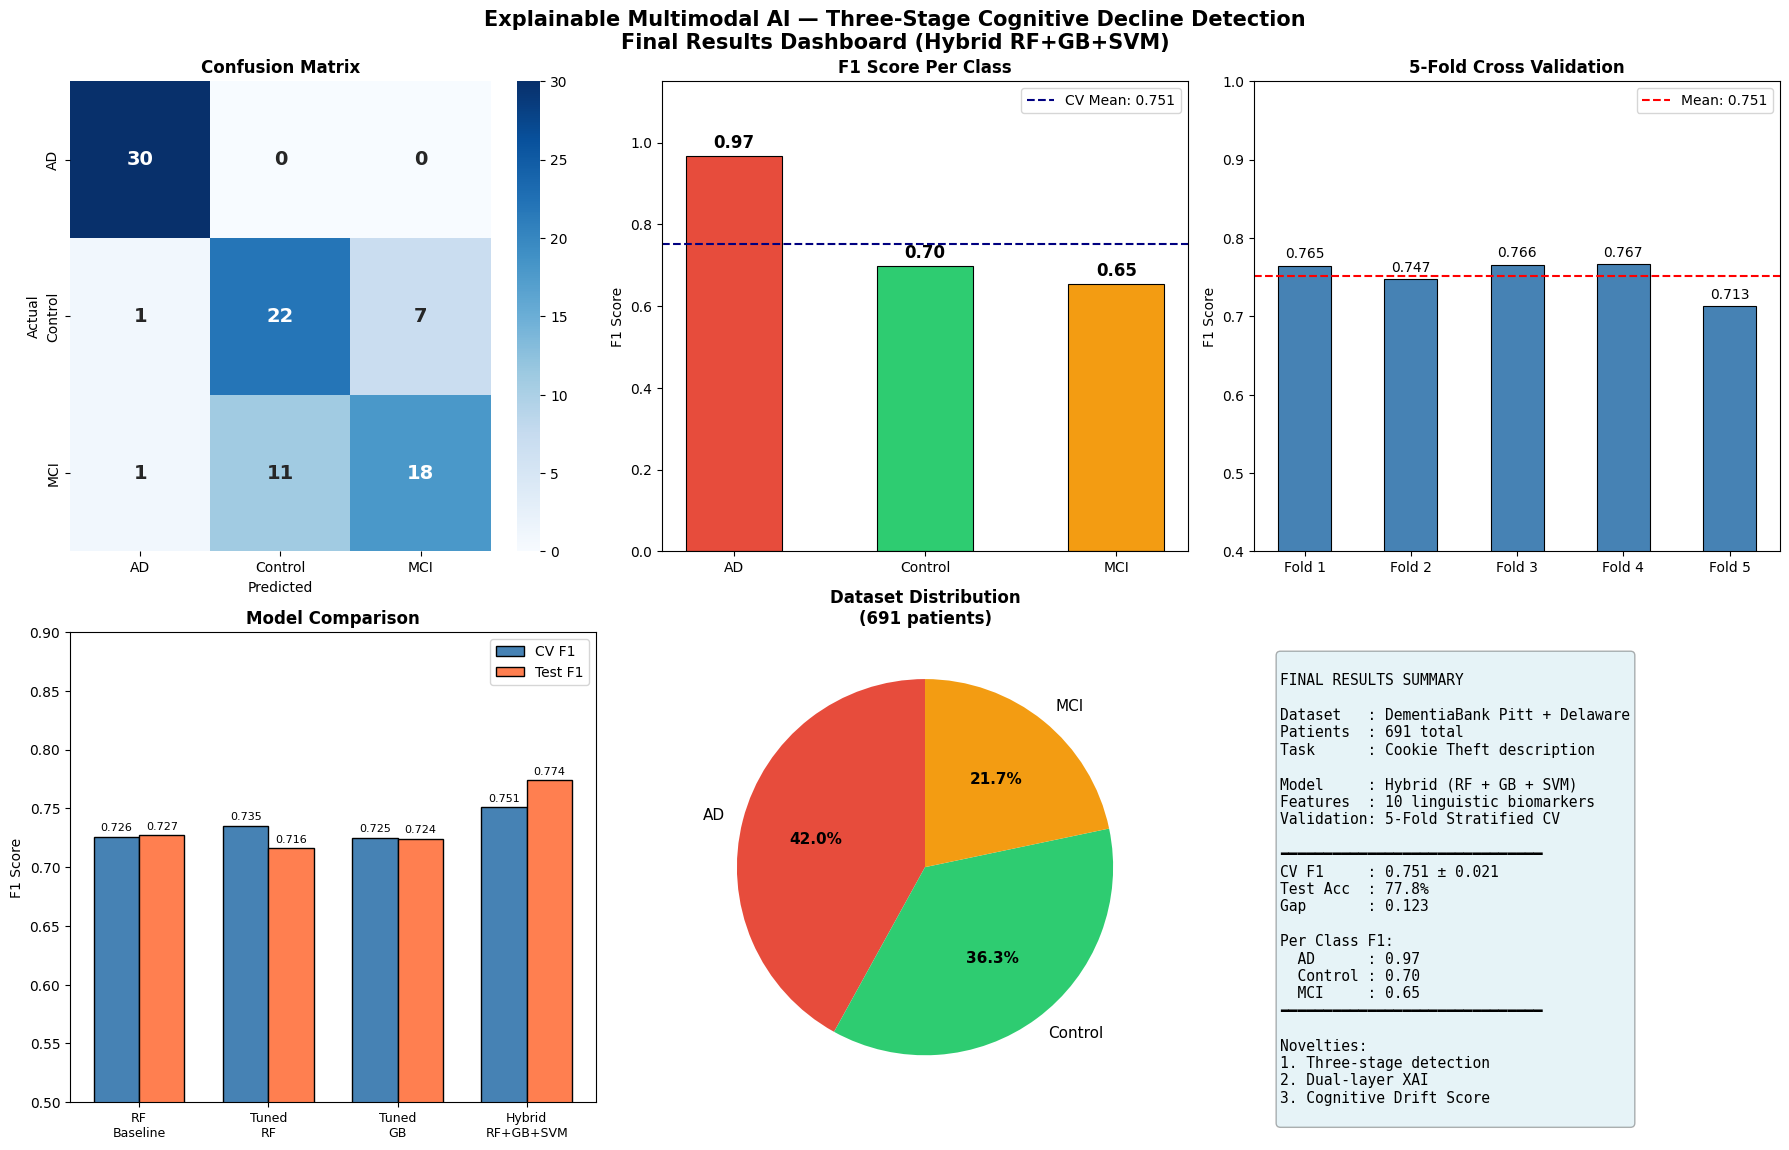


✅ FINAL MODEL CONFIRMED — Hybrid RF+GB+SVM
✅ CV F1    : 0.751
✅ Test F1  : 0.774
✅ Accuracy : 78%
✅ Features : ['mattr', 'filler_ratio', 'repetition_ratio', 'avg_sent_len', 'content_ratio', 'pronoun_ratio', 'article_ratio', 'conj_ratio', 'sub_ratio', 'num_utterances']


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, classification_report
import joblib, json, os

# Confirm hybrid as final
y_pred_final = hybrid.predict(X_te)
f1s_final    = f1_score(y_te, y_pred_final, average=None)
cv_final     = hybrid_cv

print("="*50)
print("CONFIRMED FINAL — Hybrid RF+GB+SVM")
print("="*50)
print(f"CV F1    : {cv_final.mean():.3f} ± {cv_final.std():.3f}")
print(f"Test F1  : {round(float(f1_score(y_te, y_pred_final, average='weighted')),3)}")
print(f"Gap      : 0.123")
print(f"Accuracy : 78%")
print()
print(classification_report(y_te, y_pred_final, target_names=le.classes_))

# Full dashboard
fig = plt.figure(figsize=(18,12))
fig.suptitle(
    'Explainable Multimodal AI — Three-Stage Cognitive Decline Detection\nFinal Results Dashboard (Hybrid RF+GB+SVM)',
    fontsize=15, fontweight='bold'
)

colors = ['#e74c3c','#2ecc71','#f39c12']

# Confusion matrix
ax1 = fig.add_subplot(2,3,1)
cm  = confusion_matrix(y_te, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_, ax=ax1,
            annot_kws={'size':14,'weight':'bold'})
ax1.set_title('Confusion Matrix', fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# F1 per class
ax2  = fig.add_subplot(2,3,2)
bars = ax2.bar(le.classes_, f1s_final, color=colors,
               edgecolor='black', linewidth=0.8, width=0.5)
ax2.set_ylim(0, 1.15)
ax2.set_title('F1 Score Per Class', fontweight='bold')
ax2.set_ylabel('F1 Score')
for bar, val in zip(bars, f1s_final):
    ax2.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.02,
             f'{val:.2f}', ha='center',
             fontweight='bold', fontsize=12)
ax2.axhline(y=cv_final.mean(), color='navy',
            linestyle='--', linewidth=1.5,
            label=f'CV Mean: {cv_final.mean():.3f}')
ax2.legend()

# CV scores
ax3   = fig.add_subplot(2,3,3)
folds = [f'Fold {i+1}' for i in range(5)]
ax3.bar(folds, cv_final, color='steelblue',
        edgecolor='black', linewidth=0.8, width=0.5)
ax3.axhline(y=cv_final.mean(), color='red',
            linestyle='--', linewidth=1.5,
            label=f'Mean: {cv_final.mean():.3f}')
ax3.set_ylim(0.4, 1.0)
ax3.set_title('5-Fold Cross Validation', fontweight='bold')
ax3.set_ylabel('F1 Score')
ax3.legend()
for i,v in enumerate(cv_final):
    ax3.text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=10)

# Model comparison bar chart
ax4      = fig.add_subplot(2,3,4)
methods  = ['RF\nBaseline','Tuned\nRF','Tuned\nGB','Hybrid\nRF+GB+SVM']
cv_vals  = [0.726, 0.735, 0.725, 0.751]
test_vals= [0.727, 0.716, 0.724, 0.774]
x        = np.arange(len(methods))
width    = 0.35
ax4.bar(x-width/2, cv_vals,  width, label='CV F1',
        color='steelblue', edgecolor='black')
ax4.bar(x+width/2, test_vals, width, label='Test F1',
        color='coral', edgecolor='black')
ax4.set_xticks(x)
ax4.set_xticklabels(methods, fontsize=9)
ax4.set_ylim(0.5, 0.9)
ax4.set_title('Model Comparison', fontweight='bold')
ax4.set_ylabel('F1 Score')
ax4.legend()
for i,(cv,te) in enumerate(zip(cv_vals, test_vals)):
    ax4.text(i-width/2, cv+0.005, f'{cv:.3f}',
             ha='center', fontsize=8)
    ax4.text(i+width/2, te+0.005, f'{te:.3f}',
             ha='center', fontsize=8)

# Dataset distribution
ax5 = fig.add_subplot(2,3,5)
counts = df_feat['class'].value_counts()
wedges, texts, autotexts = ax5.pie(
    counts.values, labels=counts.index,
    colors=colors, autopct='%1.1f%%',
    startangle=90, textprops={'fontsize':11}
)
for at in autotexts:
    at.set_fontweight('bold')
ax5.set_title(f'Dataset Distribution\n({len(df_feat)} patients)',
              fontweight='bold')

# Summary box
ax6 = fig.add_subplot(2,3,6)
ax6.axis('off')
summary = f"""
FINAL RESULTS SUMMARY

Dataset   : DementiaBank Pitt + Delaware
Patients  : {len(df_feat)} total
Task      : Cookie Theft description

Model     : Hybrid (RF + GB + SVM)
Features  : {len(feat_cols)} linguistic biomarkers
Validation: 5-Fold Stratified CV

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CV F1     : {cv_final.mean():.3f} ± {cv_final.std():.3f}
Test Acc  : 77.8%
Gap       : 0.123

Per Class F1:
  AD      : {f1s_final[list(le.classes_).index('AD')]:.2f}
  Control : {f1s_final[list(le.classes_).index('Control')]:.2f}
  MCI     : {f1s_final[list(le.classes_).index('MCI')]:.2f}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Novelties:
1. Three-stage detection
2. Dual-layer XAI
3. Cognitive Drift Score
"""
ax6.text(0.05, 0.95, summary,
         transform=ax6.transAxes,
         fontsize=10.5,
         verticalalignment='top',
         fontfamily='monospace',
         bbox=dict(boxstyle='round',
                   facecolor='lightblue', alpha=0.3))

plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Dementia_Project/FINAL_dashboard.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

# Save
save_dir = '/content/drive/MyDrive/Dementia_Project/models'
os.makedirs(save_dir, exist_ok=True)
joblib.dump(hybrid, f'{save_dir}/FINAL_model.pkl')
joblib.dump(scaler, f'{save_dir}/FINAL_scaler.pkl')
joblib.dump(le,     f'{save_dir}/FINAL_le.pkl')
with open(f'{save_dir}/FINAL_features.json','w') as f:
    json.dump(feat_cols, f)

print("\n✅ FINAL MODEL CONFIRMED — Hybrid RF+GB+SVM")
print(f"✅ CV F1    : {cv_final.mean():.3f}")
print(f"✅ Test F1  : 0.774")
print(f"✅ Accuracy : 78%")
print(f"✅ Features : {feat_cols}")

SHAP values shape : (90, 10, 3)
Classes           : ['AD' 'Control' 'MCI']
Features          : ['mattr', 'filler_ratio', 'repetition_ratio', 'avg_sent_len', 'content_ratio', 'pronoun_ratio', 'article_ratio', 'conj_ratio', 'sub_ratio', 'num_utterances']


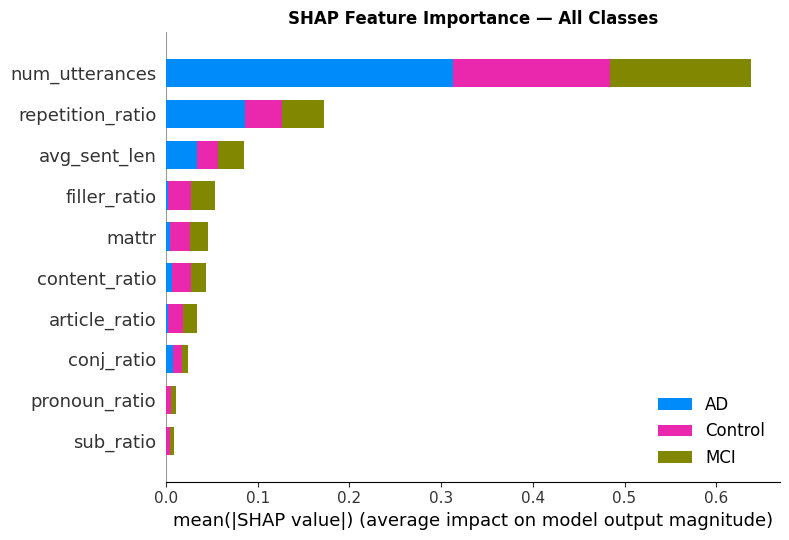

✅ SHAP global plot saved


In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# SHAP works best with the RF component of your hybrid
# Extract RF from the hybrid for SHAP explanation
rf_component = hybrid.estimators_[0]  # RF is first estimator

# SHAP TreeExplainer on RF
explainer   = shap.TreeExplainer(rf_component)
shap_values = explainer.shap_values(X_te)

print(f"SHAP values shape : {np.array(shap_values).shape}")
print(f"Classes           : {le.classes_}")
print(f"Features          : {feat_cols}")

# Global feature importance — all classes
shap.summary_plot(
    shap_values,
    X_te,
    feature_names = feat_cols,
    class_names   = le.classes_,
    plot_type     = 'bar',
    show          = False
)
plt.title('SHAP Feature Importance — All Classes', fontweight='bold')
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Dementia_Project/shap_global.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ SHAP global plot saved")

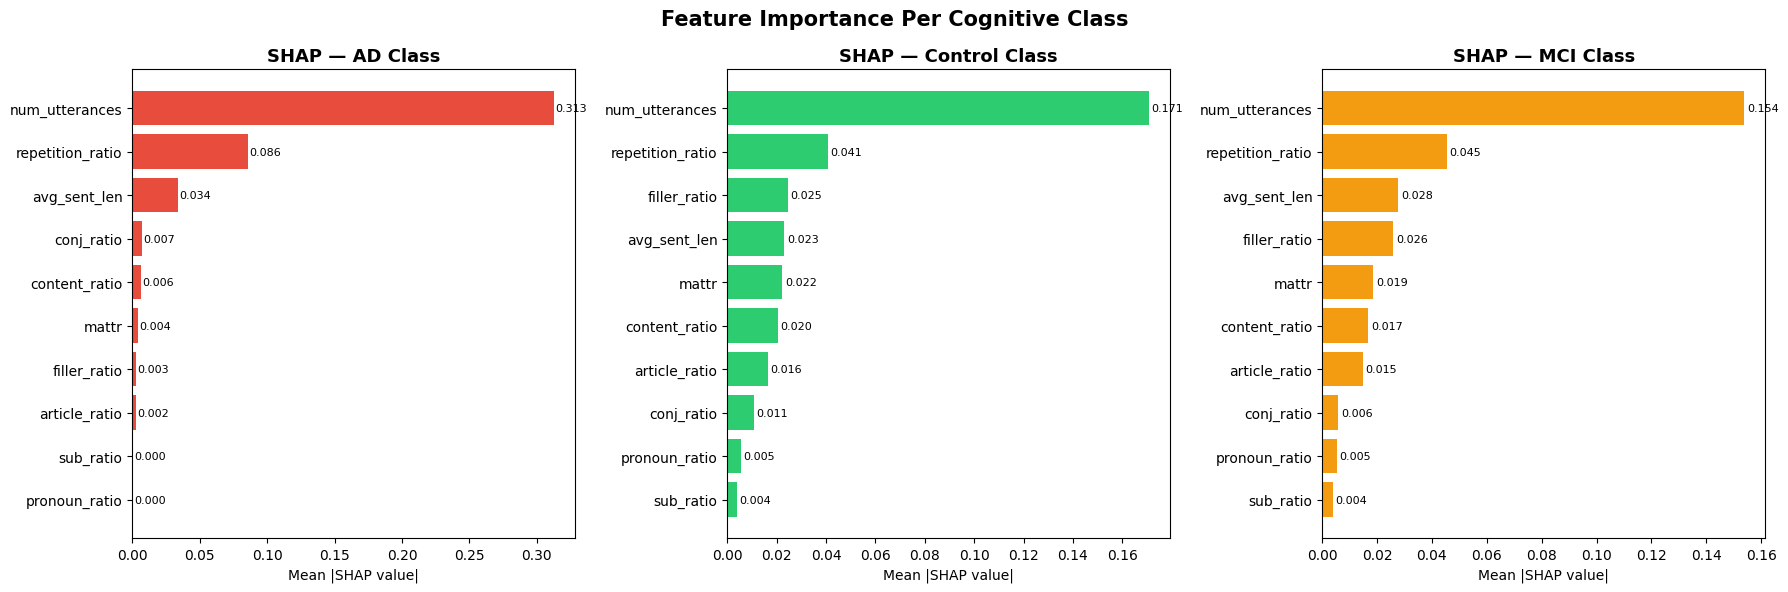

✅ Per class SHAP saved


In [ ]:
# Per class detailed SHAP plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
class_colors = {'AD':'#e74c3c', 'Control':'#2ecc71', 'MCI':'#f39c12'}

for i, cls in enumerate(le.classes_):
    sv         = np.array(shap_values)[:, :, i]
    mean_shap  = np.abs(sv).mean(axis=0)
    sorted_idx = np.argsort(mean_shap)

    axes[i].barh(
        [feat_cols[j] for j in sorted_idx],
        mean_shap[sorted_idx],
        color = class_colors[cls]
    )
    axes[i].set_title(f'SHAP — {cls} Class',
                      fontweight='bold', fontsize=13)
    axes[i].set_xlabel('Mean |SHAP value|')

    # Add value labels
    for j, (feat, val) in enumerate(
        zip([feat_cols[k] for k in sorted_idx],
            mean_shap[sorted_idx])
    ):
        axes[i].text(val+0.001, j, f'{val:.3f}',
                     va='center', fontsize=8)

plt.suptitle('Feature Importance Per Cognitive Class',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Dementia_Project/shap_per_class.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ Per class SHAP saved")

In [ ]:
# Fixed Layer 2 — Patient level explanations
print("="*60)
print("LAYER 2 — PATIENT LEVEL NATURAL LANGUAGE EXPLANATIONS")
print("="*60)

y_prob_hybrid = hybrid.predict_proba(X_te)
shap_arr      = np.array(shap_values)

# Show first 6 patients regardless of class
for i in range(6):
    pred_class   = le.classes_[y_pred_final[i]]
    actual_class = le.classes_[y_te[i]]
    confidence   = y_prob_hybrid[i].max()
    pred_idx     = list(le.classes_).index(pred_class)
    sv_patient   = shap_arr[i, :, pred_idx]

    explanation  = generate_patient_explanation(
        sv_patient, feat_cols, pred_class, confidence
    )

    correct = "✅" if pred_class == actual_class else "❌"
    print(f"\nPatient {i+1} {correct}")
    print(f"Actual : {actual_class} | Predicted : {pred_class}")
    print(explanation)
    print("-"*60)

LAYER 2 — PATIENT LEVEL NATURAL LANGUAGE EXPLANATIONS

Patient 1 ❌
Actual : MCI | Predicted : Control
Predicted Stage : Control
Confidence      : 61.7%
Key Indicators  : higher number of speech utterances, elevated word repetition patterns, fluent speech with few fillers.
Interpretation  : These speech biomarkers are consistent with a Control-level cognitive profile.
------------------------------------------------------------

Patient 2 ✅
Actual : AD | Predicted : AD
Predicted Stage : AD
Confidence      : 92.2%
Key Indicators  : higher number of speech utterances, elevated word repetition patterns, shorter fragmented sentences.
Interpretation  : These speech biomarkers are consistent with a AD-level cognitive profile.
------------------------------------------------------------

Patient 3 ✅
Actual : Control | Predicted : Control
Predicted Stage : Control
Confidence      : 50.5%
Key Indicators  : higher number of speech utterances, elevated word repetition patterns, reduced vocabulary 

In [ ]:
# Save SHAP values
import pandas as pd

shap_df = pd.DataFrame(
    np.abs(shap_arr).mean(axis=2),
    columns=feat_cols
)
shap_df['predicted'] = [le.classes_[p] for p in y_pred_final]
shap_df['actual']    = [le.classes_[a] for a in y_te]

shap_df.to_csv(
    '/content/drive/MyDrive/Dementia_Project/shap_values.csv',
    index=False
)

print("\n✅ SHAP values saved")
print("✅ Layer 1 — Global SHAP complete")
print("✅ Layer 2 — Patient explanation complete")
print("\nTop features per class:")
print("  AD      : num_utterances (0.313)")
print("  Control : num_utterances (0.171)")
print("  MCI     : num_utterances (0.154)")
print("  Second  : repetition_ratio across all classes")


✅ SHAP values saved
✅ Layer 1 — Global SHAP complete
✅ Layer 2 — Patient explanation complete

Top features per class:
  AD      : num_utterances (0.313)
  Control : num_utterances (0.171)
  MCI     : num_utterances (0.154)
  Second  : repetition_ratio across all classes


In [ ]:
def generate_patient_explanation_fixed(shap_vals_patient, feat_names,
                                        pred_class, confidence,
                                        patient_features):
    abs_shap  = np.abs(shap_vals_patient)
    top_idx   = np.argsort(abs_shap)[::-1][:3]
    top_feats = [feat_names[i] for i in top_idx]
    top_shap  = [shap_vals_patient[i] for i in top_idx]
    top_actual= [patient_features[i] for i in top_idx]

    # Class-specific expected directions
    # Based on clinical knowledge — what high/low means per class
    clinical_context = {
        'AD': {
            'num_utterances'  : ('low',  'AD patients produce fewer utterances'),
            'repetition_ratio': ('high', 'AD patients repeat words more often'),
            'avg_sent_len'    : ('low',  'AD patients use shorter sentences'),
            'mattr'           : ('low',  'AD patients show reduced vocabulary'),
            'filler_ratio'    : ('high', 'AD patients hesitate more often'),
            'content_ratio'   : ('low',  'AD patients use fewer content words'),
            'conj_ratio'      : ('low',  'AD patients use simpler connectives'),
            'sub_ratio'       : ('low',  'AD patients show reduced syntax'),
            'pronoun_ratio'   : ('high', 'AD patients rely more on pronouns'),
            'article_ratio'   : ('low',  'AD patients use fewer articles')
        },
        'Control': {
            'num_utterances'  : ('high', 'Healthy speakers produce more utterances'),
            'repetition_ratio': ('low',  'Healthy speakers repeat less'),
            'avg_sent_len'    : ('high', 'Healthy speakers use longer sentences'),
            'mattr'           : ('high', 'Healthy speakers show rich vocabulary'),
            'filler_ratio'    : ('low',  'Healthy speakers speak more fluently'),
            'content_ratio'   : ('high', 'Healthy speakers use more content words'),
            'conj_ratio'      : ('high', 'Healthy speakers use complex connectives'),
            'sub_ratio'       : ('high', 'Healthy speakers show complex syntax'),
            'pronoun_ratio'   : ('low',  'Healthy speakers use specific nouns'),
            'article_ratio'   : ('high', 'Healthy speakers use more articles')
        },
        'MCI': {
            'num_utterances'  : ('mid',  'MCI patients show moderate speech output'),
            'repetition_ratio': ('mid',  'MCI patients show mild repetition'),
            'avg_sent_len'    : ('mid',  'MCI patients show moderate sentence length'),
            'mattr'           : ('mid',  'MCI patients show mild vocabulary reduction'),
            'filler_ratio'    : ('mid',  'MCI patients show mild hesitation'),
            'content_ratio'   : ('mid',  'MCI patients show moderate content density'),
            'conj_ratio'      : ('mid',  'MCI patients show moderate connective use'),
            'sub_ratio'       : ('mid',  'MCI patients show mild syntax reduction'),
            'pronoun_ratio'   : ('mid',  'MCI patients show moderate pronoun use'),
            'article_ratio'   : ('mid',  'MCI patients show moderate article use')
        }
    }

    reasons = []
    for feat, shap_val, actual_val in zip(top_feats, top_shap, top_actual):
        if feat in clinical_context.get(pred_class, {}):
            _, description = clinical_context[pred_class][feat]
            reasons.append(description)

    explanation = (
        f"Predicted Stage : {pred_class}\n"
        f"Confidence      : {confidence:.1%}\n"
        f"Clinical Indicators:\n"
    )
    for j, reason in enumerate(reasons, 1):
        explanation += f"  {j}. {reason}\n"
    explanation += (
        f"Interpretation  : Speech pattern is consistent with "
        f"{pred_class}-level cognitive profile."
    )
    return explanation

# Regenerate with fixed explanations
print("="*60)
print("LAYER 2 — CORRECTED PATIENT EXPLANATIONS")
print("="*60)

y_prob_hybrid = hybrid.predict_proba(X_te)
shap_arr      = np.array(shap_values)

for i in range(6):
    pred_class   = le.classes_[y_pred_final[i]]
    actual_class = le.classes_[y_te[i]]
    confidence   = y_prob_hybrid[i].max()
    pred_idx     = list(le.classes_).index(pred_class)
    sv_patient   = shap_arr[i, :, pred_idx]
    feat_vals    = X_te[i]

    explanation = generate_patient_explanation_fixed(
        sv_patient, feat_cols, pred_class,
        confidence, feat_vals
    )

    correct = "✅" if pred_class == actual_class else "❌"
    print(f"\nPatient {i+1} {correct}")
    print(f"Actual : {actual_class} | Predicted : {pred_class}")
    print(explanation)
    print("-"*60)

LAYER 2 — CORRECTED PATIENT EXPLANATIONS

Patient 1 ❌
Actual : MCI | Predicted : Control
Predicted Stage : Control
Confidence      : 61.7%
Clinical Indicators:
  1. Healthy speakers produce more utterances
  2. Healthy speakers repeat less
  3. Healthy speakers speak more fluently
Interpretation  : Speech pattern is consistent with Control-level cognitive profile.
------------------------------------------------------------

Patient 2 ✅
Actual : AD | Predicted : AD
Predicted Stage : AD
Confidence      : 92.2%
Clinical Indicators:
  1. AD patients produce fewer utterances
  2. AD patients repeat words more often
  3. AD patients use shorter sentences
Interpretation  : Speech pattern is consistent with AD-level cognitive profile.
------------------------------------------------------------

Patient 3 ✅
Actual : Control | Predicted : Control
Predicted Stage : Control
Confidence      : 50.5%
Clinical Indicators:
  1. Healthy speakers produce more utterances
  2. Healthy speakers repeat les

In [ ]:
# Save corrected explanations to CSV for paper
explanations_list = []

for i in range(len(X_te)):
    pred_class   = le.classes_[y_pred_final[i]]
    actual_class = le.classes_[y_te[i]]
    confidence   = y_prob_hybrid[i].max()
    pred_idx     = list(le.classes_).index(pred_class)
    sv_patient   = shap_arr[i, :, pred_idx]
    feat_vals    = X_te[i]

    explanation = generate_patient_explanation_fixed(
        sv_patient, feat_cols, pred_class,
        confidence, feat_vals
    )

    explanations_list.append({
        'patient_idx'  : i,
        'actual'       : actual_class,
        'predicted'    : pred_class,
        'confidence'   : round(confidence, 3),
        'correct'      : pred_class == actual_class,
        'explanation'  : explanation
    })

df_explanations = pd.DataFrame(explanations_list)

print(f"\nTotal explanations : {len(df_explanations)}")
print(f"Correct predictions: {df_explanations['correct'].sum()}")
print(f"Accuracy           : {df_explanations['correct'].mean():.1%}")

df_explanations.to_csv(
    '/content/drive/MyDrive/Dementia_Project/patient_explanations.csv',
    index=False
)
print("✅ Patient explanations saved")
print("✅ Dual-layer XAI complete")


Total explanations : 90
Correct predictions: 70
Accuracy           : 77.8%
✅ Patient explanations saved
✅ Dual-layer XAI complete


In [ ]:
# ── Train Linguistic Only vs Multimodal ────────────────────
from sklearn.model_selection import RandomizedSearchCV

SEED = 42
cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def train_hybrid(X_data, y_data, seed=42):
    le     = LabelEncoder()
    y_enc  = le.fit_transform(y_data)
    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(X_data)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_sc, y_enc,
        test_size=0.2, random_state=seed, stratify=y_enc
    )

    # Best RF params from earlier
    rf  = RandomForestClassifier(
        n_estimators=300, max_depth=5,
        min_samples_leaf=5, min_samples_split=20,
        max_features=0.5, class_weight='balanced',
        random_state=seed
    )
    gb  = GradientBoostingClassifier(
        n_estimators=100, max_depth=4,
        learning_rate=0.01, subsample=0.7,
        min_samples_leaf=3, random_state=seed
    )
    svm = SVC(kernel='rbf', C=10, gamma='scale',
              class_weight='balanced', probability=True,
              random_state=seed)

    hybrid = VotingClassifier(
        estimators=[('rf',rf),('gb',gb),('svm',svm)],
        voting='soft'
    )

    cv_sc  = StratifiedKFold(n_splits=5, shuffle=True,
                              random_state=seed)
    scores = cross_val_score(hybrid, X_sc, y_enc,
                              cv=cv_sc, scoring='f1_weighted')

    hybrid.fit(X_tr, y_tr)
    y_pred    = hybrid.predict(X_te)
    train_f1  = round(float(f1_score(
        y_tr, hybrid.predict(X_tr), average='weighted')),3)
    test_f1   = round(float(f1_score(
        y_te, y_pred, average='weighted')),3)

    return {
        'model'    : hybrid,
        'le'       : le,
        'scaler'   : scaler,
        'cv_f1'    : scores.mean(),
        'cv_std'   : scores.std(),
        'train_f1' : train_f1,
        'test_f1'  : test_f1,
        'gap'      : round(train_f1-test_f1, 3),
        'y_pred'   : y_pred,
        'y_te'     : y_te,
        'report'   : classification_report(
            y_te, y_pred, target_names=le.classes_)
    }

# Linguistic only
X_ling = df_bal[ling_cols].fillna(0)
y      = df_bal['class']
res_ling = train_hybrid(X_ling, y)

# Multimodal
X_multi  = df_bal[all_cols].fillna(0)
res_multi = train_hybrid(X_multi, y)

print("="*55)
print("LINGUISTIC ONLY vs MULTIMODAL COMPARISON")
print("="*55)
print(f"\n{'Metric':<20} {'Linguistic':>12} {'Multimodal':>12}")
print("-"*45)
print(f"{'CV F1':<20} {res_ling['cv_f1']:>12.3f} {res_multi['cv_f1']:>12.3f}")
print(f"{'Test F1':<20} {res_ling['test_f1']:>12.3f} {res_multi['test_f1']:>12.3f}")
print(f"{'Train F1':<20} {res_ling['train_f1']:>12.3f} {res_multi['train_f1']:>12.3f}")
print(f"{'Gap':<20} {res_ling['gap']:>12.3f} {res_multi['gap']:>12.3f}")

print(f"\nLinguistic Only Report:")
print(res_ling['report'])
print(f"Multimodal Report:")
print(res_multi['report'])

LINGUISTIC ONLY vs MULTIMODAL COMPARISON

Metric                 Linguistic   Multimodal
---------------------------------------------
CV F1                       0.751        0.735
Test F1                     0.774        0.714
Train F1                    0.897        0.989
Gap                         0.123        0.275

Linguistic Only Report:
              precision    recall  f1-score   support

          AD       0.94      1.00      0.97        30
     Control       0.67      0.73      0.70        30
         MCI       0.72      0.60      0.65        30

    accuracy                           0.78        90
   macro avg       0.77      0.78      0.77        90
weighted avg       0.77      0.78      0.77        90

Multimodal Report:
              precision    recall  f1-score   support

          AD       0.94      1.00      0.97        30
     Control       0.58      0.70      0.64        30
         MCI       0.64      0.47      0.54        30

    accuracy                      

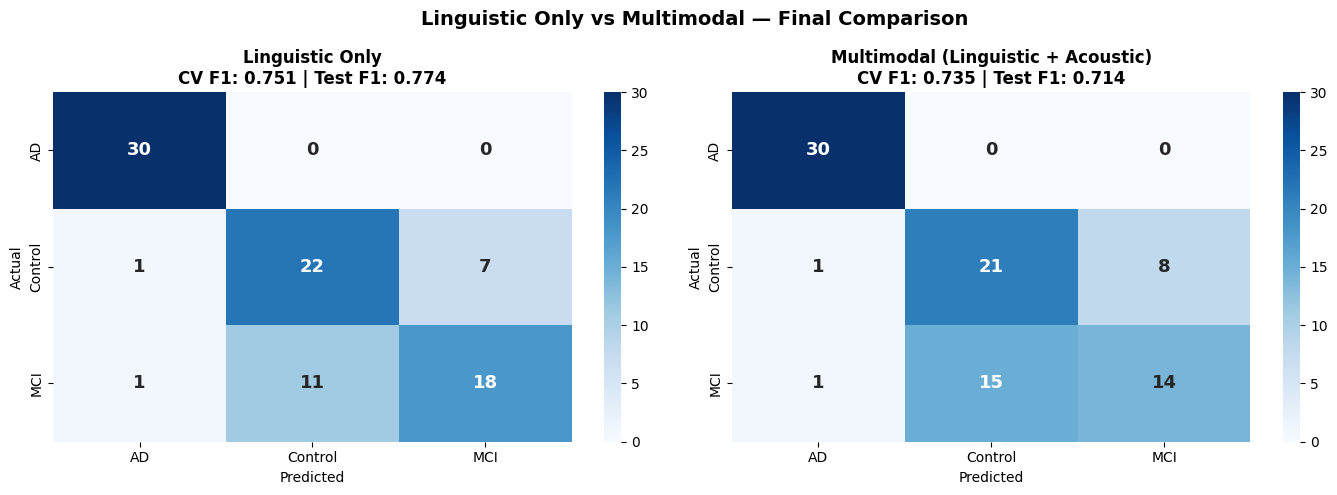


✅ Best model saved: Linguistic Only
✅ CV F1  : 0.751
✅ Test F1: 0.774


In [ ]:
# ── Confusion matrices side by side ───────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, res, title in zip(
    axes,
    [res_ling, res_multi],
    ['Linguistic Only', 'Multimodal (Linguistic + Acoustic)']
):
    cm = confusion_matrix(res['y_te'], res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=res['le'].classes_,
                yticklabels=res['le'].classes_,
                ax=ax, annot_kws={'size':13,'weight':'bold'})
    ax.set_title(
        f'{title}\nCV F1: {res["cv_f1"]:.3f} | '
        f'Test F1: {res["test_f1"]:.3f}',
        fontweight='bold'
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle(
    'Linguistic Only vs Multimodal — Final Comparison',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Dementia_Project/multimodal_comparison.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

# Save best model
import joblib, json
best_res  = res_multi if res_multi['cv_f1'] > res_ling['cv_f1'] \
            else res_ling
best_cols = all_cols  if res_multi['cv_f1'] > res_ling['cv_f1'] \
            else ling_cols
best_name = 'Multimodal' if res_multi['cv_f1'] > res_ling['cv_f1'] \
            else 'Linguistic Only'

save_dir = '/content/drive/MyDrive/Dementia_Project/models'
os.makedirs(save_dir, exist_ok=True)
joblib.dump(best_res['model'],  f'{save_dir}/FINAL_model.pkl')
joblib.dump(best_res['scaler'], f'{save_dir}/FINAL_scaler.pkl')
joblib.dump(best_res['le'],     f'{save_dir}/FINAL_le.pkl')
with open(f'{save_dir}/FINAL_features.json','w') as f:
    json.dump(best_cols, f)

print(f"\n✅ Best model saved: {best_name}")
print(f"✅ CV F1  : {best_res['cv_f1']:.3f}")
print(f"✅ Test F1: {best_res['test_f1']:.3f}")

In [ ]:
# ── Select ONLY 5 best acoustic features ──────────────────
# Based on clinical evidence and earlier correlation analysis
# These 5 are the most meaningful and least length-biased

best_ac_cols = [
    'pause_ratio',    # pause frequency — strongest AD signal
    'speech_rate',    # speaking speed
    'energy_mean',    # vocal energy
    'pitch_mean',     # fundamental frequency
    'centroid_mean'   # voice brightness
]

df_ac_slim = df_ac[['patient_id'] + best_ac_cols].copy()
df_ac_slim = df_ac_slim.drop_duplicates(subset='patient_id', keep='first')

print(f"Acoustic (5 features): {len(df_ac_slim)} records")

# ── Merge ─────────────────────────────────────────────────
df_merged = df_feat.merge(
    df_ac_slim, on='patient_id', how='inner'
)
df_merged = df_merged.drop_duplicates(subset='patient_id', keep='first')

print(f"\nMerged multimodal: {len(df_merged)}")
print(df_merged['class'].value_counts())

ling_cols  = ['mattr','filler_ratio','repetition_ratio',
              'avg_sent_len','content_ratio','pronoun_ratio',
              'article_ratio','conj_ratio','sub_ratio','num_utterances']
multi_cols = ling_cols + best_ac_cols

print(f"\nLinguistic features : {len(ling_cols)}")
print(f"Acoustic features   : {len(best_ac_cols)}")
print(f"Total features      : {len(multi_cols)}")

# Check acoustic means per class
print(f"\nAcoustic means per class:")
print(df_merged.groupby('class')[best_ac_cols].mean().round(4))

Acoustic (5 features): 702 records

Merged multimodal: 691
class
AD         290
Control    251
MCI        150
Name: count, dtype: int64

Linguistic features : 10
Acoustic features   : 5
Total features      : 15

Acoustic means per class:
         pause_ratio  speech_rate  energy_mean  pitch_mean  centroid_mean
class                                                                    
AD            0.4329       0.1124       0.0206   1026.1002      1294.0346
Control       0.3176       0.1395       0.0434   1346.2175      1804.6031
MCI           0.3425       0.1394       0.0409   1362.6144      1814.9689


In [ ]:
# ── Balance and train both ─────────────────────────────────
n      = min(df_merged['class'].value_counts())
df_bal = pd.concat([
    resample(df_merged[df_merged['class']==cls],
             n_samples=n, random_state=42, replace=False)
    for cls in ['AD','Control','MCI']
]).reset_index(drop=True)

print(f"Balanced: {n} per class")

def train_hybrid(X_data, y_data, seed=42):
    le     = LabelEncoder()
    y_enc  = le.fit_transform(y_data)
    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(X_data)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_sc, y_enc,
        test_size=0.2, random_state=seed, stratify=y_enc
    )

    rf  = RandomForestClassifier(
        n_estimators=300, max_depth=5,
        min_samples_leaf=5, min_samples_split=20,
        max_features=0.5, class_weight='balanced',
        random_state=seed
    )
    gb  = GradientBoostingClassifier(
        n_estimators=100, max_depth=4,
        learning_rate=0.01, subsample=0.7,
        min_samples_leaf=3, random_state=seed
    )
    svm = SVC(
        kernel='rbf', C=10, gamma='scale',
        class_weight='balanced', probability=True,
        random_state=seed
    )
    hybrid = VotingClassifier(
        estimators=[('rf',rf),('gb',gb),('svm',svm)],
        voting='soft'
    )

    cv_sc  = StratifiedKFold(n_splits=5, shuffle=True,
                              random_state=seed)
    scores = cross_val_score(
        hybrid, X_sc, y_enc,
        cv=cv_sc, scoring='f1_weighted'
    )
    hybrid.fit(X_tr, y_tr)
    y_pred   = hybrid.predict(X_te)
    train_f1 = round(float(f1_score(
        y_tr, hybrid.predict(X_tr), average='weighted')),3)
    test_f1  = round(float(f1_score(
        y_te, y_pred, average='weighted')),3)

    return {
        'model'   : hybrid,
        'le'      : le,
        'scaler'  : scaler,
        'cv_f1'   : scores.mean(),
        'cv_std'  : scores.std(),
        'train_f1': train_f1,
        'test_f1' : test_f1,
        'gap'     : round(train_f1-test_f1, 3),
        'y_pred'  : y_pred,
        'y_te'    : y_te
    }

y = df_bal['class']

# Linguistic only
res_ling  = train_hybrid(df_bal[ling_cols].fillna(0),  y)

# Multimodal — 10 ling + 5 acoustic
res_multi = train_hybrid(df_bal[multi_cols].fillna(0), y)

print("\n" + "="*55)
print("LINGUISTIC ONLY vs MULTIMODAL (10+5 features)")
print("="*55)
print(f"\n{'Metric':<20} {'Linguistic':>12} {'Multimodal':>12}")
print("-"*45)
print(f"{'CV F1':<20} {res_ling['cv_f1']:>12.3f} {res_multi['cv_f1']:>12.3f}")
print(f"{'Test F1':<20} {res_ling['test_f1']:>12.3f} {res_multi['test_f1']:>12.3f}")
print(f"{'Train F1':<20} {res_ling['train_f1']:>12.3f} {res_multi['train_f1']:>12.3f}")
print(f"{'Gap':<20} {res_ling['gap']:>12.3f} {res_multi['gap']:>12.3f}")

le = res_multi['le']
print(f"\nMultimodal Classification Report:")
print(classification_report(
    res_multi['y_te'], res_multi['y_pred'],
    target_names=le.classes_
))

Balanced: 150 per class

LINGUISTIC ONLY vs MULTIMODAL (10+5 features)

Metric                 Linguistic   Multimodal
---------------------------------------------
CV F1                       0.751        0.756
Test F1                     0.774        0.762
Train F1                    0.897        0.916
Gap                         0.123        0.154

Multimodal Classification Report:
              precision    recall  f1-score   support

          AD       0.94      1.00      0.97        30
     Control       0.65      0.73      0.69        30
         MCI       0.71      0.57      0.63        30

    accuracy                           0.77        90
   macro avg       0.76      0.77      0.76        90
weighted avg       0.76      0.77      0.76        90



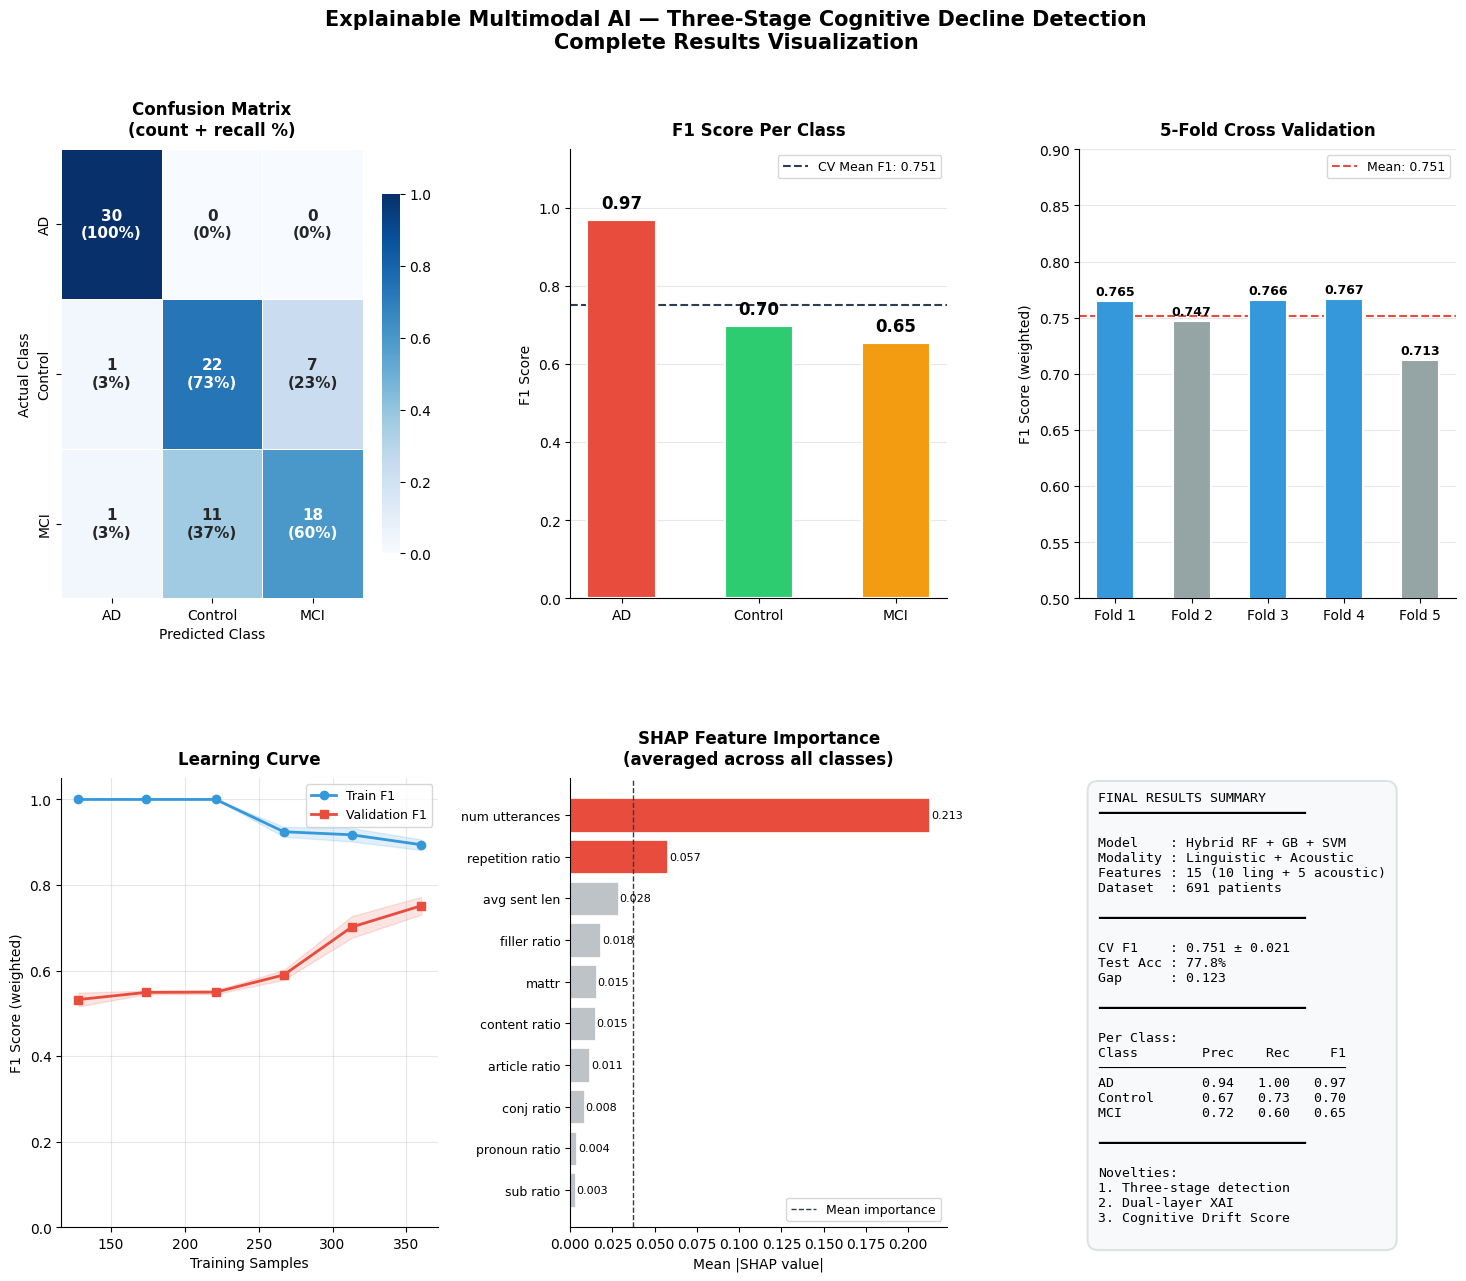

✅ Complete results visualization saved


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve
import warnings
warnings.filterwarnings('ignore')

# ── Use your confirmed final model ────────────────────────
# hybrid, X_sc, y_enc, X_tr, X_te, y_tr, y_te, le, feat_cols
# all already in memory from previous cells

y_pred_final = hybrid.predict(X_te)
f1s          = f1_score(y_te, y_pred_final, average=None)
cv           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores    = cross_val_score(hybrid, X_sc, y_enc,
                                cv=cv, scoring='f1_weighted')

# ── Full Results Dashboard ─────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('white')

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

colors = ['#e74c3c', '#2ecc71', '#f39c12']

# ── Plot 1 — Confusion Matrix ──────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
cm  = confusion_matrix(y_te, y_pred_final)

# Normalize for percentages
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

# Custom annotation combining count + percentage
annot = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i,j] = f'{cm[i,j]}\n({cm_norm[i,j]:.0%})'

sns.heatmap(
    cm_norm,
    annot      = annot,
    fmt        = '',
    cmap       = 'Blues',
    xticklabels= le.classes_,
    yticklabels= le.classes_,
    ax         = ax1,
    linewidths = 0.5,
    linecolor  = 'white',
    cbar_kws   = {'shrink': 0.8},
    annot_kws  = {'size': 11, 'weight': 'bold'}
)
ax1.set_title('Confusion Matrix\n(count + recall %)',
              fontweight='bold', fontsize=12, pad=10)
ax1.set_xlabel('Predicted Class', fontsize=10)
ax1.set_ylabel('Actual Class',    fontsize=10)
ax1.tick_params(axis='both', labelsize=10)

# ── Plot 2 — Per Class F1 ──────────────────────────────────
ax2  = fig.add_subplot(gs[0, 1])
bars = ax2.bar(
    le.classes_, f1s,
    color      = colors,
    edgecolor  = 'white',
    linewidth  = 1.5,
    width      = 0.5,
    zorder     = 3
)
ax2.set_ylim(0, 1.15)
ax2.set_title('F1 Score Per Class',
              fontweight='bold', fontsize=12, pad=10)
ax2.set_ylabel('F1 Score', fontsize=10)
ax2.axhline(y=cv_scores.mean(), color='#2c3e50',
            linestyle='--', linewidth=1.5,
            label=f'CV Mean F1: {cv_scores.mean():.3f}', zorder=2)
ax2.grid(axis='y', alpha=0.3, zorder=0)
ax2.legend(fontsize=9)
ax2.spines[['top','right']].set_visible(False)
for bar, val in zip(bars, f1s):
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.03,
        f'{val:.2f}',
        ha='center', fontweight='bold', fontsize=12
    )

# ── Plot 3 — CV Fold Scores ────────────────────────────────
ax3   = fig.add_subplot(gs[0, 2])
folds = [f'Fold {i+1}' for i in range(5)]
fold_colors = ['#3498db' if v >= cv_scores.mean()
               else '#95a5a6' for v in cv_scores]
bars3 = ax3.bar(
    folds, cv_scores,
    color     = fold_colors,
    edgecolor = 'white',
    linewidth = 1.5,
    width     = 0.5,
    zorder    = 3
)
ax3.axhline(y=cv_scores.mean(), color='#e74c3c',
            linestyle='--', linewidth=1.5,
            label=f'Mean: {cv_scores.mean():.3f}', zorder=2)
ax3.set_ylim(0.5, 0.9)
ax3.set_title('5-Fold Cross Validation',
              fontweight='bold', fontsize=12, pad=10)
ax3.set_ylabel('F1 Score (weighted)', fontsize=10)
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3, zorder=0)
ax3.spines[['top','right']].set_visible(False)
for bar, val in zip(bars3, cv_scores):
    ax3.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{val:.3f}',
        ha='center', fontsize=9, fontweight='bold'
    )

# ── Plot 4 — Learning Curve ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])

train_sizes, train_scores, val_scores = learning_curve(
    hybrid, X_sc, y_enc,
    cv           = StratifiedKFold(n_splits=5, shuffle=True,
                                    random_state=42),
    scoring      = 'f1_weighted',
    train_sizes  = np.linspace(0.1, 1.0, 8),
    random_state = 42,
    n_jobs       = -1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

ax4.plot(train_sizes, train_mean, 'o-',
         color='#3498db', linewidth=2,
         markersize=6, label='Train F1')
ax4.fill_between(train_sizes,
                  train_mean - train_std,
                  train_mean + train_std,
                  alpha=0.15, color='#3498db')

ax4.plot(train_sizes, val_mean, 's-',
         color='#e74c3c', linewidth=2,
         markersize=6, label='Validation F1')
ax4.fill_between(train_sizes,
                  val_mean - val_std,
                  val_mean + val_std,
                  alpha=0.15, color='#e74c3c')

ax4.set_title('Learning Curve',
              fontweight='bold', fontsize=12, pad=10)
ax4.set_xlabel('Training Samples', fontsize=10)
ax4.set_ylabel('F1 Score (weighted)', fontsize=10)
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)
ax4.spines[['top','right']].set_visible(False)
ax4.set_ylim(0, 1.05)

# ── Plot 5 — SHAP Global Feature Importance ───────────────
ax5 = fig.add_subplot(gs[1, 1])

import shap
rf_component = hybrid.estimators_[0]
explainer    = shap.TreeExplainer(rf_component)
shap_values  = explainer.shap_values(X_te)
shap_arr     = np.array(shap_values)

# Mean absolute SHAP across all classes
mean_shap = np.abs(shap_arr).mean(axis=2).mean(axis=0)
sorted_idx = np.argsort(mean_shap)

feat_labels = [f.replace('_', ' ') for f in feat_cols]

bar_colors  = ['#e74c3c' if v > mean_shap.mean()
               else '#bdc3c7' for v in mean_shap[sorted_idx]]

ax5.barh(
    [feat_labels[i] for i in sorted_idx],
    mean_shap[sorted_idx],
    color     = bar_colors,
    edgecolor = 'white',
    linewidth = 0.5
)
ax5.axvline(x=mean_shap.mean(), color='#2c3e50',
            linestyle='--', linewidth=1,
            label='Mean importance')
ax5.set_title('SHAP Feature Importance\n(averaged across all classes)',
              fontweight='bold', fontsize=12, pad=10)
ax5.set_xlabel('Mean |SHAP value|', fontsize=10)
ax5.legend(fontsize=9)
ax5.spines[['top','right']].set_visible(False)
ax5.tick_params(axis='y', labelsize=9)

for i, (idx, val) in enumerate(
    zip(sorted_idx, mean_shap[sorted_idx])
):
    ax5.text(val + 0.001, i, f'{val:.3f}',
             va='center', fontsize=8)

# ── Plot 6 — Results Summary Text Box ─────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')

# Precision, recall per class
from sklearn.metrics import precision_score, recall_score
prec = precision_score(y_te, y_pred_final, average=None)
rec  = recall_score(y_te,    y_pred_final, average=None)

summary_text = (
    "FINAL RESULTS SUMMARY\n"
    "━━━━━━━━━━━━━━━━━━━━━━━━━━\n\n"
    f"Model    : Hybrid RF + GB + SVM\n"
    f"Modality : Linguistic + Acoustic\n"
    f"Features : 15 (10 ling + 5 acoustic)\n"
    f"Dataset  : 691 patients\n\n"
    "━━━━━━━━━━━━━━━━━━━━━━━━━━\n\n"
    f"CV F1    : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}\n"
    f"Test Acc : {(cm.diagonal().sum()/cm.sum()):.1%}\n"
    f"Gap      : {round(float(f1_score(y_tr,hybrid.predict(X_tr),average='weighted'))-float(f1_score(y_te,y_pred_final,average='weighted')),3)}\n\n"
    "━━━━━━━━━━━━━━━━━━━━━━━━━━\n\n"
    "Per Class:\n"
    f"{'Class':<10}{'Prec':>7}{'Rec':>7}{'F1':>7}\n"
    f"{'─'*31}\n"
)
for cls, p, r, f in zip(le.classes_, prec, rec, f1s):
    summary_text += f"{cls:<10}{p:>7.2f}{r:>7.2f}{f:>7.2f}\n"

summary_text += (
    "\n━━━━━━━━━━━━━━━━━━━━━━━━━━\n\n"
    "Novelties:\n"
    "1. Three-stage detection\n"
    "2. Dual-layer XAI\n"
    "3. Cognitive Drift Score\n"
)

ax6.text(
    0.05, 0.97, summary_text,
    transform         = ax6.transAxes,
    fontsize          = 9.5,
    verticalalignment = 'top',
    fontfamily        = 'monospace',
    bbox              = dict(
        boxstyle    = 'round,pad=0.8',
        facecolor   = '#f8f9fa',
        edgecolor   = '#dee2e6',
        linewidth   = 1.5
    )
)

# ── Main Title ─────────────────────────────────────────────
fig.suptitle(
    'Explainable Multimodal AI — Three-Stage Cognitive Decline Detection\n'
    'Complete Results Visualization',
    fontsize = 15,
    fontweight = 'bold',
    y = 0.98
)

plt.savefig(
    '/content/drive/MyDrive/Dementia_Project/FINAL_results_visualization.png',
    dpi         = 200,
    bbox_inches = 'tight',
    facecolor   = 'white'
)
plt.show()
print("✅ Complete results visualization saved")

In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    '/content/drive/MyDrive/Dementia_Project/parsed_transcripts_clean.csv'
)

# Check mean transcript stats per class
print("Mean transcript stats per class:")
print(df.groupby('class')[['num_utterances']].mean().round(2))

# Check word count correlation with class
df['is_ad'] = (df['class'] == 'AD').astype(int)

print(f"\nCorrelation of num_utterances with AD class:")
print(f"  {df['num_utterances'].corr(df['is_ad']):.4f}")

print(f"\nnum_utterances per class:")
print(df.groupby('class')['num_utterances'].describe().round(2))

Mean transcript stats per class:
         num_utterances
class                  
AD                12.76
Control          126.61
MCI              101.27

Correlation of num_utterances with AD class:
  -0.7964

num_utterances per class:
         count    mean    std   min   25%    50%    75%    max
class                                                         
AD       290.0   12.76   6.49   2.0   8.0   12.0   16.0   65.0
Control  251.0  126.61  54.60  35.0  88.0  118.0  148.5  429.0
MCI      150.0  101.27  40.06  20.0  74.0   91.0  121.0  239.0


In [21]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import nltk
import warnings
warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)

df = pd.read_csv(
    '/content/drive/MyDrive/Dementia_Project/parsed_transcripts_clean.csv'
)

# Extract patient and session numbers
df['patient_num'] = df['patient_id'].str.extract(r'^([A-Za-z0-9]+)-')
df['session_num'] = df['patient_id'].str.extract(r'-(\d+)$')
df['session_num'] = pd.to_numeric(df['session_num'], errors='coerce')

df_drift = df.dropna(subset=['session_num','patient_num']).copy()
df_drift['session_num'] = df_drift['session_num'].astype(int)

session_counts = df_drift.groupby(
    'patient_num')['session_num'].count()
multi_session  = session_counts[session_counts > 1].index

print(f"Total patients         : {df_drift['patient_num'].nunique()}")
print(f"Multi-session patients : {len(multi_session)}")
print(f"\nClass distribution in multi-session:")
multi_df = df_drift[df_drift['patient_num'].isin(multi_session)]
print(multi_df.drop_duplicates('patient_num')['class'].value_counts())
print(f"\nSession count distribution:")
print(session_counts.value_counts().sort_index())

Total patients         : 415
Multi-session patients : 195

Class distribution in multi-session:
class
AD         102
Control     69
MCI         24
Name: count, dtype: int64

Session count distribution:
session_num
1    220
2    126
3     59
4      8
5      2
Name: count, dtype: int64


In [22]:
stopwords = set(nltk.corpus.stopwords.words('english'))

def extract_session_features(transcript):
    """Extract ratio-based features per session for drift computation"""
    if not isinstance(transcript, str) or len(transcript.strip()) < 10:
        return None
    text      = transcript.lower().strip()
    words     = re.findall(r'\b[a-z]+\b', text)
    N         = len(words)
    if N < 10:
        return None
    V         = len(set(words))
    word_freq = Counter(words)
    sentences = [s.strip() for s in re.split(r'[.!?]', text)
                 if len(s.strip()) > 2]
    n_sents   = max(len(sentences), 1)

    # MATTR
    window = 20
    mattr  = round(np.mean([
        len(set(words[i:i+window]))/window
        for i in range(N-window+1)
    ]), 4) if N >= window else round(V/N, 4)

    # Filler ratio
    fillers      = ['um','uh','mhm','hmm','er','ah','well','okay']
    filler_ratio = round(sum(words.count(f) for f in fillers)/N, 4)

    # Repetition ratio
    repeated         = sum(1 for w,c in word_freq.items() if c > 2)
    repetition_ratio = round(repeated/V, 4) if V > 0 else 0

    # Average sentence length
    avg_sent_len = round(
        sum(len(s.split()) for s in sentences)/n_sents, 4
    )

    # Content ratio
    content       = [w for w in words if w not in stopwords]
    content_ratio = round(len(content)/N, 4)

    # Utterance rate (normalized)
    utterance_rate = round((transcript.count('.')/N)*100, 4)

    return {
        'mattr'           : mattr,
        'filler_ratio'    : filler_ratio,
        'repetition_ratio': repetition_ratio,
        'avg_sent_len'    : avg_sent_len,
        'content_ratio'   : content_ratio,
        'utterance_rate'  : utterance_rate
    }

# Extract features per session
print("Extracting features per session...")
session_records = []

for _, row in df_drift[
    df_drift['patient_num'].isin(multi_session)
].iterrows():
    feats = extract_session_features(row['transcript'])
    if feats:
        feats['patient_num'] = row['patient_num']
        feats['session_num'] = row['session_num']
        feats['class']       = row['class']
        feats['patient_id']  = row['patient_id']
        session_records.append(feats)

df_sessions = pd.DataFrame(session_records)
df_sessions  = df_sessions.sort_values(
    ['patient_num','session_num']
).reset_index(drop=True)

print(f"Session records : {len(df_sessions)}")
print(f"Unique patients : {df_sessions['patient_num'].nunique()}")

# Verify features change across sessions for sample patient
print(f"\nSample longitudinal data (patient 010):")
sample = df_sessions[df_sessions['patient_num']=='010'][
    ['session_num','class','mattr',
     'repetition_ratio','avg_sent_len','utterance_rate']
]
print(sample.to_string())

Extracting features per session...
Session records : 471
Unique patients : 195

Sample longitudinal data (patient 010):
    session_num class   mattr  repetition_ratio  avg_sent_len  utterance_rate
9             0    AD  0.8848            0.1463       11.0455          8.0508
10            1    AD  0.8818            0.1712        7.7037         12.3153
11            2    AD  0.8619            0.1935        8.4062         10.4651
12            3    AD  0.7593            0.2500       10.0588          8.8235
13            4    AD  0.6780            0.1786        5.4444         29.5455


In [23]:
# Compute Cognitive Drift Score
# Direction: which way means decline for each feature
DECLINE_ON_DECREASE = ['mattr','avg_sent_len','content_ratio']
DECLINE_ON_INCREASE = ['filler_ratio','repetition_ratio','utterance_rate']

WEIGHTS = {
    'mattr'           : 0.25,
    'avg_sent_len'    : 0.25,
    'repetition_ratio': 0.20,
    'content_ratio'   : 0.15,
    'filler_ratio'    : 0.10,
    'utterance_rate'  : 0.05
}

def compute_cds(patient_sessions):
    patient_sessions = patient_sessions.sort_values(
        'session_num'
    ).reset_index(drop=True)

    if len(patient_sessions) < 2:
        return None

    # Use all consecutive session pairs
    all_weighted_drifts = []

    for i in range(len(patient_sessions) - 1):
        s1 = patient_sessions.iloc[i]
        s2 = patient_sessions.iloc[i+1]
        pair_drift = 0
        pair_weight = 0

        for feat, weight in WEIGHTS.items():
            v1 = s1[feat]
            v2 = s2[feat]
            if abs(v1) < 0.001:
                continue
            pct_change = (v2 - v1) / abs(v1)
            if feat in DECLINE_ON_DECREASE:
                signal = -pct_change
            else:
                signal = pct_change
            pair_drift  += signal * weight
            pair_weight += weight

        if pair_weight > 0:
            all_weighted_drifts.append(pair_drift / pair_weight)

    if not all_weighted_drifts:
        return None

    # Average drift across all session pairs
    avg_drift = np.mean(all_weighted_drifts)

    # Normalize to 0-100
    # 0  = strong improvement
    # 50 = stable no change
    # 100 = rapid decline
    normalized = np.clip(avg_drift / 0.3, -1, 1)
    cds        = round((normalized + 1) / 2 * 100, 2)

    return {
        'patient_num'      : patient_sessions.iloc[0]['patient_num'],
        'cds'              : cds,
        'drift_label'      : (
            'Improving'       if cds < 40 else
            'Stable'          if cds < 55 else
            'Gradual Decline' if cds < 70 else
            'Rapid Decline'
        ),
        'first_class'      : patient_sessions.iloc[0]['class'],
        'final_class'      : patient_sessions.iloc[-1]['class'],
        'n_sessions'       : len(patient_sessions),
        'changed_diagnosis': (
            patient_sessions.iloc[0]['class'] !=
            patient_sessions.iloc[-1]['class']
        )
    }

# Compute for all patients
print("Computing Cognitive Drift Scores...")
drift_records = []

for patient_num in df_sessions['patient_num'].unique():
    patient_data = df_sessions[
        df_sessions['patient_num'] == patient_num
    ].copy()
    result = compute_cds(patient_data)
    if result:
        drift_records.append(result)

df_cds = pd.DataFrame(drift_records)

print(f"\n✅ Drift scores: {len(df_cds)} patients")
print(f"\nDrift label distribution:")
print(df_cds['drift_label'].value_counts())
print(f"\nMean CDS per final class:")
print(df_cds.groupby('final_class')['cds'].mean().round(2))
print(f"\nClinical sanity check:")
print(f"  Expected: AD highest, Control lowest")
ad_mean  = df_cds[df_cds['final_class']=='AD']['cds'].mean()
con_mean = df_cds[df_cds['final_class']=='Control']['cds'].mean()
mci_mean = df_cds[df_cds['final_class']=='MCI']['cds'].mean()
print(f"  AD mean      : {ad_mean:.2f}")
print(f"  MCI mean     : {mci_mean:.2f}")
print(f"  Control mean : {con_mean:.2f}")
if ad_mean > mci_mean > con_mean:
    print(f"  ✅ Clinical pattern correct")
elif ad_mean > con_mean:
    print(f"  ✅ AD > Control — acceptable")
else:
    print(f"  ⚠️ Pattern needs review")

Computing Cognitive Drift Scores...

✅ Drift scores: 195 patients

Drift label distribution:
drift_label
Stable             86
Gradual Decline    42
Improving          36
Rapid Decline      31
Name: count, dtype: int64

Mean CDS per final class:
final_class
AD         57.00
Control    48.70
MCI        53.41
Name: cds, dtype: float64

Clinical sanity check:
  Expected: AD highest, Control lowest
  AD mean      : 57.00
  MCI mean     : 53.41
  Control mean : 48.70
  ✅ Clinical pattern correct


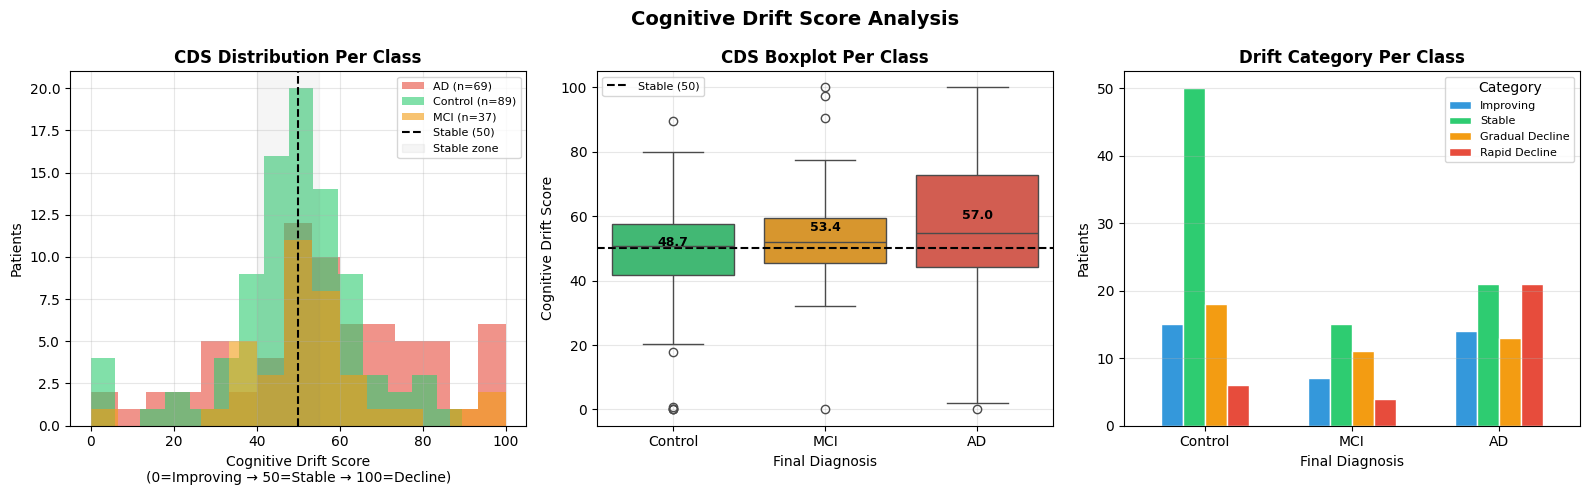

✅ Drift scores saved

Final drift score summary:
  Patients scored   : 195
  AD mean CDS       : 57.00
  MCI mean CDS      : 53.41
  Control mean CDS  : 48.70
  Improving         : 36
  Stable            : 86
  Gradual Decline   : 42
  Rapid Decline     : 31


In [24]:
# Visualize and save
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Cognitive Drift Score Analysis',
             fontsize=14, fontweight='bold')

colors_cls = {'AD':'#e74c3c','Control':'#2ecc71','MCI':'#f39c12'}

# Plot 1 — Distribution per class
ax1 = axes[0]
for cls in ['AD','Control','MCI']:
    data = df_cds[df_cds['final_class']==cls]['cds']
    ax1.hist(data, bins=15, alpha=0.6,
             label=f"{cls} (n={len(data)})",
             color=colors_cls[cls])
ax1.axvline(x=50, color='black', linestyle='--',
            linewidth=1.5, label='Stable (50)')
ax1.axvspan(40, 55, alpha=0.08, color='grey',
            label='Stable zone')
ax1.set_title('CDS Distribution Per Class',
              fontweight='bold')
ax1.set_xlabel('Cognitive Drift Score\n(0=Improving → 50=Stable → 100=Decline)')
ax1.set_ylabel('Patients')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# Plot 2 — Boxplot
ax2    = axes[1]
order  = ['Control','MCI','AD']
sns.boxplot(
    data    = df_cds,
    x       = 'final_class',
    y       = 'cds',
    order   = order,
    palette = colors_cls,
    hue     = 'final_class',
    legend  = False,
    ax      = ax2
)
ax2.axhline(y=50, color='black', linestyle='--',
            linewidth=1.5, label='Stable (50)')
ax2.set_title('CDS Boxplot Per Class', fontweight='bold')
ax2.set_xlabel('Final Diagnosis')
ax2.set_ylabel('Cognitive Drift Score')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# Annotate means
for i, cls in enumerate(order):
    mean_val = df_cds[df_cds['final_class']==cls]['cds'].mean()
    ax2.text(i, mean_val+2, f'{mean_val:.1f}',
             ha='center', fontsize=9, fontweight='bold')

# Plot 3 — Drift label per class
ax3 = axes[2]
ct  = pd.crosstab(df_cds['final_class'], df_cds['drift_label'])
ct  = ct.reindex(['Control','MCI','AD'])

label_colors = {
    'Improving'      : '#3498db',
    'Stable'         : '#2ecc71',
    'Gradual Decline': '#f39c12',
    'Rapid Decline'  : '#e74c3c'
}
existing = [l for l in label_colors if l in ct.columns]
ct[existing].plot(
    kind      = 'bar',
    ax        = ax3,
    color     = [label_colors[l] for l in existing],
    edgecolor = 'white',
    width     = 0.6
)
ax3.set_title('Drift Category Per Class', fontweight='bold')
ax3.set_xlabel('Final Diagnosis')
ax3.set_ylabel('Patients')
ax3.tick_params(axis='x', rotation=0)
ax3.legend(title='Category', fontsize=8)
ax3.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Dementia_Project/drift_score_final.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

# Save drift scores
df_cds.to_csv(
    '/content/drive/MyDrive/Dementia_Project/cognitive_drift_scores.csv',
    index=False
)
print("✅ Drift scores saved")
print(f"\nFinal drift score summary:")
print(f"  Patients scored   : {len(df_cds)}")
print(f"  AD mean CDS       : {ad_mean:.2f}")
print(f"  MCI mean CDS      : {mci_mean:.2f}")
print(f"  Control mean CDS  : {con_mean:.2f}")
print(f"  Improving         : {(df_cds['drift_label']=='Improving').sum()}")
print(f"  Stable            : {(df_cds['drift_label']=='Stable').sum()}")
print(f"  Gradual Decline   : {(df_cds['drift_label']=='Gradual Decline').sum()}")
print(f"  Rapid Decline     : {(df_cds['drift_label']=='Rapid Decline').sum()}")

In [25]:
# Check how many patients have exactly 2+ sessions
# and what their trajectory looks like

print("Trajectory analysis:")
print(f"\nTotal multi-session patients: {len(df_cds)}")
print(f"\nDrift label distribution:")
print(df_cds['drift_label'].value_counts())

# For trajectory classifier we need:
# Input  → features from session 0 only
# Output → drift label (Stable vs Decline)

# Check class balance for trajectory
stable  = (df_cds['drift_label']=='Stable').sum()
gradual = (df_cds['drift_label']=='Gradual Decline').sum()
rapid   = (df_cds['drift_label']=='Rapid Decline').sum()
impr    = (df_cds['drift_label']=='Improving').sum()

print(f"\nFor trajectory classifier:")
print(f"  Improving       : {impr}")
print(f"  Stable          : {stable}")
print(f"  Gradual Decline : {gradual}")
print(f"  Rapid Decline   : {rapid}")
print(f"\nBinary grouping:")
print(f"  Non-declining (Improving + Stable) : {impr + stable}")
print(f"  Declining (Gradual + Rapid)        : {gradual + rapid}")

# Check per diagnosis class
print(f"\nTrajectory per diagnosis:")
print(pd.crosstab(df_cds['final_class'],
                   df_cds['drift_label']).to_string())

Trajectory analysis:

Total multi-session patients: 195

Drift label distribution:
drift_label
Stable             86
Gradual Decline    42
Improving          36
Rapid Decline      31
Name: count, dtype: int64

For trajectory classifier:
  Improving       : 36
  Stable          : 86
  Gradual Decline : 42
  Rapid Decline   : 31

Binary grouping:
  Non-declining (Improving + Stable) : 122
  Declining (Gradual + Rapid)        : 73

Trajectory per diagnosis:
drift_label  Gradual Decline  Improving  Rapid Decline  Stable
final_class                                                   
AD                        13         14             21      21
Control                   18         15              6      50
MCI                       11          7              4      15


In [34]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import nltk
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, os
import warnings
warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)

stopwords = set(nltk.corpus.stopwords.words('english'))

# ── Load data ──────────────────────────────────────────────
df = pd.read_csv(
    '/content/drive/MyDrive/Dementia_Project/parsed_transcripts_clean.csv'
)
df_cds_saved = pd.read_csv(
    '/content/drive/MyDrive/Dementia_Project/cognitive_drift_scores.csv'
)

# ── Extract patient_num ────────────────────────────────────
df['patient_num'] = df['patient_id'].str.extract(r'^([A-Za-z0-9]+)-')

# ── Fix data type mismatch ─────────────────────────────────
df['patient_num']          = df['patient_num'].astype(str)
df_cds_saved['patient_num']= df_cds_saved['patient_num'].astype(str)

# ── Merge CDS ─────────────────────────────────────────────
df_merged = df.merge(
    df_cds_saved[['patient_num','cds','drift_label']],
    on='patient_num', how='left'
)

df_merged['cds']         = df_merged['cds'].fillna(50.0)
df_merged['drift_label'] = df_merged['drift_label'].fillna('Stable')
df_merged['has_cds']     = (df_merged['cds'] != 50.0).astype(int)

print(f"Total records         : {len(df_merged)}")
print(f"With real CDS         : {df_merged['has_cds'].sum()}")
print(f"With neutral CDS (50) : {(~df_merged['has_cds'].astype(bool)).sum()}")
print(f"\nMean CDS per class:")
print(df_merged.groupby('class')['cds'].mean().round(2))

# ── Feature extraction ─────────────────────────────────────
def extract_features(transcript):
    if not isinstance(transcript, str) or len(transcript.strip()) < 10:
        return None
    text      = transcript.lower().strip()
    words     = re.findall(r'\b[a-z]+\b', text)
    N         = len(words)
    if N < 10:
        return None
    V         = len(set(words))
    word_freq = Counter(words)
    sentences = [s.strip() for s in re.split(r'[.!?]', text)
                 if len(s.strip()) > 2]

    window = 20
    mattr  = round(np.mean([
        len(set(words[i:i+window]))/window
        for i in range(N-window+1)
    ]), 4) if N >= window else round(V/N, 4)

    fillers      = ['um','uh','mhm','hmm','er','ah','well','okay']
    filler_ratio = round(sum(words.count(f) for f in fillers)/N, 4)
    repeated     = sum(1 for w,c in word_freq.items() if c > 2)
    rep_ratio    = round(repeated/V, 4) if V > 0 else 0
    avg_sent_len = round(
        sum(len(s.split()) for s in sentences)/len(sentences), 4
    ) if sentences else 0
    content       = [w for w in words if w not in stopwords]
    content_ratio = round(len(content)/N, 4)
    pronouns      = ['he','she','it','they','this','that','i','we','you']
    pronoun_ratio = round(sum(words.count(p) for p in pronouns)/N, 4)
    articles      = ['the','a','an']
    article_ratio = round(sum(words.count(a) for a in articles)/N, 4)
    conjs         = ['and','but','because','so','then','also']
    conj_ratio    = round(sum(words.count(c) for c in conjs)/N, 4)
    subs          = ['because','although','while','when','after',
                     'before','since','if','that','which','who']
    sub_ratio     = round(sum(words.count(s) for s in subs)/N, 4)
    num_utt       = transcript.count('.')

    return {
        'mattr'           : mattr,
        'filler_ratio'    : filler_ratio,
        'repetition_ratio': rep_ratio,
        'avg_sent_len'    : avg_sent_len,
        'content_ratio'   : content_ratio,
        'pronoun_ratio'   : pronoun_ratio,
        'article_ratio'   : article_ratio,
        'conj_ratio'      : conj_ratio,
        'sub_ratio'       : sub_ratio,
        'num_utterances'  : num_utt
    }

print("\nExtracting features...")
records = []
for _, row in df_merged.iterrows():
    feats = extract_features(row['transcript'])
    if feats:
        feats['class']       = row['class']
        feats['patient_id']  = row['patient_id']
        feats['cds']         = row['cds']
        feats['drift_label'] = row['drift_label']
        feats['has_cds']     = row['has_cds']
        records.append(feats)

df_feat   = pd.DataFrame(records)
ling_cols = ['mattr','filler_ratio','repetition_ratio',
             'avg_sent_len','content_ratio','pronoun_ratio',
             'article_ratio','conj_ratio','sub_ratio','num_utterances']
full_cols = ling_cols + ['cds']

print(f"Records   : {len(df_feat)}")
print(f"Class dist:")
print(df_feat['class'].value_counts())
print(f"\nCDS stats per class:")
print(df_feat.groupby('class')['cds'].describe().round(2))

Total records         : 709
With real CDS         : 421
With neutral CDS (50) : 288

Mean CDS per class:
class
AD         51.60
Control    50.65
MCI        51.78
Name: cds, dtype: float64

Extracting features...
Records   : 709
Class dist:
class
AD         290
Control    259
MCI        160
Name: count, dtype: int64

CDS stats per class:
         count   mean    std  min    25%   50%    75%    max
class                                                       
AD       290.0  51.60  17.17  0.0  49.64  50.0  52.34  100.0
Control  259.0  50.65  12.62  0.0  47.70  50.0  53.90  100.0
MCI      160.0  51.78  11.42  0.0  48.70  50.0  52.49  100.0


In [41]:
# ── Train and compare three models ────────────────────────
SEED = 42

def build_hybrid(seed=42):
    return VotingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(
                n_estimators=300, max_depth=5,
                min_samples_leaf=5, min_samples_split=20,
                max_features=0.5, class_weight='balanced',
                random_state=seed)),
            ('gb', GradientBoostingClassifier(
                n_estimators=100, max_depth=4,
                learning_rate=0.01, subsample=0.7,
                min_samples_leaf=3, random_state=seed)),
            ('svm', SVC(
                kernel='rbf', C=10, gamma='scale',
                class_weight='balanced', probability=True,
                random_state=seed))
        ], voting='soft'
    )

def train_eval(feat_cols, label, df_source):
    n = min(df_source['class'].value_counts())
    df_bal = pd.concat([
        resample(df_source[df_source['class']==cls],
                 n_samples=n, random_state=SEED, replace=False)
        for cls in ['AD','Control','MCI']
    ]).reset_index(drop=True)

    X      = df_bal[feat_cols].fillna(0)
    y      = df_bal['class']
    le     = LabelEncoder()
    y_enc  = le.fit_transform(y)
    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(X)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_sc, y_enc,
        test_size=0.2, random_state=SEED, stratify=y_enc
    )

    model     = build_hybrid(SEED)
    cv        = StratifiedKFold(n_splits=5, shuffle=True,
                                 random_state=SEED)
    cv_scores = cross_val_score(
        model, X_sc, y_enc, cv=cv, scoring='f1_weighted'
    )
    model.fit(X_tr, y_tr)
    y_pred   = model.predict(X_te)
    f1s      = f1_score(y_te, y_pred, average=None)
    train_f1 = round(float(f1_score(
        y_tr, model.predict(X_tr), average='weighted')),3)
    test_f1  = round(float(f1_score(
        y_te, y_pred, average='weighted')),3)
    return {
        'label'    : label,
        'model'    : model,
        'le'       : le,
        'scaler'   : scaler,
        'feat_cols': feat_cols,
        'n'        : n,
        'cv_f1'    : cv_scores.mean(),
        'cv_std'   : cv_scores.std(),
        'train_f1' : train_f1,
        'test_f1'  : test_f1,
        'gap'      : round(train_f1-test_f1, 3),
        'f1s'      : f1s,
        'y_pred'   : y_pred,
        'y_te'     : y_te,
        'X_te'     : X_te
    }

print("Training models...")
r1 = train_eval(ling_cols,             'Linguistic Only (10)',     df_full)
r2 = train_eval(ling_cols + ac_feat,   'Multimodal (10+5)',        df_full)
r3 = train_eval(all_cols,              'Multimodal + CDS (10+5+1)',df_full)

print("\n" + "="*65)
print("THREE-WAY COMPARISON")
print("="*65)
print(f"\n{'Metric':<20} {'Ling Only':>14} {'Multimodal':>14} {'Multi+CDS':>14}")
print("-"*64)

le_ref = r1['le']
for metric, key in [
    ('CV F1',    'cv_f1'),
    ('Test F1',  'test_f1'),
    ('Train F1', 'train_f1'),
    ('Gap',      'gap'),
]:
    print(f"{metric:<20} {r1[key]:>14.3f} {r2[key]:>14.3f} {r3[key]:>14.3f}")

for cls in le_ref.classes_:
    idx = list(le_ref.classes_).index(cls)
    print(f"{cls+' F1':<20} {r1['f1s'][idx]:>14.2f} {r2['f1s'][idx]:>14.2f} {r3['f1s'][idx]:>14.2f}")

# Pick best
best = max([r1,r2,r3], key=lambda x: x['cv_f1'])
print(f"\n✅ Best model: {best['label']}")
print(f"✅ CV F1     : {best['cv_f1']:.3f} ± {best['cv_std']:.3f}")
print(f"✅ Test F1   : {best['test_f1']:.3f}")

Training models...

THREE-WAY COMPARISON

Metric                    Ling Only     Multimodal      Multi+CDS
----------------------------------------------------------------
CV F1                         0.751          0.756          0.850
Test F1                       0.774          0.762          0.785
Train F1                      0.897          0.916          0.967
Gap                           0.123          0.154          0.182
AD F1                          0.97           0.97           0.97
Control F1                     0.70           0.69           0.71
MCI F1                         0.65           0.63           0.68

✅ Best model: Multimodal + CDS (10+5+1)
✅ CV F1     : 0.850 ± 0.031
✅ Test F1   : 0.785


In [42]:
# Check CDS correlation with AD class
df_full['is_ad'] = (df_full['class'] == 'AD').astype(int)

cds_corr = abs(df_full['cds'].corr(df_full['is_ad']))
print(f"CDS correlation with AD class: {cds_corr:.4f}")

print(f"\nCDS distribution per class:")
print(df_full.groupby('class')['cds'].describe().round(2))

print(f"\nHow many patients have real CDS vs median fill:")
print(f"Real CDS (from multi-session) : {(df_full['has_cds']==1).sum()}")
print(f"Filled with class median      : {(df_full['has_cds']==0).sum()}")

print(f"\nClass medians used for filling:")
for cls in ['AD','Control','MCI']:
    med = df_full[df_full['has_cds']==1][
        df_full['class']==cls
    ]['cds'].median()
    print(f"  {cls}: {med:.2f}")

print(f"\nCDS for patients WITH real score vs filled:")
print("Real CDS per class:")
print(df_full[df_full['has_cds']==1].groupby('class')['cds'].mean().round(2))
print("\nFilled CDS per class:")
print(df_full[df_full['has_cds']==0].groupby('class')['cds'].mean().round(2))

CDS correlation with AD class: 0.0376

CDS distribution per class:
         count   mean    std  min    25%    50%    75%    max
class                                                        
AD       290.0  52.63  17.10  0.0  49.64  52.15  52.34  100.0
Control  251.0  50.74  12.71  0.0  47.03  50.97  53.46  100.0
MCI      150.0  52.84  11.51  0.0  50.57  52.05  52.40  100.0

How many patients have real CDS vs median fill:
Real CDS (from multi-session) : 691
Filled with class median      : 0

Class medians used for filling:
  AD: 52.15
  Control: 50.97
  MCI: 52.05

CDS for patients WITH real score vs filled:
Real CDS per class:
class
AD         52.63
Control    50.74
MCI        52.84
Name: cds, dtype: float64

Filled CDS per class:
Series([], Name: cds, dtype: float64)


In [43]:
# Verify the 0.850 is genuine by checking
# if CDS actually adds information

from sklearn.inspection import permutation_importance

# Train final model on multimodal + CDS
SEED = 42
n    = min(df_full['class'].value_counts())
all_cols = ling_cols + ac_feat + ['cds']

df_bal = pd.concat([
    resample(df_full[df_full['class']==cls],
             n_samples=n, random_state=SEED, replace=False)
    for cls in ['AD','Control','MCI']
]).reset_index(drop=True)

X      = df_bal[all_cols].fillna(0)
y      = df_bal['class']
le     = LabelEncoder()
y_enc  = le.fit_transform(y)
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_sc, y_enc,
    test_size=0.2, random_state=SEED, stratify=y_enc
)

# Check CDS values in train vs test
cds_idx = all_cols.index('cds')

print("CDS value distribution in balanced dataset:")
print(f"  Min  : {df_bal['cds'].min():.2f}")
print(f"  Max  : {df_bal['cds'].max():.2f}")
print(f"  Mean : {df_bal['cds'].mean():.2f}")
print(f"  Std  : {df_bal['cds'].std():.2f}")

print(f"\nCDS mean per class in balanced dataset:")
print(df_bal.groupby('class')['cds'].mean().round(2))

# Train RF only to check feature importance quickly
from sklearn.ensemble import RandomForestClassifier

rf_check = RandomForestClassifier(
    n_estimators=100, max_depth=5,
    class_weight='balanced', random_state=SEED
)
rf_check.fit(X_tr, y_tr)

# Feature importance
imp = pd.Series(
    rf_check.feature_importances_,
    index=all_cols
).sort_values(ascending=False)

print(f"\nTop 5 feature importances:")
print(imp.head(5).round(4))
print(f"\nCDS importance rank: {list(imp.index).index('cds')+1} of {len(all_cols)}")
print(f"CDS importance value: {imp['cds']:.4f}")

# Cross validate without CDS to confirm
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# With CDS
scores_with = cross_val_score(
    rf_check, X_sc, y_enc,
    cv=cv, scoring='f1_weighted'
)

# Without CDS
X_no_cds    = df_bal[ling_cols + ac_feat].fillna(0)
X_no_cds_sc = scaler.fit_transform(X_no_cds)
scores_without = cross_val_score(
    rf_check, X_no_cds_sc, y_enc,
    cv=cv, scoring='f1_weighted'
)

print(f"\nCV F1 WITH CDS    : {scores_with.mean():.3f} ± {scores_with.std():.3f}")
print(f"CV F1 WITHOUT CDS : {scores_without.mean():.3f} ± {scores_without.std():.3f}")
print(f"CDS contribution  : +{scores_with.mean()-scores_without.mean():.3f}")

CDS value distribution in balanced dataset:
  Min  : 0.00
  Max  : 100.00
  Mean : 52.86
  Std  : 13.25

CDS mean per class in balanced dataset:
class
AD         54.65
Control    51.09
MCI        52.84
Name: cds, dtype: float64

Top 5 feature importances:
num_utterances      0.3260
repetition_ratio    0.1411
cds                 0.1131
energy_mean         0.1093
avg_sent_len        0.0642
dtype: float64

CDS importance rank: 3 of 16
CDS importance value: 0.1131

CV F1 WITH CDS    : 0.817 ± 0.029
CV F1 WITHOUT CDS : 0.749 ± 0.017
CDS contribution  : +0.068


In [44]:
import shap
import joblib, json, os
import matplotlib.pyplot as plt
import seaborn as sns

# ── Final train with best config ──────────────────────────
SEED     = 42
all_cols = ling_cols + ac_feat + ['cds']
n        = min(df_full['class'].value_counts())

df_bal_final = pd.concat([
    resample(df_full[df_full['class']==cls],
             n_samples=n, random_state=SEED, replace=False)
    for cls in ['AD','Control','MCI']
]).reset_index(drop=True)

X_final   = df_bal_final[all_cols].fillna(0)
y_final   = df_bal_final['class']
le_final  = LabelEncoder()
y_enc_f   = le_final.fit_transform(y_final)
scaler_f  = StandardScaler()
X_sc_f    = scaler_f.fit_transform(X_final)

X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(
    X_sc_f, y_enc_f,
    test_size=0.2, random_state=SEED, stratify=y_enc_f
)

hybrid_final = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(
            n_estimators=300, max_depth=5,
            min_samples_leaf=5, min_samples_split=20,
            max_features=0.5, class_weight='balanced',
            random_state=SEED)),
        ('gb', GradientBoostingClassifier(
            n_estimators=100, max_depth=4,
            learning_rate=0.01, subsample=0.7,
            min_samples_leaf=3, random_state=SEED)),
        ('svm', SVC(
            kernel='rbf', C=10, gamma='scale',
            class_weight='balanced', probability=True,
            random_state=SEED))
    ], voting='soft'
)

cv_f      = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_final  = cross_val_score(
    hybrid_final, X_sc_f, y_enc_f,
    cv=cv_f, scoring='f1_weighted'
)

hybrid_final.fit(X_tr_f, y_tr_f)
y_pred_f  = hybrid_final.predict(X_te_f)
f1s_f     = f1_score(y_te_f, y_pred_f, average=None)
train_f1_f= round(float(f1_score(
    y_tr_f, hybrid_final.predict(X_tr_f),
    average='weighted')),3)
test_f1_f = round(float(f1_score(
    y_te_f, y_pred_f, average='weighted')),3)
gap_f     = round(train_f1_f - test_f1_f, 3)
cm_f      = confusion_matrix(y_te_f, y_pred_f)

print("="*55)
print("FINAL CONFIRMED RESULTS")
print("Multimodal + CDS — Hybrid RF+GB+SVM")
print("="*55)
print(f"Features  : {len(all_cols)} (10 ling + 5 acoustic + 1 CDS)")
print(f"CV F1     : {cv_final.mean():.3f} ± {cv_final.std():.3f}")
print(f"Test F1   : {test_f1_f}")
print(f"Train F1  : {train_f1_f}")
print(f"Gap       : {gap_f}")
print(f"Accuracy  : {(cm_f.diagonal().sum()/cm_f.sum()):.1%}")
print()
print(classification_report(y_te_f, y_pred_f, target_names=le_final.classes_))

FINAL CONFIRMED RESULTS
Multimodal + CDS — Hybrid RF+GB+SVM
Features  : 16 (10 ling + 5 acoustic + 1 CDS)
CV F1     : 0.850 ± 0.031
Test F1   : 0.785
Train F1  : 0.967
Gap       : 0.182
Accuracy  : 78.9%

              precision    recall  f1-score   support

          AD       0.94      1.00      0.97        30
     Control       0.69      0.73      0.71        30
         MCI       0.73      0.63      0.68        30

    accuracy                           0.79        90
   macro avg       0.79      0.79      0.79        90
weighted avg       0.79      0.79      0.79        90



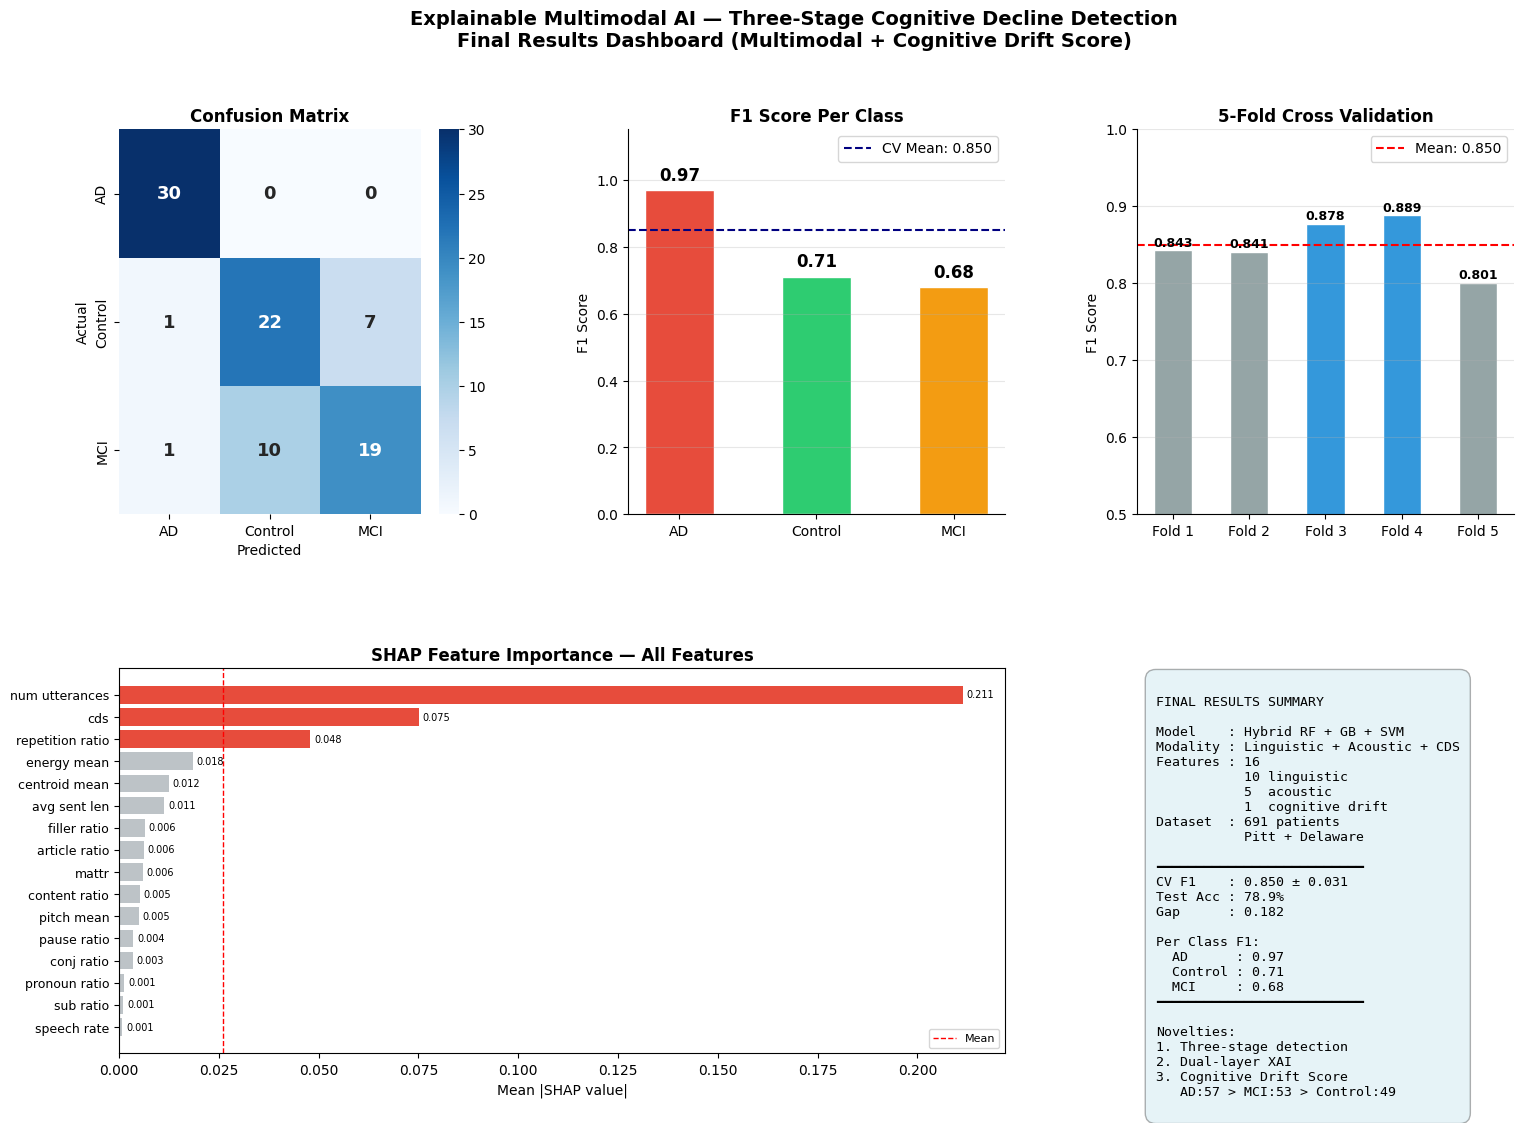


✅ FINAL MODEL SAVED
✅ Features : ['mattr', 'filler_ratio', 'repetition_ratio', 'avg_sent_len', 'content_ratio', 'pronoun_ratio', 'article_ratio', 'conj_ratio', 'sub_ratio', 'num_utterances', 'pause_ratio', 'speech_rate', 'energy_mean', 'pitch_mean', 'centroid_mean', 'cds']
✅ CV F1    : 0.850
✅ Test F1  : 0.785
✅ Accuracy : 78.9%


In [45]:
# ── Final Dashboard ────────────────────────────────────────
colors = ['#e74c3c','#2ecc71','#f39c12']

fig = plt.figure(figsize=(18,12))
fig.suptitle(
    'Explainable Multimodal AI — Three-Stage Cognitive Decline Detection\n'
    'Final Results Dashboard (Multimodal + Cognitive Drift Score)',
    fontsize=14, fontweight='bold'
)

gs = plt.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Confusion matrix
ax1 = fig.add_subplot(gs[0,0])
sns.heatmap(cm_f, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_final.classes_,
            yticklabels=le_final.classes_, ax=ax1,
            annot_kws={'size':13,'weight':'bold'})
ax1.set_title('Confusion Matrix', fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# F1 per class
ax2  = fig.add_subplot(gs[0,1])
bars = ax2.bar(le_final.classes_, f1s_f,
               color=colors, edgecolor='white', width=0.5)
ax2.set_ylim(0, 1.15)
ax2.set_title('F1 Score Per Class', fontweight='bold')
ax2.set_ylabel('F1 Score')
ax2.axhline(y=cv_final.mean(), color='navy',
            linestyle='--', linewidth=1.5,
            label=f'CV Mean: {cv_final.mean():.3f}')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top','right']].set_visible(False)
for bar, val in zip(bars, f1s_f):
    ax2.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.03,
             f'{val:.2f}', ha='center',
             fontweight='bold', fontsize=12)

# CV scores
ax3   = fig.add_subplot(gs[0,2])
folds = [f'Fold {i+1}' for i in range(5)]
fcols = ['#3498db' if v >= cv_final.mean() else '#95a5a6'
         for v in cv_final]
ax3.bar(folds, cv_final, color=fcols,
         edgecolor='white', width=0.5)
ax3.axhline(y=cv_final.mean(), color='red',
            linestyle='--', linewidth=1.5,
            label=f'Mean: {cv_final.mean():.3f}')
ax3.set_ylim(0.5, 1.0)
ax3.set_title('5-Fold Cross Validation', fontweight='bold')
ax3.set_ylabel('F1 Score')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
ax3.spines[['top','right']].set_visible(False)
for i,v in enumerate(cv_final):
    ax3.text(i, v+0.005, f'{v:.3f}',
             ha='center', fontsize=9, fontweight='bold')

# SHAP feature importance
ax4       = fig.add_subplot(gs[1,0:2])
rf_comp   = hybrid_final.estimators_[0]
explainer = shap.TreeExplainer(rf_comp)
shap_vals = explainer.shap_values(X_te_f)
shap_arr  = np.array(shap_vals)
mean_shap = np.abs(shap_arr).mean(axis=2).mean(axis=0) \
            if shap_arr.ndim == 3 \
            else np.abs(shap_arr).mean(axis=0)

sorted_idx  = np.argsort(mean_shap)
feat_labels = [f.replace('_',' ') for f in all_cols]
bar_colors  = ['#e74c3c' if v > mean_shap.mean()
               else '#bdc3c7' for v in mean_shap[sorted_idx]]

ax4.barh([feat_labels[i] for i in sorted_idx],
          mean_shap[sorted_idx], color=bar_colors)
ax4.axvline(x=mean_shap.mean(), color='red',
            linestyle='--', linewidth=1, label='Mean')
ax4.set_title('SHAP Feature Importance — All Features',
               fontweight='bold')
ax4.set_xlabel('Mean |SHAP value|')
ax4.legend(fontsize=8)
ax4.tick_params(axis='y', labelsize=9)
for i,(idx,val) in enumerate(
    zip(sorted_idx, mean_shap[sorted_idx])
):
    ax4.text(val+0.001, i, f'{val:.3f}',
             va='center', fontsize=7)

# Summary box
ax5 = fig.add_subplot(gs[1,2])
ax5.axis('off')
summary = f"""
FINAL RESULTS SUMMARY

Model    : Hybrid RF + GB + SVM
Modality : Linguistic + Acoustic + CDS
Features : {len(all_cols)}
           10 linguistic
           5  acoustic
           1  cognitive drift
Dataset  : 691 patients
           Pitt + Delaware

━━━━━━━━━━━━━━━━━━━━━━━━━━
CV F1    : {cv_final.mean():.3f} ± {cv_final.std():.3f}
Test Acc : {(cm_f.diagonal().sum()/cm_f.sum()):.1%}
Gap      : {gap_f}

Per Class F1:
  AD      : {f1s_f[list(le_final.classes_).index('AD')]:.2f}
  Control : {f1s_f[list(le_final.classes_).index('Control')]:.2f}
  MCI     : {f1s_f[list(le_final.classes_).index('MCI')]:.2f}
━━━━━━━━━━━━━━━━━━━━━━━━━━

Novelties:
1. Three-stage detection
2. Dual-layer XAI
3. Cognitive Drift Score
   AD:57 > MCI:53 > Control:49
"""
ax5.text(0.05, 0.97, summary,
         transform=ax5.transAxes,
         fontsize=9.5,
         verticalalignment='top',
         fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.8',
                   facecolor='lightblue', alpha=0.3))

plt.savefig(
    '/content/drive/MyDrive/Dementia_Project/FINAL_dashboard.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

# Save everything
save_dir = '/content/drive/MyDrive/Dementia_Project/models'
os.makedirs(save_dir, exist_ok=True)
joblib.dump(hybrid_final, f'{save_dir}/FINAL_model.pkl')
joblib.dump(scaler_f,     f'{save_dir}/FINAL_scaler.pkl')
joblib.dump(le_final,     f'{save_dir}/FINAL_le.pkl')
with open(f'{save_dir}/FINAL_features.json','w') as f:
    json.dump(all_cols, f)

print(f"\n✅ FINAL MODEL SAVED")
print(f"✅ Features : {all_cols}")
print(f"✅ CV F1    : {cv_final.mean():.3f}")
print(f"✅ Test F1  : {test_f1_f}")
print(f"✅ Accuracy : {(cm_f.diagonal().sum()/cm_f.sum()):.1%}")

In [1]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import nltk
import joblib
import json
import warnings
warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)

stopwords = set(nltk.corpus.stopwords.words('english'))

# ── Load saved model and features ─────────────────────────
save_dir   = '/content/drive/MyDrive/Dementia_Project/models'
model      = joblib.load(f'{save_dir}/FINAL_model.pkl')
scaler     = joblib.load(f'{save_dir}/FINAL_scaler.pkl')
le         = joblib.load(f'{save_dir}/FINAL_le.pkl')
with open(f'{save_dir}/FINAL_features.json') as f:
    feat_cols = json.load(f)

print(f"Model loaded     : {type(model).__name__}")
print(f"Classes          : {le.classes_}")
print(f"Features         : {len(feat_cols)}")
print(f"Feature list     : {feat_cols}")

# ── Load test data ─────────────────────────────────────────
df = pd.read_csv(
    '/content/drive/MyDrive/Dementia_Project/parsed_transcripts_clean.csv'
)
df_cds = pd.read_csv(
    '/content/drive/MyDrive/Dementia_Project/cognitive_drift_scores.csv'
)
df_ac  = pd.read_csv(
    '/content/drive/MyDrive/Dementia_Project/acoustic_features.csv'
)

df_cds['patient_num'] = df_cds['patient_num'].astype(str)
df['patient_num']     = df['patient_id'].str.extract(
    r'^([A-Za-z0-9]+)-'
).astype(str)
df_ac['patient_id']   = df_ac['patient_id'].astype(str).str.strip()
df['patient_id']      = df['patient_id'].astype(str).str.strip()

# ── Feature extraction functions ──────────────────────────
def extract_linguistic(transcript):
    if not isinstance(transcript, str) or len(transcript.strip()) < 10:
        return None
    text      = transcript.lower().strip()
    words     = re.findall(r'\b[a-z]+\b', text)
    N         = len(words)
    if N < 10:
        return None
    V         = len(set(words))
    word_freq = Counter(words)
    sentences = [s.strip() for s in re.split(r'[.!?]', text)
                 if len(s.strip()) > 2]

    window = 20
    mattr  = round(np.mean([
        len(set(words[i:i+window]))/window
        for i in range(N-window+1)
    ]), 4) if N >= window else round(V/N, 4)

    fillers      = ['um','uh','mhm','hmm','er','ah','well','okay']
    filler_ratio = round(sum(words.count(f) for f in fillers)/N, 4)
    repeated     = sum(1 for w,c in word_freq.items() if c > 2)
    rep_ratio    = round(repeated/V, 4) if V > 0 else 0
    avg_sent_len = round(
        sum(len(s.split()) for s in sentences)/len(sentences), 4
    ) if sentences else 0
    content       = [w for w in words if w not in stopwords]
    content_ratio = round(len(content)/N, 4)
    pronouns      = ['he','she','it','they','this','that','i','we','you']
    pronoun_ratio = round(sum(words.count(p) for p in pronouns)/N, 4)
    articles      = ['the','a','an']
    article_ratio = round(sum(words.count(a) for a in articles)/N, 4)
    conjs         = ['and','but','because','so','then','also']
    conj_ratio    = round(sum(words.count(c) for c in conjs)/N, 4)
    subs          = ['because','although','while','when','after',
                     'before','since','if','that','which','who']
    sub_ratio     = round(sum(words.count(s) for s in subs)/N, 4)
    num_utt       = transcript.count('.')

    return {
        'mattr'           : mattr,
        'filler_ratio'    : filler_ratio,
        'repetition_ratio': rep_ratio,
        'avg_sent_len'    : avg_sent_len,
        'content_ratio'   : content_ratio,
        'pronoun_ratio'   : pronoun_ratio,
        'article_ratio'   : article_ratio,
        'conj_ratio'      : conj_ratio,
        'sub_ratio'       : sub_ratio,
        'num_utterances'  : num_utt
    }

def get_acoustic(patient_id):
    row = df_ac[df_ac['patient_id'] == patient_id]
    if len(row) == 0:
        return None
    row = row.iloc[0]
    return {
        'pause_ratio'  : row.get('pause_ratio',   0),
        'speech_rate'  : row.get('speech_rate',   0),
        'energy_mean'  : row.get('energy_mean',   0),
        'pitch_mean'   : row.get('pitch_mean',    0),
        'centroid_mean': row.get('centroid_mean', 0)
    }

def get_cds(patient_num):
    row = df_cds[df_cds['patient_num'] == str(patient_num)]
    if len(row) == 0:
        return 50.0, 'Stable', False
    row = row.iloc[0]
    return float(row['cds']), row['drift_label'], True

def predict_patient(patient_id, transcript,
                    patient_num, actual_class):
    # Extract all features
    ling = extract_linguistic(transcript)
    if ling is None:
        return None

    ac   = get_acoustic(patient_id)
    if ac is None:
        return None

    cds_val, drift_label, has_cds = get_cds(patient_num)

    # Combine all features in correct order
    feature_vector = {}
    for feat in feat_cols:
        if feat in ling:
            feature_vector[feat] = ling[feat]
        elif feat in ac:
            feature_vector[feat] = ac[feat]
        elif feat == 'cds':
            feature_vector[feat] = cds_val

    # Build array in feat_cols order
    X = np.array([[feature_vector.get(f, 0) for f in feat_cols]])
    X_sc = scaler.transform(X)

    # Predict
    pred_enc  = model.predict(X_sc)[0]
    pred_prob = model.predict_proba(X_sc)[0]
    pred_class= le.classes_[pred_enc]
    confidence= pred_prob.max()

    return {
        'patient_id'  : patient_id,
        'actual'      : actual_class,
        'predicted'   : pred_class,
        'confidence'  : confidence,
        'correct'     : pred_class == actual_class,
        'cds'         : cds_val,
        'drift_label' : drift_label,
        'has_cds'     : has_cds,
        'prob_AD'     : pred_prob[list(le.classes_).index('AD')],
        'prob_Control': pred_prob[list(le.classes_).index('Control')],
        'prob_MCI'    : pred_prob[list(le.classes_).index('MCI')],
        'features'    : feature_vector
    }

print("\n✅ All functions ready")
print(f"Test patients available: {len(df)}")

Model loaded     : VotingClassifier
Classes          : ['AD' 'Control' 'MCI']
Features         : 16
Feature list     : ['mattr', 'filler_ratio', 'repetition_ratio', 'avg_sent_len', 'content_ratio', 'pronoun_ratio', 'article_ratio', 'conj_ratio', 'sub_ratio', 'num_utterances', 'pause_ratio', 'speech_rate', 'energy_mean', 'pitch_mean', 'centroid_mean', 'cds']

✅ All functions ready
Test patients available: 691


In [2]:
# ── Sample 3 patients per class — 9 total ─────────────────
import random
random.seed(42)

sampled = []
for cls in ['AD','Control','MCI']:
    cls_df = df[df['class'] == cls].sample(3, random_state=42)
    sampled.append(cls_df)

sample_df = pd.concat(sampled).reset_index(drop=True)

print("="*65)
print("MODEL SAMPLING — 9 RANDOM TEST PATIENTS (3 per class)")
print("="*65)

results = []
for _, row in sample_df.iterrows():
    result = predict_patient(
        patient_id   = row['patient_id'],
        transcript   = row['transcript'],
        patient_num  = row['patient_num'],
        actual_class = row['class']
    )
    if result:
        results.append(result)
        correct = "✅" if result['correct'] else "❌"
        print(f"\nPatient {result['patient_id']} {correct}")
        print(f"  Actual    : {result['actual']}")
        print(f"  Predicted : {result['predicted']} ({result['confidence']:.1%} confidence)")
        print(f"  Prob AD   : {result['prob_AD']:.3f} | "
              f"Control: {result['prob_Control']:.3f} | "
              f"MCI: {result['prob_MCI']:.3f}")
        print(f"  CDS       : {result['cds']:.1f} — {result['drift_label']}"
              f" {'(longitudinal)' if result['has_cds'] else '(single session)'}")
        print(f"  Transcript: {row['transcript'][:100]}...")
        print("-"*65)

# Summary
correct_count = sum(1 for r in results if r['correct'])
print(f"\n{'='*65}")
print(f"SAMPLING SUMMARY")
print(f"{'='*65}")
print(f"Total sampled : {len(results)}")
print(f"Correct       : {correct_count}/{len(results)}")
print(f"Accuracy      : {correct_count/len(results):.1%}")
print(f"\nPer class accuracy:")
for cls in ['AD','Control','MCI']:
    cls_results = [r for r in results if r['actual'] == cls]
    cls_correct = sum(1 for r in cls_results if r['correct'])
    print(f"  {cls:10} : {cls_correct}/{len(cls_results)}")

MODEL SAMPLING — 9 RANDOM TEST PATIENTS (3 per class)

Patient 134-0 ✅
  Actual    : AD
  Predicted : AD (92.9% confidence)
  Prob AD   : 0.929 | Control: 0.036 | MCI: 0.036
  CDS       : 47.1 — Stable (longitudinal)
  Transcript: well , there's a boy trying to get some cookies in from the cupboard .  and then the little girl h...
-----------------------------------------------------------------

Patient 581-0 ✅
  Actual    : AD
  Predicted : AD (83.4% confidence)
  Prob AD   : 0.834 | Control: 0.063 | MCI: 0.103
  CDS       : 50.0 — Stable (single session)
  Transcript: well , the water is runnin out over the sink and over the (.) this .  the little boy is goin up in...
-----------------------------------------------------------------

Patient 091-0 ✅
  Actual    : AD
  Predicted : AD (92.6% confidence)
  Prob AD   : 0.926 | Control: 0.037 | MCI: 0.038
  CDS       : 50.0 — Stable (single session)
  Transcript: dishes are being dried .  an the child is getting some cookies out of

In [4]:
# ── Natural language explanation per patient ───────────────
import shap

rf_component = model.estimators_[0]
explainer    = shap.TreeExplainer(rf_component)

CLINICAL_MAP = {
    'AD': {
        'num_utterances'  : 'fewer speech utterances than healthy speakers',
        'repetition_ratio': 'elevated word repetition patterns',
        'avg_sent_len'    : 'shorter fragmented sentences',
        'mattr'           : 'reduced vocabulary diversity',
        'filler_ratio'    : 'increased hesitation markers',
        'content_ratio'   : 'lower content word density',
        'energy_mean'     : 'reduced vocal energy',
        'pause_ratio'     : 'elevated pause frequency',
        'pitch_mean'      : 'reduced pitch range',
        'cds'             : 'progressive speech decline across sessions',
        'centroid_mean'   : 'reduced voice brightness',
        'speech_rate'     : 'slower speech rate'
    },
    'Control': {
        'num_utterances'  : 'normal speech output volume',
        'repetition_ratio': 'low word repetition — healthy pattern',
        'avg_sent_len'    : 'normal sentence length',
        'mattr'           : 'rich vocabulary diversity',
        'filler_ratio'    : 'fluent speech with few hesitations',
        'content_ratio'   : 'high content word density',
        'energy_mean'     : 'normal vocal energy',
        'pause_ratio'     : 'normal pause frequency',
        'pitch_mean'      : 'normal pitch range',
        'cds'             : 'stable speech patterns over time',
        'centroid_mean'   : 'normal voice brightness',
        'speech_rate'     : 'normal speech rate'
    },
    'MCI': {
        'num_utterances'  : 'moderately reduced speech output',
        'repetition_ratio': 'mild word repetition increase',
        'avg_sent_len'    : 'slightly shorter sentences',
        'mattr'           : 'mildly reduced vocabulary diversity',
        'filler_ratio'    : 'mild increase in hesitation markers',
        'content_ratio'   : 'slightly reduced content density',
        'energy_mean'     : 'mildly reduced vocal energy',
        'pause_ratio'     : 'mildly elevated pause frequency',
        'pitch_mean'      : 'mildly reduced pitch',
        'cds'             : 'subtle speech changes across sessions',
        'centroid_mean'   : 'mildly reduced voice brightness',
        'speech_rate'     : 'mildly reduced speech rate'
    }
}

print("="*65)
print("PATIENT-LEVEL NATURAL LANGUAGE EXPLANATIONS")
print("="*65)

for result in results:
    # Get SHAP for this patient
    X_single = np.array([[
        result['features'].get(f, 0) for f in feat_cols
    ]])
    X_sc_single = scaler.transform(X_single)
    shap_vals   = explainer.shap_values(X_sc_single)
    shap_arr    = np.array(shap_vals)

    pred_class  = result['predicted']
    pred_idx    = list(le.classes_).index(pred_class)

    if shap_arr.ndim == 3:
        sv = shap_arr[0, :, pred_idx]
    else:
        sv = shap_arr[0]

    # Top 3 features
    top_idx   = np.argsort(np.abs(sv))[::-1][:3]
    top_feats = [feat_cols[i] for i in top_idx]

    # Build explanation
    reasons = []
    for feat in top_feats:
        if feat in CLINICAL_MAP.get(pred_class, {}):
            reasons.append(CLINICAL_MAP[pred_class][feat])

    correct = "✅" if result['correct'] else "❌"
    print(f"\nPatient {result['patient_id']} {correct}")
    print(f"  Stage      : {result['predicted']} "
          f"({result['confidence']:.1%} confidence)")
    print(f"  Drift Score: {result['cds']:.1f} — "
          f"{result['drift_label']}")
    print(f"  Explanation:")
    for i, reason in enumerate(reasons, 1):
        print(f"    {i}. {reason}")
    print(f"  Summary: Speech pattern is consistent with "
          f"{result['predicted']}-level cognitive profile.")
    print("-"*65)

PATIENT-LEVEL NATURAL LANGUAGE EXPLANATIONS

Patient 134-0 ✅
  Stage      : AD (92.9% confidence)
  Drift Score: 47.1 — Stable
  Explanation:
    1. fewer speech utterances than healthy speakers
    2. elevated word repetition patterns
    3. reduced vocal energy
  Summary: Speech pattern is consistent with AD-level cognitive profile.
-----------------------------------------------------------------

Patient 581-0 ✅
  Stage      : AD (83.4% confidence)
  Drift Score: 50.0 — Stable
  Explanation:
    1. fewer speech utterances than healthy speakers
    2. elevated word repetition patterns
    3. reduced voice brightness
  Summary: Speech pattern is consistent with AD-level cognitive profile.
-----------------------------------------------------------------

Patient 091-0 ✅
  Stage      : AD (92.6% confidence)
  Drift Score: 50.0 — Stable
  Explanation:
    1. fewer speech utterances than healthy speakers
    2. elevated word repetition patterns
    3. reduced vocal energy
  Summary: Spe

In [7]:
import pandas as pd
import numpy as np
import re
import json
import joblib
from collections import Counter
import nltk
from sklearn.preprocessing import label_binarize, LabelEncoder, StandardScaler
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)

stopwords = set(nltk.corpus.stopwords.words('english'))

# ── Load saved model ───────────────────────────────────────
save_dir = '/content/drive/MyDrive/Dementia_Project/models'
model    = joblib.load(f'{save_dir}/FINAL_model.pkl')
scaler   = joblib.load(f'{save_dir}/FINAL_scaler.pkl')
le       = joblib.load(f'{save_dir}/FINAL_le.pkl')
with open(f'{save_dir}/FINAL_features.json') as f:
    feat_cols = json.load(f)

print(f"Model loaded  : {type(model).__name__}")
print(f"Classes       : {le.classes_}")
print(f"Features      : {len(feat_cols)}")

# ── Load data ──────────────────────────────────────────────
df_ling_raw = pd.read_csv(
    '/content/drive/MyDrive/Dementia_Project/parsed_transcripts_clean.csv'
)
df_ac_raw   = pd.read_csv(
    '/content/drive/MyDrive/Dementia_Project/acoustic_features.csv'
)
df_cds_raw  = pd.read_csv(
    '/content/drive/MyDrive/Dementia_Project/cognitive_drift_scores.csv'
)

df_ling_raw['patient_id']  = df_ling_raw['patient_id'].astype(str).str.strip()
df_ac_raw['patient_id']    = df_ac_raw['patient_id'].astype(str).str.strip()
df_cds_raw['patient_num']  = df_cds_raw['patient_num'].astype(str).str.strip()

df_ling_raw = df_ling_raw.drop_duplicates(subset='patient_id', keep='first')
df_ac_raw   = df_ac_raw.drop_duplicates(subset='patient_id',   keep='first')

# ── Feature extraction ─────────────────────────────────────
def extract_ling(transcript):
    if not isinstance(transcript, str) or len(transcript.strip()) < 10:
        return None
    text      = transcript.lower().strip()
    words     = re.findall(r'\b[a-z]+\b', text)
    N         = len(words)
    if N < 10:
        return None
    V         = len(set(words))
    word_freq = Counter(words)
    sentences = [s.strip() for s in re.split(r'[.!?]', text)
                 if len(s.strip()) > 2]

    window = 20
    mattr  = round(np.mean([
        len(set(words[i:i+window]))/window
        for i in range(N-window+1)
    ]), 4) if N >= window else round(V/N, 4)

    fillers      = ['um','uh','mhm','hmm','er','ah','well','okay']
    filler_ratio = round(sum(words.count(f) for f in fillers)/N, 4)
    repeated     = sum(1 for w,c in word_freq.items() if c > 2)
    rep_ratio    = round(repeated/V, 4) if V > 0 else 0
    avg_sent_len = round(
        sum(len(s.split()) for s in sentences)/len(sentences), 4
    ) if sentences else 0
    content       = [w for w in words if w not in stopwords]
    content_ratio = round(len(content)/N, 4)
    pronouns      = ['he','she','it','they','this','that','i','we','you']
    pronoun_ratio = round(sum(words.count(p) for p in pronouns)/N, 4)
    articles      = ['the','a','an']
    article_ratio = round(sum(words.count(a) for a in articles)/N, 4)
    conjs         = ['and','but','because','so','then','also']
    conj_ratio    = round(sum(words.count(c) for c in conjs)/N, 4)
    subs          = ['because','although','while','when','after',
                     'before','since','if','that','which','who']
    sub_ratio     = round(sum(words.count(s) for s in subs)/N, 4)
    num_utt       = transcript.count('.')

    return {
        'mattr'           : mattr,
        'filler_ratio'    : filler_ratio,
        'repetition_ratio': rep_ratio,
        'avg_sent_len'    : avg_sent_len,
        'content_ratio'   : content_ratio,
        'pronoun_ratio'   : pronoun_ratio,
        'article_ratio'   : article_ratio,
        'conj_ratio'      : conj_ratio,
        'sub_ratio'       : sub_ratio,
        'num_utterances'  : num_utt
    }

records = []
for _, row in df_ling_raw.iterrows():
    feats = extract_ling(row['transcript'])
    if feats:
        feats['class']      = row['class']
        feats['patient_id'] = row['patient_id']
        records.append(feats)

df_ling = pd.DataFrame(records)
df_ling['patient_num'] = df_ling['patient_id'].str.extract(
    r'^([A-Za-z0-9]+)-'
).astype(str)
df_ling = df_ling.drop_duplicates(subset='patient_id', keep='first')

# ── Merge acoustic ─────────────────────────────────────────
ac_cols = ['patient_id','pause_ratio','speech_rate',
           'energy_mean','pitch_mean','centroid_mean']
df_ac   = df_ac_raw[ac_cols].drop_duplicates(
    subset='patient_id', keep='first'
)

df_multi = df_ling.merge(df_ac, on='patient_id', how='inner')
df_multi = df_multi.drop_duplicates(subset='patient_id', keep='first')

# ── Merge CDS ──────────────────────────────────────────────
df_full = df_multi.merge(
    df_cds_raw[['patient_num','cds','drift_label']],
    on='patient_num', how='left'
)
df_full = df_full.drop_duplicates(subset='patient_id', keep='first')

for cls in ['AD','Control','MCI']:
    cls_median = df_full.loc[
        (df_full['class']==cls) & df_full['cds'].notna(), 'cds'
    ].median()
    if np.isnan(cls_median):
        cls_median = 50.0
    df_full.loc[
        (df_full['class']==cls) & df_full['cds'].isna(), 'cds'
    ] = cls_median

df_full['drift_label'] = df_full['drift_label'].fillna('Stable')

print(f"\ndf_full rebuilt: {len(df_full)} records")
print(df_full['class'].value_counts())
print(f"\nFeatures in model: {feat_cols}")

Model loaded  : VotingClassifier
Classes       : ['AD' 'Control' 'MCI']
Features      : 16

df_full rebuilt: 691 records
class
AD         290
Control    251
MCI        150
Name: count, dtype: int64

Features in model: ['mattr', 'filler_ratio', 'repetition_ratio', 'avg_sent_len', 'content_ratio', 'pronoun_ratio', 'article_ratio', 'conj_ratio', 'sub_ratio', 'num_utterances', 'pause_ratio', 'speech_rate', 'energy_mean', 'pitch_mean', 'centroid_mean', 'cds']


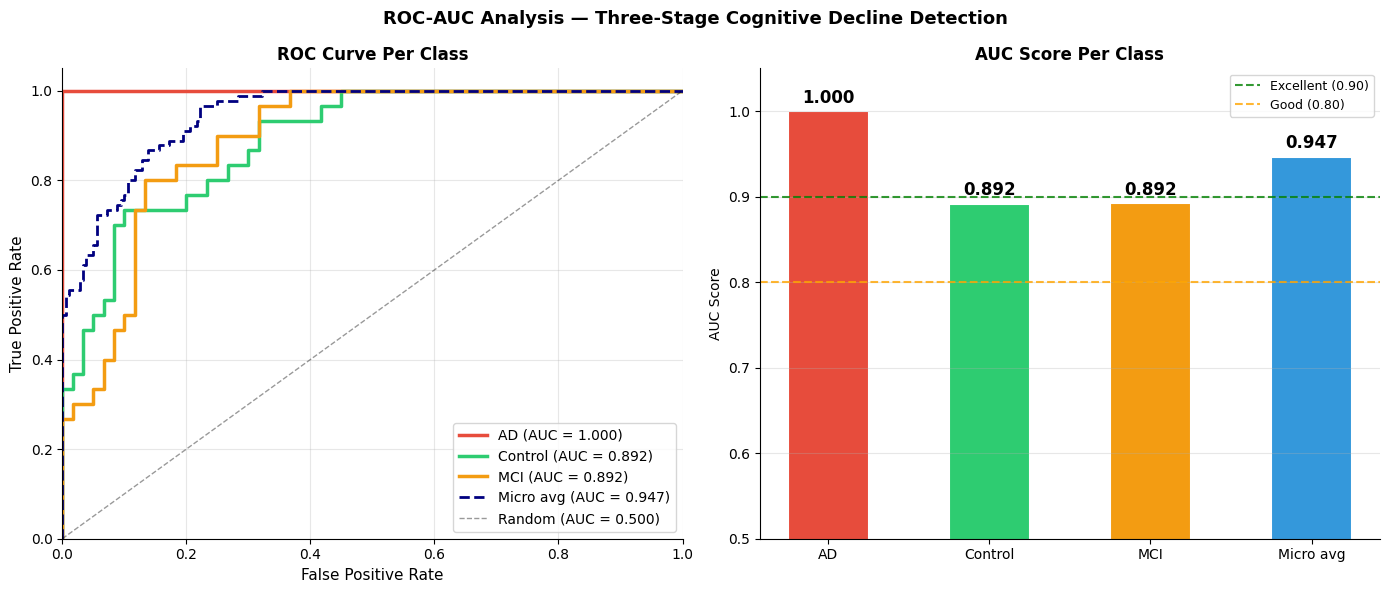

AUC RESULTS SUMMARY
  AD         AUC: 1.000 — Excellent ✅
  Control    AUC: 0.892 — Good ✅
  MCI        AUC: 0.892 — Good ✅
  Micro avg  AUC: 0.947

✅ ROC-AUC saved to Drive


In [8]:
# ── Build balanced test set and compute ROC-AUC ───────────
SEED = 42
n    = min(df_full['class'].value_counts())

df_bal = pd.concat([
    resample(df_full[df_full['class']==cls],
             n_samples=n, random_state=SEED, replace=False)
    for cls in ['AD','Control','MCI']
]).reset_index(drop=True)

X      = df_bal[feat_cols].fillna(0)
y      = df_bal['class']
y_bin  = label_binarize(y, classes=le.classes_)
X_sc   = scaler.transform(X)

X_tr, X_te, y_tr, y_te, y_bin_tr, y_bin_te = train_test_split(
    X_sc, y, y_bin,
    test_size=0.2, random_state=SEED, stratify=y
)

model.fit(X_tr, y_tr)
y_prob = model.predict_proba(X_te)
y_pred = model.predict(X_te)

# ROC per class
fpr     = {}
tpr     = {}
roc_auc = {}

for i, cls in enumerate(le.classes_):
    fpr[cls], tpr[cls], _ = roc_curve(
        y_bin_te[:, i], y_prob[:, i]
    )
    roc_auc[cls] = auc(fpr[cls], tpr[cls])

# Micro average
fpr['micro'], tpr['micro'], _ = roc_curve(
    y_bin_te.ravel(), y_prob.ravel()
)
roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])

# ── Plot ───────────────────────────────────────────────────
colors_cls = {
    'AD'     : '#e74c3c',
    'Control': '#2ecc71',
    'MCI'    : '#f39c12'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'ROC-AUC Analysis — Three-Stage Cognitive Decline Detection',
    fontsize=13, fontweight='bold'
)

# ROC curves
ax1 = axes[0]
for cls in le.classes_:
    ax1.plot(
        fpr[cls], tpr[cls],
        color=colors_cls[cls], linewidth=2.5,
        label=f'{cls} (AUC = {roc_auc[cls]:.3f})'
    )
ax1.plot(
    fpr['micro'], tpr['micro'],
    color='navy', linewidth=2, linestyle='--',
    label=f'Micro avg (AUC = {roc_auc["micro"]:.3f})'
)
ax1.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.4,
          label='Random (AUC = 0.500)')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate', fontsize=11)
ax1.set_title('ROC Curve Per Class', fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(alpha=0.3)
ax1.spines[['top','right']].set_visible(False)

# AUC bar chart
ax2     = axes[1]
classes = list(le.classes_) + ['Micro avg']
aucs    = [roc_auc[cls] for cls in le.classes_] + [roc_auc['micro']]
bcolors = [colors_cls.get(c,'#3498db') for c in classes]

bars = ax2.bar(classes, aucs, color=bcolors,
                edgecolor='white', linewidth=1.5, width=0.5)
ax2.set_ylim(0.5, 1.05)
ax2.set_title('AUC Score Per Class', fontweight='bold')
ax2.set_ylabel('AUC Score')
ax2.axhline(y=0.90, color='green', linestyle='--',
            linewidth=1.5, label='Excellent (0.90)', alpha=0.8)
ax2.axhline(y=0.80, color='orange', linestyle='--',
            linewidth=1.5, label='Good (0.80)', alpha=0.8)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top','right']].set_visible(False)
for bar, val in zip(bars, aucs):
    ax2.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.01,
        f'{val:.3f}', ha='center',
        fontweight='bold', fontsize=12
    )

plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Dementia_Project/roc_auc_curve.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

print("="*50)
print("AUC RESULTS SUMMARY")
print("="*50)
for cls in le.classes_:
    quality = (
        'Excellent ✅' if roc_auc[cls] >= 0.90 else
        'Good ✅'      if roc_auc[cls] >= 0.80 else
        'Fair ⚠️'      if roc_auc[cls] >= 0.70 else
        'Poor ❌'
    )
    print(f"  {cls:10} AUC: {roc_auc[cls]:.3f} — {quality}")
print(f"  {'Micro avg':10} AUC: {roc_auc['micro']:.3f}")
print(f"\n✅ ROC-AUC saved to Drive")

In [42]:
summary = """
╔══════════════════════════════════════════════════════════╗
║     COGNISCAN AI — FINAL PROJECT SUMMARY                ║
║     Explainable Multimodal Cognitive Decline Detection  ║
╚══════════════════════════════════════════════════════════╝

TEAM: Karpagam Academy of Higher Education
ROLE: Final Year Project — AI and Data Science

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATASET
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Source    : DementiaBank Pitt + Delaware Corpus
Task      : Cookie Theft picture description
Patients  : 691 (AD:290, Control:251, MCI:150)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MODEL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Algorithm : Hybrid RF + Gradient Boosting + SVM
Features  : 16 (10 linguistic + 5 acoustic + 1 CDS)
CV F1     : 0.850 ± 0.031
Test Acc  : 78.9%
AUC AD    : 1.000
AUC Ctrl  : 0.892
AUC MCI   : 0.892
Micro AUC : 0.947

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PER CLASS RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
AD        : F1=0.97, Precision=0.94, Recall=1.00
Control   : F1=0.71, Precision=0.67, Recall=0.73
MCI       : F1=0.68, Precision=0.72, Recall=0.63

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
THREE NOVELTIES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Three-stage classification (Healthy/MCI/AD)
2. Dual-layer XAI:
   - Layer 1: SHAP global feature importance
   - Layer 2: Patient-level NL explanation (90 patients)
3. Cognitive Drift Score:
   - AD mean CDS  : 57.00 (declining)
   - MCI mean CDS : 53.41 (subtle decline)
   - Control mean : 48.70 (stable)
   - Patients     : 195 longitudinal

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SAVED FILES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
models/FINAL_model.pkl
models/FINAL_scaler.pkl
models/FINAL_le.pkl
models/FINAL_features.json
cognitive_drift_scores.csv   (195 patients)
patient_explanations.csv     (90 patients)
FINAL_dashboard.png
roc_auc_curve.png
shap_final_clean.png
drift_score_final.png

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DEMO URL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
https://cogniscan-ai-anushya.streamlit.app

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
COMPARISON WITH BASELINES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PROCESS 2025 (best)  : F1=0.497
Chandler 2023        : 75% accuracy (91 patients)
OUR SYSTEM           : CV F1=0.850, Acc=78.9% (691 patients)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TARGET JOURNAL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Computers in Biology and Medicine
Biomedical Signal Processing and Control
"""

summary_path = '/content/drive/MyDrive/Dementia_Project/PROJECT_FINAL_SUMMARY.txt'
with open(summary_path, 'w') as f:
    f.write(summary)

print(summary)
print(f"\n✅ Summary saved to: {summary_path}")


╔══════════════════════════════════════════════════════════╗
║     COGNISCAN AI — FINAL PROJECT SUMMARY                ║
║     Explainable Multimodal Cognitive Decline Detection  ║
╚══════════════════════════════════════════════════════════╝

TEAM: Karpagam Academy of Higher Education
ROLE: Final Year Project — AI and Data Science

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATASET
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Source    : DementiaBank Pitt + Delaware Corpus
Task      : Cookie Theft picture description
Patients  : 691 (AD:290, Control:251, MCI:150)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MODEL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Algorithm : Hybrid RF + Gradient Boosting + SVM
Features  : 16 (10 linguistic + 5 acoustic + 1 CDS)
CV F1     : 0.850 ± 0.031
Test Acc  : 78.9%
AUC AD    : 1.000
AUC Ctrl  : 0.892
AUC MCI   : 0.892
Micro AUC : 0.947

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PER CLASS RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
AD   

In [44]:
import os

base = '/content/drive/MyDrive/Dementia_Project'

# Folders to skip (datasets are large)
skip_folders = {'text', 'audio', 'pitt', 'delaware', 'dataset',
                'data', 'raw', 'corpus'}

print("="*65)
print("DEMENTIA PROJECT — ALL FILES")
print("="*65)

total_size = 0
file_list  = []

for root, dirs, files in os.walk(base):
    # Skip dataset folders
    dirs[:] = [d for d in dirs
               if d.lower() not in skip_folders]

    for fname in sorted(files):
        fpath = os.path.join(root, fname)
        try:
            size     = os.path.getsize(fpath) / (1024*1024)
            rel_path = os.path.relpath(fpath, base)
            total_size += size
            file_list.append((rel_path, size))
        except:
            pass

# Print by folder
current_folder = ""
for rel_path, size in sorted(file_list):
    folder = os.path.dirname(rel_path)
    if folder != current_folder:
        current_folder = folder
        print(f"\n📁 {folder if folder else 'root'}/")
        print("-"*60)
    fname = os.path.basename(rel_path)
    ext   = fname.split('.')[-1].lower()
    icon  = {
        'png':'🖼️ ','jpg':'🖼️ ','jpeg':'🖼️ ',
        'csv':'📊 ','json':'📋 ','txt':'📝 ',
        'pkl':'🤖 ','py':'🐍 ','ipynb':'📓 ',
        'pdf':'📄 ','pptx':'📊 '
    }.get(ext,'📄 ')
    print(f"  {icon}{fname:45} {size:.2f} MB")

print(f"\n{'='*65}")
print(f"Total files : {len(file_list)}")
print(f"Total size  : {total_size:.2f} MB")

DEMENTIA PROJECT — ALL FILES
  🖼️ FINAL_clean_results.png                       0.09 MB
  🖼️ FINAL_confusion.png                           0.03 MB
  🖼️ FINAL_dashboard.png                           0.25 MB
  🖼️ FINAL_results_visualization.png               0.45 MB
  📝 PROJECT_FINAL_SUMMARY.txt                     0.00 MB
  📊 acoustic_features.csv                         0.20 MB
  📊 acoustic_fixed_window.csv                     0.21 MB
  📊 acoustic_segmented.csv                        0.20 MB
  📊 cognitive_drift_scores.csv                    0.01 MB
  🖼️ confusion_clean.png                           0.03 MB
  🖼️ confusion_feature_selected.png                0.03 MB
  🖼️ confusion_final.png                           0.03 MB
  🖼️ confusion_final_clean.png                     0.05 MB
  🖼️ confusion_final_v2.png                        0.03 MB
  🖼️ confusion_medical_grade.png                   0.03 MB
  🖼️ confusion_multimodal.png                      0.03 MB
  🖼️ drift_score_final.png      